# Longitudinal Fitness Analytics
### Melody Sanchez 🎵🥀

The goal of this notebook is to document the acquisition, integration, cleaning, validation, and analysis of longitudinal fitness and body-composition data collected from multiple personal health platforms ranging from 2019 to 2026. My project combines activity data, health metrics, and body measurements to investigate how long-term behaviors relate to changes in body composition.

What inspired me to develop this project was my frustration with the lack of visible changes in my body composition. 
>Rather than relying on memory or emotion, I decided to let the data answer the question.

I began by establishing two observations:
1. I decided to take up weightlifting and joined a gym on March 17, 2022.
2. Although I trained consistently, there were periods where I became comfortable with my routine and gradually reduced the effort I was putting into my workouts.

These observations led to the following research questions.

---

## Research Questions

- Which training behaviors exhibit the strongest statistical relationship with changes in body weight and waist circumference?

- Can consumer health data from multiple platforms be integrated into a reproducible analytical dataset suitable for longitudinal analysis?

- Which activity, recovery, and physiological variables provide the strongest predictive signals for body-composition outcomes?

- How does limited overlap between predictor and outcome data affect statistical modeling performance?

- Can an end-to-end workflow be developed to acquire, clean, validate, engineer, and analyze longitudinal fitness data for future predictive modeling?

---

## Data Sources

**Garmin activity data** — workout duration, heart rate, cadence, distance,
steps, and body battery metrics exported from Garmin Connect (2023–2026).

**Body measurements** — collected using a Bluetooth-enabled tape measure with
automatic recording via the companion app. This method was adopted after
discovering that manually reading and recording values introduced unnecessary
transcription error.

---

## Outcome Variables

Waist · Abdomen · Hip · Chest · Waist-to-Hip Ratio · Weight (if available)

---

## Current Limitations

- Calorie intake data is unavailable for the study period and is excluded from analysis.
- Body-fat percentage measurements are limited and may contain measurement error.
- Because nutrition data is absent, this study cannot establish causation
  and should be treated as exploratory.


### Goal – Acquire Garmin Activity Data
My initial assumption was that [Garmin's - built-in reporting tool](https://connect.garmin.com/app/report) would provide the detailed workout metrics needed for this project. 

Instead, the export was 💩. 
It contained only three columns. 

Considering that the Garmin watch records heart rate, cadence, steps, Body Battery, training load, and many other metrics, this export was far too limited for the planned analysis.

My next idea was to use Selenium to scrape the visible workout tables directly. That attempt also failed.

## Apparently Garmin is a little hater against automation....
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSvNlMP44EAVTvx47Bu9GkHWP0sBChWzMAOQC-YxkT9VGr4L7uJS4Jo6AtsMl0xNUFtB-KbfldC5rgb23nDpiDTLEhP5Zq47db8rCC3SsDBqQ&s=10" height = 300 width = 250>
<br>


As it turns out, [Garmin's - built-in reporting tool](https://connect.garmin.com/app/report) wasn't what I expected. 🚮 The export looked promising but only returned monthly aggregate counts. After a concerning amount of doomscrolling through Garmin Connect, I realized Garmin Activities contained the actual workout-level observations I needed.

[Garmin Activities](https://connect.garmin.com/app/activities) - The Garmin Activities page, exposed workout-level observations, making it possible to retrieve the data needed for the analysis.

<img src = "https://i.pinimg.com/736x/1d/f7/0e/1df70ee39087418c733d357613efb495.jpg" height = 600 width = 400>

## How I process cleaning data °‧ 𓆝 𓆟 𓆞 ·｡ 
I think of data like I'm Alice, falling down the rabbit hole. I don't know what I am going to encounter. Therefor I should arm myself with sound logic and investigate because I want to make the right moves ♟ . A value that looks suspicious may be completely valid, while a value that appears normal may be a recording error. 

<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR0Y8b1t9jUiNqyxoL7XI_vidx7R3w7InsnmA&s" height = 600 width = 400>


Therefore, to avoid riddles, I rely on investigation rather than assumptions.

The goal of cleaning is not to remove unusual values.

The goal is to identify observations that are inconsistent with reality while preserving legitimate observations, even when they are rare.


<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTtIC_0rXpyM_FCUuJQAZq5fca7VOc9SHGX_w&s" height = 300 width = 200>



In [6]:
import pandas as pd
import re

def load_data(csv_path="../data/raw/fitnessData.csv"):
    return pd.read_csv(csv_path)
df = load_data()
print("Hey, the data loaded. Lets look at it!")

Hey, the data loaded. Lets look at it!


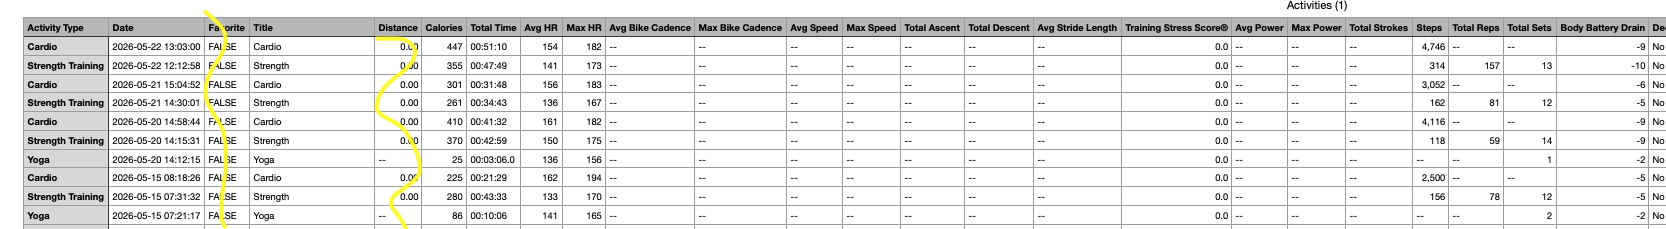

## First Look at the Garmin Export.

In [7]:
print("\nList of all column names in my Garmin data - fitnessData.csv is:")
print("--"*55)
print(df.columns.tolist(),"\n")
print("shape[R,C]")
print(df.shape,"\n\n")
print("head - top3")
df.head(3)


List of all column names in my Garmin data - fitnessData.csv is:
--------------------------------------------------------------------------------------------------------------
['Activity Type', 'Date', 'Favorite', 'Title', 'Distance', 'Calories', 'Total Time', 'Avg HR', 'Max HR', 'Avg Bike Cadence', 'Max Bike Cadence', 'Avg Speed', 'Max Speed', 'Total Ascent', 'Total Descent', 'Avg Stride Length', 'Training Stress Score®', 'Avg Power', 'Max Power', 'Total Strokes', 'Steps', 'Total Reps', 'Total Sets', 'Body Battery Drain', 'Decompression', 'Best Lap Time', 'Number of Laps', 'Avg Resp', 'Min Resp', 'Max Resp', 'Stress Change', 'Stress Start', 'Stress End', 'Avg Stress', 'Max Stress', 'Moving Time', 'Elapsed Time', 'Min Elevation', 'Max Elevation'] 

shape[R,C]
(914, 39) 


head - top3


,Activity Type,Date,Favorite,Title,Distance,Calories,Total Time,Avg HR,Max HR,Avg Bike Cadence,...,Max Resp,Stress Change,Stress Start,Stress End,Avg Stress,Max Stress,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Cardio,2026-06-24 22:33:15,False,Cardio,0.00,168,00:22:31,133,158,--,...,--,--,--,--,--,--,00:00:00,00:22:31,--,--
1,Strength Training,2026-06-24 22:08:33,False,Strength,0.00,128,00:22:17,120,152,--,...,--,--,--,--,--,--,00:07:07.9,00:22:17,--,--
2,Yoga,2026-06-24 22:04:07,False,Yoga,--,24,00:04:14.0,118,131,--,...,16,7,92,99,98,99,00:04:14.0,00:04:14.0,--,--


In [10]:

#_____________removing the obvious garbage 
print("####"*25)
print("# From visual inspection, I am removing the obvious garbage ")
print("####"*25)


drop_cols = [
    "Favorite",
    "Training Stress Score®",
    "Avg Power",
    "Max Power",
    "Total Strokes",
    "Decompression",
    "Number of Laps",
    'Avg Resp', 
    'Min Resp', 
    'Max Resp', 
    "Avg Bike Cadence",
    "Max Bike Cadence",
    'Stress Change', 
    'Stress Start', 
    'Stress End', 
    'Avg Stress', 
    'Max Stress', 
    'Moving Time', 
    'Elapsed Time', 
    'Min Elevation', 
    'Max Elevation' 
    ]

df_clean = df.drop(
    columns=drop_cols,
    errors="ignore"
)

print(" garbage removed, good job")



####################################################################################################
# From visual inspection, I am removing the obvious garbage 
####################################################################################################
 garbage removed, good job


# Inspecting Data Quality Issues

Before performing any analysis, I inspected the Garmin activity dataset for potential data-quality issues and standardized the exported data into a consistent analytical format.

Garmin exports several fields using representations that are not immediately suitable for analysis. Missing values are stored using placeholders such as `"--"` rather than standard missing values (`NaN`), and some variables use inconsistent formatting. For example, **Body Battery Drain** values are exported with leading apostrophes (for example, `'-7`), preventing them from being interpreted as numeric values without preprocessing.

In addition to datatype inconsistencies, the export contains several variables that are either unrelated to the objectives of this project or contain insufficient information for meaningful analysis. These columns were removed before further processing.

Examples include:

- Favorite
- Training Stress Score®
- Respiration metrics
- Cycling-specific power metrics
- Miscellaneous Garmin summary fields

Rather than modifying the original dataset directly, the preprocessing workflow was divided into two distinct stages.

```text
Raw Garmin Export
        │
        ▼
       df
        │
        ▼
    df_clean
```

`df_clean` serves as the project's cleaned, auditable dataset. During this stage the data are standardized, converted to appropriate data types, and inspected feature-by-feature for potential quality issues. Garmin-specific formatting inconsistencies are corrected, variables are converted into their appropriate numeric, datetime, and timedelta representations, and descriptive statistics are generated to identify suspicious observations.

This inspection process combines several complementary approaches:

- Descriptive profiling of every feature.
- Grouped summary statistics by activity type.
- Missing-value assessment.
- Interquartile range (IQR) analysis for applicable variables.
- Manual review of candidate observations before introducing any cleaning rule.

Importantly, no observations are removed for modeling purposes during this stage. The objective is to understand the dataset before making any decisions that could influence downstream analysis.

After the exploratory inspection is complete, a second dataframe is created.

```text
df_clean
    │
    ▼
df_model
```

`df_model` is reserved exclusively for modeling-specific quality filters. Candidate observations are first identified through descriptive profiling, IQR analysis where appropriate, missing-value assessment, and manual inspection. Only observations determined to represent incomplete recordings, accidental activity starts, mislabeled activities, or other unsuitable inputs for statistical modeling are removed from this dataframe.

Examples of modeling-specific decisions include:

- Removing accidental movement recordings with very short running or walking distances.
- Removing incomplete Strength Training workouts lasting less than 10 minutes.
- Applying manually validated activity corrections when Garmin incorrectly classified an activity (for example, cooldown cardio sessions recorded as Yoga).

Maintaining both datasets preserves reproducibility while allowing the analytical dataset to evolve independently from the cleaned archival dataset. As additional modeling decisions are validated, new filters can be applied to `df_model` without altering the underlying cleaned dataset (`df_clean`).

In [30]:

df_clean = df_clean.replace("--", pd.NA)

At this point I also wanted to make sure each column contained the data type it logically represents.

- calories should behave as numbers
- dates should behave as dates
- workout duration should behave as time

>This becomes important later because mathematical operations depend on the correct data types.

    Example:
    "100" + "50" → "10050"     not 150

In [11]:

numeric_cols = [
    "Distance",
    "Calories",
    "Avg HR",
    "Max HR",
    "Avg Speed",
    "Max Speed",
    "Total Ascent",
    "Total Descent",
    "Avg Stride Length",
    "Steps",
    "Total Reps",
    "Total Sets",
    "Body Battery Drain"
]

for col in numeric_cols: 
    
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )
# Converting the DATE  cols to hold the DATE data 
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"]
)

# converting to time 
time_cols = [
    "Total Time",
    "Best Lap Time"
]
for col in time_cols:
    df_clean[col] = pd.to_timedelta(
        df_clean[col],
        errors="coerce"
    )
print("done")


done


# Feature Investigation Framework

After cleaning and standardizing the Garmin export, the next phase focused on evaluating the quality of each feature before using the data for statistical analysis.

Rather than immediately applying mathematical models, every candidate feature was profiled individually to understand its distribution, identify missing values, detect potential outliers, and determine whether any observations represented incomplete recordings or accidental activity starts.

The objective was not simply to remove unusual values, but to understand *why* they appeared before deciding whether they should influence downstream analysis.

### Candidate Features

- <span style="color:pink">Distance</span>
- Steps
- Calories
- Total Time
- Avg HR
- Max HR
- Body Battery Drain
- Strength Training
- Yoga
- Total Ascent
- Total Descent

Each feature followed the same inspection workflow:

1. Generate descriptive summary statistics.
2. Inspect minimum and maximum observations.
3. Evaluate missing-value patterns.
4. Apply interquartile range (IQR) analysis when appropriate.
5. Manually review suspicious observations.
6. Introduce modeling filters only when supported by the evidence.

This feature-by-feature approach reduced the likelihood of introducing arbitrary cleaning rules while documenting the reasoning behind every modeling decision.

Although Garmin records a wide variety of activity metrics, I do not automatically trust the raw activity data. There have been several occasions where I accidentally left an activity recording running after completing a workout.

For example:

```
Gym session ends

     I forget to stop tracking → I drive home → Garmin believes I became an Olympic runner 🏃🏻‍♀️🥇
```

Similarly, Garmin occasionally misclassified activities. During manual inspection, I identified several cooldown cardio sessions that had been recorded as Yoga. These observations were corrected after reviewing the surrounding activities recorded on the same day.

With this in mind, every feature underwent systematic inspection before it was considered suitable for statistical analysis. Observations were never removed solely because they appeared unusual. Instead, descriptive profiling, IQR analysis, missing-value assessment, and manual review were used together to determine whether a value represented legitimate behavior or an artifact of the recording process.

Only after completing this inspection were modeling-specific filters applied to `df_model`, while the cleaned archival dataset (`df_clean`) remained unchanged for reproducibility.

---

## Identifying Distance-Based Activities

One of the first questions I needed to answer was which activity types should logically contain <span style="color:pink">**Distance**</span> measurements.

Fortunately, after integrating my Apple Health history, I had a comprehensive record of movement data spanning several years. This made <span style="color:pink">**Distance**</span> the most direct and interpretable metric for distinguishing movement-based activities.

The underlying assumption was straightforward:

- Activities such as **Running**, **Walking**, and **Street Running** should naturally accumulate meaningful distance.
- Activities such as **Strength Training**, **Yoga**, **Cardio**, and **Meditation** generally should not.

If substantial distance values appeared in activities that do not involve meaningful locomotion, they likely represented recording errors, accidental activity starts, or activities requiring further manual inspection.

To test this assumption, I grouped all observations containing distance measurements by activity type and examined their distributions. This verified which activities naturally belonged in the distance category before feature engineering and statistical modeling began.

This investigation also led to the first modeling decision in the project. After reviewing every movement activity below **0.20 miles** alongside the other activities recorded on the same day, these observations consistently appeared to represent accidental recordings or incomplete workouts rather than meaningful exercise.

As a result, movement activities with a recorded distance below **0.20 miles** were excluded from `df_model` while remaining preserved in `df_clean`.

The next phase focuses on inspecting the data. Before applying mathematical methods, I wanted to identify data-quality issues that could affect the analysis.

List of columns that are most relevant to my math model
* Steps
* Calories
* Total Time
* Avg HR
* Max HR
* Body Battery Drain
* Total Ascent
* Total Descent
* Avg Stride Length
* Distance

I do not trust the raw activity data because there have been several occasions where I accidentally left my Garmin tracking enabled after finishing a workout.

For example:

Gym session ends

     I forget to stop tracking → I drive home → Garmin believes I became an Olympic runner 🏃🏻‍♀️🥇

With this in mind, before I apply a mathematical application to the CSV file, it needs to under go an inspection to identify *suspicious values*, values, evaluate missingness, inspect feature distributions, and determine whether any observations required modeling-specific filtering."

To do this, I needed to methodically identify activities that should logically be categorized as having <span style="color:pink">"**distance**"</span> measurements.



My options where the following:
 -  <span style="color:green">"Distance",</span>
-    "Calories",
  -  "Avg HR",
   - "Max HR",
   - "Avg Bike Cadence",
- "Max Bike Cadence",
-    "Avg Speed",
 -   "Max Speed",
 -   "Total Ascent",
 -   "Total Descent",
 -   <span style="color:pink">"Avg Stride Length",</span>
 -   "Steps",
 -   "Total Reps",
 -   "Total Sets",
 -   "Body Battery Drain"

From these options I narrowed them to the following:
 -  <span style="color:pink">"Distance",</span>
 -   "Avg Speed",
 -   "Max Speed",
 -  <span style="color:pink">"Avg Stride Length",</span>
 -   "Steps",


I decided to choose <span style="color:pink">"Avg Stride Length",</span> because it seemed to correlate most directly with movement, since both Running and Walking naturally contain stride measurements.
- The underlying logic was that "yoga" or "strength training" should not be grouped with the <span style="color:pink">"**distance**"</span> group.

Additionally, unrealistic <span style="color:pink">"Avg Stride Length",</span> values would be easier to identify visually.

For example: 
a recorded stride length of: 12   would immediately appear suspicious.

My assumption: Stride length should primarily exist in movement-based activities.

To test this I filtered for rows containing stride measurements and grouped the observations by activity type.

To start I'd like to get the proper names of all possible activities.

After inspecting the activity distributions, I concluded that the issue was not the numeric value itself, but whether **Distance** was a meaningful measurement for the recorded activity.

Activities such as **Running**, **Walking**, and **Street Running** naturally accumulate distance, whereas activities such as **Strength Training**, **Yoga**, **Cardio**, and **Meditation** do not.

Rather than treating every `0.00` value as missing, I explicitly identified the activity types where distance represents meaningful locomotion. Distance values were retained for those activities and set to `NaN` everywhere else.

This approach is preferable because it uses domain knowledge rather than an arbitrary numerical rule. It preserves legitimate movement data while preventing non-applicable distance values from influencing downstream analysis.

```python
df_clean.loc[
    ~df_clean["Activity Type"].isin(distance_activities),
    "Distance"
] = pd.NA
```

This transformation does not imply that these activities covered zero distance. Instead, it indicates that **Distance is not an applicable feature for those activity types**, allowing missing values to accurately represent "not measured" rather than "zero movement."

In [34]:
print(
    df_clean[
        ["Activity Type","Title","Distance"]
    ]
    .head(30)
)

        Activity Type                      Title  Distance
0              Cardio                     Cardio      0.00
1   Strength Training                   Strength      0.00
2                Yoga                       Yoga       NaN
3              Cardio                     Cardio      0.00
4   Strength Training                   Strength      0.00
5                Yoga                       Yoga       NaN
6                Yoga                       Yoga       NaN
7             Running  Santa Cruz County Running      4.57
8                Yoga                       Yoga       NaN
9              Cardio                     Cardio      0.00
10  Strength Training                   Strength      0.00
11               Yoga                       Yoga       NaN
12             Cardio                     Cardio      0.00
13  Strength Training                   Strength      0.00
14               Yoga                       Yoga       NaN
15             Cardio                     Cardio      0.

With this inspection, the direction of the cleaning pipeline changed after visually examining the **Distance** feature. Rather than assuming every missing value was represented by `"--"`, I first investigated which activity types were expected to contain meaningful distance measurements.

This inspection revealed that Garmin represents "missing" distance in multiple ways depending on the activity:

- `"--"`
- `NaN`
- `0.00`

The `0.00` values required additional investigation because they are numerically valid while still representing missing or meaningless information for many activity types. For example, **Strength Training**, **Yoga**, and **Cardio** frequently recorded a distance of `0.00` even though distance is not a meaningful measurement for those activities.

Prior to this investigation, the cleaning script only standardized Garmin's `"--"` placeholders.

```python
df_clean = df_clean.replace("--", pd.NA)
```

After reviewing the activity distributions, the cleaning strategy was expanded. Distance values are now retained only for activity types where distance represents meaningful locomotion (`Running`, `Walking`, and `Street Running`). For all other activity types, the **Distance** column is explicitly set to `NaN`.

This approach distinguishes between a true zero-distance movement activity and a feature that is simply not applicable to the recorded activity, producing a dataset that more accurately reflects the semantics of the Garmin export.

In [15]:
df_clean.loc[
    ~df_clean["Activity Type"].isin(
        distance_activities
    ),
    "Distance"
] = pd.NA

In [16]:
print(
    df_clean[
        ["Activity Type","Title","Distance"]
    ]
    .head(30)
)

        Activity Type                      Title  Distance
0              Cardio                     Cardio       NaN
1   Strength Training                   Strength       NaN
2                Yoga                       Yoga       NaN
3              Cardio                     Cardio       NaN
4   Strength Training                   Strength       NaN
5                Yoga                       Yoga       NaN
6                Yoga                       Yoga       NaN
7             Running  Santa Cruz County Running      4.57
8                Yoga                       Yoga       NaN
9              Cardio                     Cardio       NaN
10  Strength Training                   Strength       NaN
11               Yoga                       Yoga       NaN
12             Cardio                     Cardio       NaN
13  Strength Training                   Strength       NaN
14               Yoga                       Yoga       NaN
15             Cardio                     Cardio       N

## Result

At this point, I had enough information to make my first real cleaning decision.

Originally, I assumed Garmin represented missing distance values using `"--"`, but after inspecting the activity distributions I realized that wasn't the whole story. Activities that were never expected to accumulate meaningful distance, such as **Strength Training**, **Yoga**, and **Cardio**, often contained `0.00` instead.

The problem wasn't that `0.00` was an invalid number—it was that **Distance wasn't a meaningful feature for those activities in the first place**.

This completely changed the direction of my cleaning function.

Instead of trying to identify every possible representation of a missing value, I shifted the focus toward identifying **which activities should logically contain Distance measurements**. Once that question was answered, the cleaning became much simpler. Distance was preserved for movement-based activities and marked as missing everywhere else.

This investigation also established the approach used throughout the rest of the project.

Rather than introducing arbitrary cleaning rules, every feature follows the same process:

- Inspect the data.
- Understand how Garmin recorded the feature.
- Investigate suspicious observations.
- Make a decision only after manual review.

The result is two separate datasets with different purposes.

- **`df_clean`** contains the cleaned and standardized Garmin export. This dataset preserves every observation after formatting corrections and datatype conversion, making it suitable for auditing and reproducibility.
- **`df_model`** is created from `df_clean` and is refined only after inspection demonstrates that a modeling-specific cleaning rule is justified.

### Next Step

With the Distance feature standardized, I can begin working through the remaining candidate features one at a time. Some features will require additional modeling rules, while others may simply confirm that Garmin recorded the data correctly. Either outcome is useful because the objective is to understand the data before changing it.

# Utility Functions ⚙️

As I continued inspecting different features, I noticed I was repeating the same investigation over and over again.

For every column I found myself asking the same questions.

- What does the distribution look like?
- What are the smallest and largest values?
- Are there obvious outliers?
- Do the values make sense for each activity type?
- Is this actually bad data, or just an unusual workout?

After writing the same blocks of code several times, I decided to turn the investigation into a small collection of reusable utility functions.

One design decision I made early was separating **inspection** from **cleaning**. I wanted to understand *why* a value looked suspicious before writing code that modified it. Because of that, most of these functions never change the dataset—they simply help me investigate it.

---

### `profile_col(df, col)`

This is usually the first function I call for a new feature.

It prints the lowest observations, highest observations, and grouped descriptive statistics for each activity type. The goal isn't to identify bad data immediately—it is to understand how Garmin recorded the feature and to get a feel for the distribution before making any decisions.

More than once, this function completely changed the direction of my cleaning pipeline simply because it exposed something I wasn't expecting.

---
### `suggest_iqr_thresholds(df, col, multiplier=2.5)`
After understanding the overall distribution, I use the <span style="color:red">Interquartile Range (IQR)</span> method to identify observations that deserve a closer look.

The IQR measures the spread of the middle 50% of the data and is calculated as:

- **Q1** — 25th percentile
- **Q3** — 75th percentile
- **IQR = Q3 − Q1**

Candidate outlier thresholds are then computed as:

- **Lower Bound = Q1 − (multiplier × IQR)**
- **Upper Bound = Q3 + (multiplier × IQR)**

These calculations are performed separately for each activity type because Running, Walking, Cardio, and Strength Training naturally have very different distributions. Using a single threshold across every activity would produce many misleading results.

I intentionally chose a **2.5× IQR** multiplier instead of the traditional **1.5×** rule. Workout data naturally contains much more variation than many business datasets, so I wanted the thresholds to be less aggressive and reduce the number of legitimate workouts being flagged for review.

One thing I learned while building this project is that an IQR outlier is **not** necessarily bad data. In several cases, the largest observations represented legitimate workouts rather than recording errors.

Because of that, these thresholds are used only to guide the investigation. They identify observations that deserve a closer look, but they never become cleaning rules on their own.

---

### `review_col(df, col, low_threshold=None, high_threshold=None)`

This function displays observations that fall outside thresholds I specify.

Instead of immediately deleting or replacing values, I can review the surrounding context, including:

- Date
- Activity Type
- Title
- Distance
- Total Time
- Heart Rate
- Steps

Many observations that initially looked suspicious turned out to be completely legitimate workouts. This function helped reinforce that unusual data and bad data are not always the same thing.

---

### `review_iqr_outliers(df, col, thresholds)`

Once IQR thresholds are calculated, this function automatically reviews every activity group without requiring me to manually specify threshold values for each one.

This became one of the most useful parts of the investigation because it quickly highlighted observations worth reviewing while still leaving the final decision up to me.

---

### What I Learned

One thing became clear as I worked through the features.

A statistical outlier is **not** automatically a recording error.

Some of the largest values in the dataset represented legitimate workouts, while some values that looked perfectly normal turned out to be accidental recordings after reviewing the surrounding activities.

That changed how I approached the rest of the project.

Instead of letting statistical methods decide what should be cleaned, I use them to decide **what deserves a closer look**. Every modeling rule in `df_model` exists because I manually investigated the feature first, not because an algorithm labeled a value as unusual.

### Cleaning Decision 

The review identified six observations for investigation.

After manual review:

• Two walking stride-length observations (6.10 and 7.83) were identified as physically unrealistic and were replaced with missing values (NA).<br>
• Short running activities were retained because they may represent legitimate, though brief, recordings.<br>
• High running stride-length observations (1.20 and 1.23) were reviewed and retained because they were associated with plausible running activities.

Final sample sizes:

• Running: 78 → 78<br>
• Walking: 54 → 52 non-missing Avg Stride Length values

## Applying the Investigation Framework

At this point I had everything I needed to start making actual cleaning decisions. So rather than jumping straight into modifying the dataset, I worked through each feature individually, asked the same questions each time, and only introduced a cleaning rule when the evidence supported it.

The following sections document each investigation and the reasoning behind every decision.

## Strength Training

### Investigation

After inspecting the distribution of workout durations, several Strength Training activities immediately stood out. A small number of sessions lasted only a few seconds or a few minutes.

Unlike many of the other features in this project, I had outside knowledge that could help evaluate these observations.

I know how I train.

A typical lifting session involves multiple exercises, several working sets, and rest periods between sets. Even an abbreviated workout rarely lasts less than ten minutes. Because of that, these extremely short recordings immediately appeared suspicious.

To verify this assumption, I reviewed each flagged workout individually.

### Findings

The shortest activities consisted of recordings lasting only a few seconds or minutes while burning very few calories and containing little additional activity information.

These observations were consistent with accidental activity starts or recordings that were stopped shortly after beginning rather than genuine workouts.

### Decision

Strength Training activities shorter than **10 minutes** were removed from `df_model`.

The original observations remain preserved in `df_clean`, allowing the cleaning decision to remain fully reproducible while preventing incomplete workouts from influencing downstream analysis.

## Total Ascent

### Investigation

The Total Ascent feature was profiled using descriptive statistics followed by activity-specific IQR analysis.

Several observations exceeded the suggested upper thresholds, but rather than assuming they represented bad data, I investigated each workout individually.

The largest ascent value corresponded to an 8.67-mile outdoor walk with 994 feet of elevation gain. After estimating the average grade, the result appeared physically reasonable for a hilly route.

### Decision

Although several observations were identified as statistical outliers, none appeared to represent recording errors.

No cleaning rule was introduced for this feature, and both `df_clean` and `df_model` remain unchanged.

## Steps

### Investigation

The Steps feature was reviewed primarily to identify unusually small step counts that might indicate incomplete activity recordings.

Many of the smallest values occurred during very short Strength Training sessions that had already been identified during the previous investigation.

### Decision

Because these observations were already removed through the Strength Training duration filter, no additional Steps-specific cleaning rule was necessary.

This feature demonstrates an important property of the modeling pipeline: a single modeling rule can improve multiple variables simultaneously.

## Calories

### Investigation

Calories were profiled to identify both unusually small and unusually large energy expenditures.

Candidate observations outside the expected range were manually reviewed rather than removed automatically.

### Findings

Only a small number of observations fell outside the selected review thresholds.

After inspection, these records corresponded to incomplete activities rather than unrealistic calorie estimates.

### Decision

Activities recording fewer than **8 calories** or more than **770 calories** were removed from `df_model`.

The original observations remain preserved in `df_clean`.

## Average Heart Rate

### Investigation

Average Heart Rate was profiled using descriptive statistics and manual review.

Although the feature contained observations spanning a wide range of workout intensities, every reviewed activity appeared physiologically reasonable.

### Decision

No cleaning rule was introduced.

The Average Heart Rate feature remained unchanged in both `df_clean` and `df_model`.

## Maximum Heart Rate

### Investigation

Maximum Heart Rate was inspected using descriptive statistics to identify potentially unrealistic peak heart-rate measurements.

The observed values were consistent with the corresponding workout intensities and activity types.

### Decision

No evidence of recording errors was found.

No cleaning rule was introduced for this feature.

## Body Battery Drain

### Investigation

Unlike the previous features, the initial inspection suggested that Body Battery Drain contained no usable information. Every value appeared to be missing.

Rather than removing the feature immediately, I inspected the raw Garmin export and discovered that the problem was not missing data but inconsistent formatting.

Garmin exports Body Battery Drain values with a leading apostrophe (for example, `'-7`), preventing Pandas from recognizing the column as numeric.

### Findings

After removing the leading apostrophe and converting the values to numeric format, valid Body Battery Drain measurements became available throughout the dataset.

A completeness assessment showed that the feature still contained substantial missing data, but enough observations remained to justify retaining it for future analysis.

### Decision

No modeling filter was introduced.

Instead, the cleaning process was updated to standardize Garmin's export format before datatype conversion.

## Total Descent

### Investigation

Total Descent was profiled using descriptive statistics to identify potentially unrealistic elevation losses.

The observed distribution closely mirrored the behavior of Total Ascent and no immediately suspicious observations were identified.

### Decision

No modeling rule was introduced.

The feature remains unchanged in both datasets.

## Yoga

### Investigation

The longest Yoga sessions immediately appeared unusual.

Rather than assuming these represented exceptionally long stretching sessions, I reviewed every activity that occurred on those dates.

This investigation revealed that several cooldown cardio sessions had been accidentally recorded as Yoga because the activity type was never changed on my Garmin watch after completing the workout.

### Findings

Three activities were confirmed to be incorrectly labeled.

Rather than deleting these observations, I manually corrected their activity type from **Yoga** to **Cardio** in both `df_clean` and `df_model`.

### Decision

No Yoga activities were removed from the dataset.

Instead, the activity labels were corrected to accurately reflect the workouts that had actually been performed.

# Cleaning Complete

At this point the Garmin activity dataset has completed the cleaning and inspection pipeline.

Rather than producing a single "clean" dataset, the workflow intentionally ends with two separate datasets that serve different purposes.

- **`df_clean`** preserves the cleaned Garmin export after formatting corrections, datatype conversion, and feature standardization. No observations are removed simply because they appear unusual, making this dataset suitable for auditing and reproducibility.

- **`df_model`** is derived from `df_clean` and incorporates only those modeling-specific filters that were supported by descriptive profiling and manual investigation. These observations were removed because there was sufficient evidence to conclude that they represented incomplete recordings, accidental activity starts, or activities unsuitable for statistical analysis.

This phase reinforced the guiding principle established throughout the project: statistical methods identify observations for review, but manual investigation determines whether a cleaning rule is justified.

Several observations initially identified by the IQR analysis turned out to be completely legitimate workouts, while other issues—such as incorrectly labeled Yoga activities and Garmin's formatting of Body Battery Drain—could only be identified through manual inspection.

This reinforced the philosophy used throughout the project: statistical methods guide the investigation, but they do not make the final cleaning decisions.

The resulting datasets now provide a reliable foundation for the next stage of the project, where the cleaned activity records will be integrated with Apple Health body measurements and transformed into analytical features for statistical modeling.

# Phase 2 — Database Construction and Validation

Before integrating the remaining health datasets, I wanted to establish a reproducible database workflow using my manually collected body measurements. Since this dataset is relatively small, it provided a good starting point for developing and validating the ingestion process before working with much larger exports from Apple Health and myNetDiary.

Rather than cleaning the CSV directly, I imported the original `measurements.csv` file into a MySQL database using a dedicated Python loading script. This approach preserved the raw source data while avoiding import issues encountered with the MySQL Workbench Import Wizard when sparse numeric columns contained missing values.

The Python loader was responsible only for importing the raw data into MySQL while preserving missing observations as SQL `NULL` values. All validation and standardization were then performed inside the database using SQL.

The SQL workflow consisted of:

- Creating the raw `measurements` table.
- Verifying the expected number of records were imported.
- Converting the imported text dates into the SQL `DATE` datatype.
- Checking for duplicate measurement dates.
- Creating a validated `measurements_clean` table ordered chronologically.

At the completion of this phase, the measurement data had been successfully imported into MySQL, validated, standardized, and exported as a cleaned dataset. More importantly, this established a reproducible database ingestion workflow that will be reused throughout the remainder of the project as additional datasets are incorporated into the analytical database.

## Designing the Apple Health Processing Pipeline

After identifying the available <span style="color:lime">HK</span> record types, I performed a keyword-based search to extract candidate datasets related to body composition, physical activity, cardiovascular health, recovery, and energy expenditure. Each selected record type was exported from the Apple Health XML file into its own raw CSV file using a custom Python extraction script.

Before writing any cleaning code, I wanted to understand exactly what Apple Health was giving me. Rather than immediately transforming the data, I opened every extracted dataset and manually inspected the first several rows. My goal was to understand how each metric was recorded before deciding how it should be processed.

This inspection included looking at:

- Column layouts
- Timestamp formats
- Units of measurement
- Record counts
- Sample observations
- Overall dataset structure

Just like the Garmin data, I didn't want to assume that every dataset should be cleaned the same way. Different metrics represent different kinds of measurements, so applying the same processing pipeline to every file would have introduced unnecessary assumptions.

During this review I found that several datasets contributed little to the overall objectives of the project. Some contained only a handful of observations collected across several years, while others represented specialized HealthKit metrics that were unlikely to improve the statistical analysis. These datasets were excluded from the remainder of the project.

The remaining datasets revealed something much more interesting.

Apple Health does not record every metric in the same way.

Some variables, such as **Active Energy Burned**, **Step Count**, and **Distance Walking Running**, represent quantities that accumulate continuously throughout the day. Other variables, including **Heart Rate**, **Respiratory Rate**, and **Heart Rate Variability**, represent physiological measurements collected repeatedly over time. Finally, body-composition variables such as **Body Mass**, **Body Mass Index**, and **Waist Circumference** already exist as individual point measurements.

At first glance they all looked like simple CSV files.

After inspecting the data, it became obvious they represented three fundamentally different types of information.

This completely changed how I approached the cleaning process.

Rather than forcing every dataset through the same workflow, I designed three separate processing pipelines based on how each metric was collected.

```text
                Apple Health Datasets
                         │
         ┌───────────────┼───────────────┐
         ▼               ▼               ▼
 Daily Totals      Daily Averages   Point Measurements
         │               │               │
         ▼               ▼               ▼
      Sum by Day     Mean by Day   Preserve Observation
```

Daily accumulated metrics (such as Active Energy Burned, Apple Exercise Time, Step Count, Flights Climbed, Basal Energy Burned, and Distance Walking Running) were grouped by calendar date and summed to produce one daily observation.

Daily physiological metrics (including Heart Rate, Heart Rate Variability, Respiratory Rate, Walking Heart Rate Average, Walking Speed, and Walking Step Length) were grouped by calendar date and averaged to produce representative daily values.

Body-composition measurements already represented individual observations, so they required only date standardization and column selection without any aggregation.

After processing, every Apple Health dataset shared the same analytical structure:

```text
date
unit
value
```

Although the original HealthKit export contains more than 1.7 million observations spread across many different recording formats, standardizing every dataset into this common representation greatly simplified the remainder of the project. From this point forward, each metric could be treated as a daily time series, making feature engineering and measurement-window construction substantially easier while preserving the underlying information contained in the original export.

# Phase 2.1 - Project Reassessment After Apple Health Integration

While grouping measurements and activities into date windows, I discovered that my Garmin activity history only extended back to `2023-09-13`.

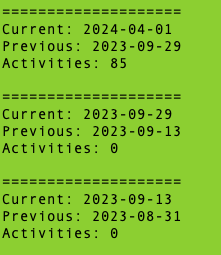

While thinking about the missing history, I suddenly remembered I used to wear an Apple Watch. I was able to export all my historical data. By integrating Apple Health data with my existing Garmin records, the available historical coverage increased from approximately 3 years to more than **7 years**. I obtained a `989 MB` export containing more than `1.7 million` records.

I used the following `grep` commands to perform an audit of the available record types.

```
grep '<Record type="' apple_export.xml | sed -n 's/.*type="\([^"]*\)".*/\1/p' | sort | uniq
```

The exported XML stores health records using Apple's internal <span style="color:lime">HealthKit (HK) </span>  identifiers (for example, `HKQuantityTypeIdentifierHeartRate` and `HKCategoryTypeIdentifierSleepAnalysis`). Since the export contains many metrics that were not relevant to this study, I performed an initial audit to identify the available record types and their frequencies before deciding which datasets to extract.

```
(base) ~/Desktop/finalFiles/data/raw ⋆✦⋆ ☽ Melody ☾ ⋆✦⋆ grep '<Record type="' apple_export.xml \
| sed -n 's/.*type="\([^"]*\)".*/\1/p' \
| awk '
/Sleep|Energy|Exercise|Walking|Body|Flights|Heart|Waist|Count/ {
    count[$0]++
}
END {
    for (k in count)
        printf "%8d %s\n", count[k], k
}' \
| sort -nr

```
OUTPUT

```
  809597 HKQuantityTypeIdentifierActiveEnergyBurned
  428078 HKQuantityTypeIdentifierBasalEnergyBurned
  254629 HKQuantityTypeIdentifierHeartRate
  201822 HKQuantityTypeIdentifierDistanceWalkingRunning
  143639 HKQuantityTypeIdentifierStepCount
   54954 HKQuantityTypeIdentifierAppleExerciseTime
   33894 HKQuantityTypeIdentifierWalkingSpeed
   33893 HKQuantityTypeIdentifierWalkingStepLength
   29273 HKQuantityTypeIdentifierWalkingDoubleSupportPercentage
   13528 HKQuantityTypeIdentifierWalkingAsymmetryPercentage
    8350 HKQuantityTypeIdentifierFlightsClimbed
    5261 HKQuantityTypeIdentifierHeartRateVariabilitySDNN
    5196 HKQuantityTypeIdentifierDietaryEnergyConsumed
    3406 HKCategoryTypeIdentifierSleepAnalysis
    1468 HKQuantityTypeIdentifierRestingHeartRate
    1232 HKQuantityTypeIdentifierWalkingHeartRateAverage
     241 HKQuantityTypeIdentifierAppleWalkingSteadiness
      66 HKQuantityTypeIdentifierBodyMassIndex
      48 HKQuantityTypeIdentifierBodyMass
      25 HKQuantityTypeIdentifierSwimmingStrokeCount
      20 HKQuantityTypeIdentifierWaistCircumference
      14 HKCategoryTypeIdentifierLowHeartRateEvent
      13 HKQuantityTypeIdentifierBodyFatPercentage
       9 HKQuantityTypeIdentifierLeanBodyMass
       1 HKDataTypeSleepDurationGoal
       1 HKCategoryTypeIdentifierSleepChanges
```
Each selected <span style="color:lime">HK</span> record type was extracted into its own CSV file. I then inspected the resulting datasets to verify their structure, record counts, column layout, and overall data quality. This process revealed issues such as non-data header rows, inconsistent date formats, and missing values that required preprocessing before analysis.

The audit revealed a fundamental **imbalance in the available data**. Activity, cardiovascular, and energy metrics were abundant, often containing hundreds of thousands of observations, whereas body-composition measurements consisted of only a few dozen records collected over several years.

As a result, activity data was no longer the primary limitation. Instead, body-composition measurements became the scarcest resource in the dataset, fundamentally changing the focus of the project. This discovery also changed the scope of the project. Rather than focusing exclusively on body weight, both body weight and waist circumference were retained as outcome variables. Evaluating multiple body-composition measurements provided an opportunity to investigate whether different health behaviors exhibited stronger associations with one outcome than the other while leveraging the same feature-engineering pipeline.



## Obtaining and Processing Datasets

After identifying the available <span style="color:lime">HK</span> record types, I performed a keyword-based search to extract candidate datasets related to body composition, physical activity, cardiovascular health, recovery, and energy expenditure. Each selected record type was exported into its own raw CSV file for inspection.

The extracted datasets were then individually reviewed to evaluate their structure, record counts, and overall usefulness. Several datasets contained only a handful of observations, while others represented highly specialized measurements that provided little value for the project's objectives. Those datasets were excluded from the remainder of the analysis.

Although the raw datasets differed substantially in both structure and sampling frequency, they ultimately served a common role within the analytical pipeline. Each dataset was cleaned, standardized, and transformed into engineered predictor variables summarizing health and activity behavior during the seven days preceding each body-composition measurement. These engineered features formed the inputs for the exploratory analysis and regression models presented in the following phases.

# Phase 2.2 – Cleaning and Standardizing Apple Health Datasets

Once the Apple Health datasets had been extracted, I shifted my attention from the XML export to the individual CSV files. At this point I finally had datasets that I could inspect feature-by-feature.

Just like the Garmin data, I wasn't interested in immediately writing cleaning code. I wanted to understand what each dataset actually represented before deciding how it should be processed.

Rather than assuming every Apple Health dataset followed the same structure, I inspected each one individually. This included reviewing the available columns, timestamp formats, units of measurement, record counts, and several sample observations from every extracted CSV.

This investigation revealed that although the datasets shared a common export format, they represented fundamentally different types of measurements. Some variables accumulated continuously throughout the day, others recorded repeated physiological measurements, and others represented individual body-composition observations.

Before I could standardize these datasets into a common analytical format, they first needed to be cleaned consistently.

To make this process reproducible, I built a reusable cleaning pipeline around a collection of utility functions.

These included:

- `get_file_names()`
- `load_csv()`
- `save_csv()`
- `standardize_date_column()`
- `report_column_types()`
- `report_missing_values()`
- `report_date_range()`
- `count_unique_values()`
- `show_rows()`

Rather than cleaning each dataset manually, the pipeline iterated through every extracted Apple Health CSV and applied the same auditing workflow.

Each dataset underwent the following steps:

1. Load the dataset.
2. Standardize the timestamp columns.
3. Validate column data types.
4. Assess missing values.
5. Verify the available date range.
6. Count unique timestamps.
7. Save a cleaned version of the dataset.

## Results

The result of this phase was a collection of cleaned Apple Health datasets with standardized datetime columns and documented quality characteristics.

More importantly, this phase gave me a much better understanding of how Apple Health records different types of information. That understanding ultimately led to the next stage of the project, where the cleaned datasets were reorganized into three processing pipelines based on how each metric was collected before being transformed into standardized daily datasets suitable for feature engineering.

For body-composition datasets containing multiple observations on the same day, duplicate calendar dates were resolved automatically by retaining the largest recorded value before exporting the standardized daily dataset. This ensured that every processed Apple Health feature contained at most one observation per calendar date prior to SQL integration.

# Phase 2.2.1 – Building a Reusable Apple Health ETL Pipeline

Once the Apple Health datasets had been standardized into daily observations, the next objective was to make them available for downstream SQL analysis.

Rather than importing each CSV manually through MySQL Workbench, I developed a reusable ETL pipeline that automatically populated the project's MySQL database.

The pipeline consists of two components.

The first defines reusable loading utilities responsible for reading CSV files, converting missing values, preparing datatypes, truncating existing tables, bulk inserting records, validating row counts, and previewing imported observations.

The second script automatically discovers every processed Apple Health dataset within the `apple_daily` directory, matches each dataset to its corresponding SQL table, applies the appropriate feature names, and imports every dataset into MySQL without requiring manual intervention.

Designing the loading process in this manner allowed additional Apple Health metrics to be incorporated simply by adding new processed datasets and corresponding SQL tables, making the pipeline substantially more scalable and reproducible than importing each dataset individually.


# Phase 2.3 – Recovering Historical Body Measurements

Although Apple Health substantially expanded the project's historical coverage, it still contained relatively few body-composition measurements.

Fortunately, I had previously tracked my weight and body measurements using myNetDiary. While I no longer actively used the application, archived exports contained several historical observations that were no longer available elsewhere.

Unlike Apple Health, the myNetDiary export stores multiple measurement types within a single dataset. Body weight, waist circumference, chest circumference, hip circumference, thigh circumference, body mass index, daily step counts, and several derived metrics are intermixed rather than organized into separate files.

Before deciding how these data should be incorporated into the project, I first performed an audit of the available measurement types and their frequencies. This allowed me to determine which observations contributed meaningful body-composition information and which could be excluded from the integration process.

Only body-composition measurements and daily step counts were retained. Body mass index and basal metabolic rate were excluded because they are derived quantities rather than directly measured variables, while several other measurement types contained too few observations to contribute meaningfully to the analysis.

The remaining observations were extracted into standardized datasets. Body-composition measurements and daily step counts were separated into independent files, duplicate observations were investigated, date ranges were verified, and the resulting datasets were prepared for downstream processing.

---

# Phase 2.4 – Standardizing myNetDiary Measurements

Although the extracted myNetDiary dataset contained the measurements I wanted to preserve, its structure differed substantially from the manually collected body-measurement dataset.

Rather than storing every body measurement on a single row, myNetDiary records each measurement as an independent observation. For example, body weight, waist circumference, chest circumference, and hip circumference collected on the same day each occupy separate rows.

This structure is well suited for data entry but makes comparisons across multiple data sources unnecessarily difficult.

To simplify downstream integration, I reshaped the extracted measurements from a long format into a wide format. Each measurement date now occupies a single row while each body measurement is stored in its own dedicated column. The resulting dataset closely mirrors the structure of my manually collected body-measurement table, allowing both datasets to be compared using the same schema.

At this stage no measurements were merged together. The objective was simply to standardize the structure of the historical records before integrating them with the remaining body-composition datasets.

---
# Phase 2.5 – Integrating Body-Composition Data Sources

At this point I had recovered body-composition measurements from multiple independent sources:
- Manually collected tape measurements,
- Apple Health,
- myNetDiary

all of which contained valuable historical observations. The next challenge was no longer cleaning individual datasets, but determining how to combine them into a single longitudinal record without introducing duplicate measurements.

I decided to perform this stage in MySQL because the remaining work centered around:

- comparing dates,
- identifying duplicate observations,
- merging only unique historical measurements across multiple sources.

Originally, I planned to import the raw measurement data directly using the `MySQL Import Wizard`. Unfortunately, the import repeatedly failed because both the manually collected measurements and the reshaped myNetDiary datasets contain sparse numeric columns where certain body measurements were intentionally left blank rather than recorded.

Rather than modifying the original CSV files simply to satisfy the import tool, I preserved each dataset exactly as originally collected and wrote Python loading scripts that imported the data using Pandas. Missing values were converted into SQL `NULL` values before being inserted into MySQL, allowing the original measurement records to remain unchanged.

Once each dataset had been imported successfully, SQL was used to validate and standardize the imported tables before any integration occurred.

Rather than immediately merging every historical observation, I first compared the imported measurement dates against the existing measurement database. Dates appearing in multiple sources were manually reviewed to determine whether they represented duplicate observations or genuinely independent measurements.

Because myNetDiary stores body weight separately from body circumference measurements, only chest, waist, and hip measurements were considered during this integration step. Generic thigh measurements were intentionally excluded because the original application did not distinguish between the left and right thigh, making them incompatible with the project's measurement schema.

Only observations whose dates did not already exist in the validated measurement database were merged into `measurements_clean`. After the merge completed, the integrated table was validated by confirming the expected record count, checking for duplicate measurement dates, and verifying the chronological ordering of the final dataset.

After integrating the recovered myNetDiary measurements, Apple Health waist circumference observations were processed separately using the cleaned daily waist dataset. Duplicate measurement dates were manually reviewed before unique observations were merged into the validated SQL database. Existing waist measurements were updated where matching dates already existed, while newly recovered historical measurement dates were inserted into `measurements_clean`. This ensured that the final body-measurement database contained the most complete longitudinal waist measurement history available without introducing duplicate observations.

At the completion of this phase, the project contained a single validated body-measurement database combining my manually collected measurements, unique historical observations recovered from myNetDiary, and additional waist circumference measurements recovered from Apple Health. Body weight records remain preserved as an independent dataset and are incorporated separately during later stages of the analysis.

# Phase 3 – Apple Health Feature Engineering

The completion of the body-composition integration pipeline produced a validated longitudinal weight timeline that could now serve as the outcome variable for feature engineering. Rather than modeling individual Apple Health observations directly, the next objective was to transform the high-frequency physiological and activity records into predictor variables aligned with each recorded body-weight measurement.

Although Apple Health continuously records physiological and activity metrics, these measurements are collected at irregular intervals throughout the day and are not directly suitable for statistical modeling. Body weight changes gradually over time and is influenced by accumulated behavior rather than isolated observations. Consequently, each predictor variable was engineered to summarize recent physiological behavior immediately preceding every recorded body-weight measurement.

Before feature engineering could begin, the Apple Health datasets were first transformed into validated daily summaries. Rather than repeatedly aggregating hundreds of thousands of raw observations during every analysis, each metric was processed into a daily time series using an aggregation strategy appropriate for the measurement type.

Activity-based metrics were aggregated into daily totals, including:

- Active Energy Burned
- Apple Exercise Time
- Basal Energy Burned
- Distance Walking/Running
- Flights Climbed
- Step Count

Physiological metrics were aggregated into daily averages, including:

- Heart Rate
- Heart Rate Variability (SDNN)
- Respiratory Rate
- Walking Heart Rate Average
- Walking Speed
- Walking Step Length

These processed daily datasets formed the foundation for feature engineering.

Using the validated `weight_aug2026.csv` dataset as the reference timeline, I developed a reusable Python feature engineering pipeline (`build_apple_features.py`) that automatically generated predictor variables for every Apple Health metric. For each recorded body-weight observation, the pipeline searches the corresponding daily metric dataset and extracts observations occurring during the previous seven days.

Each metric is summarized using an aggregation method appropriate for the variable being analyzed. Activity metrics are summarized using cumulative seven-day totals because they represent quantities accumulated over time, whereas physiological metrics are summarized using seven-day averages because their central tendency is more informative than their cumulative sum.

Rather than constructing each predictor independently, the pipeline iterates through every processed Apple Health dataset using a configurable aggregation dictionary. Each metric is processed automatically, allowing additional Apple Health variables to be incorporated into the project without modifying the underlying feature engineering logic. This design substantially reduced duplicate code while making the feature engineering pipeline reproducible and scalable. :contentReference[oaicite:0]{index=0}

The output of this stage consists of one feature dataset for every Apple Health metric. Each dataset contains:

- the body-weight measurement date,
- the recorded body weight,
- the engineered seven-day predictor variable.

Separating the engineered predictors into independent feature tables simplified downstream analysis while providing a modular foundation for constructing the final modeling dataset used throughout the remainder of the project.

# Phase 4 – Apple Health Feature Engineering

After constructing standardized daily Apple Health datasets, the next step was to transform those daily observations into predictor variables aligned with each recorded body-weight measurement.

Although the Apple Health data had already been aggregated to one observation per day, the project still contained far more daily health records than body-weight measurements. Rather than comparing individual daily observations directly against body weight, I summarized recent physiological behavior preceding each measurement.

For every body-weight observation contained within the validated `weight_aug2026.csv` dataset, the feature engineering pipeline searched the previous seven calendar days of every processed Apple Health dataset.

Each measurement window was then summarized according to the type of metric being analyzed.

Activity variables representing accumulated behavior, such as active calories, exercise time, distance, flights climbed, and step count, were summarized using cumulative seven-day totals.

Physiological variables representing continuously changing measurements, such as heart rate, respiratory rate, heart rate variability, walking heart rate, walking speed, and walking step length, were summarized using seven-day averages.

Conceptually, the process can be described as:

```text
Body-Weight Measurement

        │
        ▼

Previous 7 Days

        │
        ▼

Processed Daily Apple Health Dataset

        │
        ▼

Aggregate
(sum or mean)

        │
        ▼

Engineered Feature
```

For example, a body-weight observation recorded on **2026-06-12** uses Apple Health observations collected between **2026-06-06** and **2026-06-12**. Depending on the variable, those observations contribute either a cumulative weekly total or a weekly average.

The feature engineering pipeline was implemented in `build_apple_features.py`, which automatically processes every standardized daily Apple Health dataset and generates an independent engineered feature dataset for each metric.

By the completion of this phase, every body-weight observation was associated with a consistent set of engineered Apple Health predictor variables describing the week immediately preceding the measurement. These feature datasets provide the Apple Health component of the final longitudinal modeling dataset.

# Phase 5 – Garmin Feature Engineering

Following construction of the Garmin daily metrics, the next stage transformed those standardized daily observations into predictor variables aligned with each recorded body-weight measurement.

Using the validated `weight_aug2026.csv` timeline, the feature engineering pipeline searched the previous seven calendar days of every processed Garmin daily dataset. Each seven-day measurement window was summarized into a single engineered feature.

Metrics describing accumulated activity, such as distance traveled, calories burned, workout duration, steps, elevation gain, elevation loss, repetitions, and completed sets, were summarized using cumulative seven-day totals.

Metrics describing physiological intensity or workout performance, including average heart rate, maximum heart rate, average speed, maximum speed, average stride length, and body battery drain, were summarized using seven-day averages.

Conceptually, the process can be represented as:

```text
Body-Weight Measurement

        │
        ▼

Previous 7 Days

        │
        ▼

Processed Garmin Daily Dataset

        │
        ▼

Aggregate
(sum or mean)

        │
        ▼

Engineered Feature
```

For every processed Garmin metric, the pipeline generated an independent feature dataset containing one engineered predictor value for every body-weight observation.

The feature engineering pipeline was implemented in `build_garmin_features.py`, which automatically processes every standardized Garmin daily dataset using the same reusable aggregation functions developed for the Apple Health pipeline.

By completing this stage, both Apple Health and Garmin activity data were represented using a consistent seven-day measurement-window methodology. This produced comparable engineered predictor variables across both data sources and established the foundation for constructing the final longitudinal modeling dataset.

# Phase 6 – Constructing the Master Modeling Dataset

At this stage, engineered predictor variables had been generated independently from both Apple Health and Garmin activity data. Although each feature described the same body-weight timeline, they still existed as separate datasets.

To prepare the data for statistical analysis and predictive modeling, every engineered feature dataset was merged into a single longitudinal modeling table using the body-weight measurement date as the common key.

The pipeline automatically loaded every Apple Health feature dataset together with every Garmin feature dataset before performing a series of left joins on the validated body-weight timeline. This ensured that every recovered body-weight observation remained in the final dataset while preserving missing values for features that were unavailable during earlier periods.

After the merge completed, feature names were standardized to provide consistent naming across both data sources.

During validation, I observed that both Apple Health and Garmin contained seven-day distance features representing nearly identical measurements. Rather than treating them as independent predictors, the pipeline reconciled the overlapping variables by preferentially using Garmin-derived distance measurements whenever they were available while automatically filling earlier historical observations using the Apple Health distance feature. This approach preserved the complete longitudinal distance history without double-counting overlapping observations.

The resulting modeling dataset contains one row for every body-weight observation together with all engineered predictor variables generated throughout the project.

Conceptually, the process can be represented as:

```text
weight_df
    │
    ▼
Merge Apple Features
    │
    ▼
Merge Garmin Features
    │
    ▼
Standardize Names
    │
    ▼
Reconcile Distance
    │
    ▼
weight_master_features.csv
```

This completed dataset serves as the foundation for the remaining stages of the project, including exploratory visualization, correlation analysis, statistical modeling, and predictive analytics.

## Final Modeling Dataset

The completed `weight_master_features.csv` dataset serves as the primary analytical dataset for the remainder of the project.

Each row represents a single body-weight observation, while the remaining columns contain engineered predictor variables summarizing health and activity behavior during the preceding seven-day measurement window.

The completed dataset contains:

- 52 body-weight observations
- 22 engineered predictor variables
- One measurement date column
- Apple Health activity and physiological features
- Garmin activity and workout features

This unified dataset forms the foundation for the exploratory analysis, regression modeling, statistical inference, and predictive analysis presented in the remaining phases of the project.

## Phase 7 – Exploratory Analysis and Predictive Modeling

The completed `weight_master_features.csv` dataset served as the primary modeling dataset for the remainder of the analysis. Each row represents one body-weight observation, while each predictor variable summarizes behavioral or physiological measurements collected during the seven calendar days preceding that body-weight measurement.

This measurement-window approach transformed high-frequency Apple Health and Garmin observations into engineered predictor variables that were directly aligned with the body-weight timeline.

The completed modeling dataset contains:

- 52 body-weight observations
- 22 engineered predictor variables
- Apple Health activity and physiological metrics
- Garmin workout and activity metrics

Because several data sources became available at different points in time, predictor availability varies across features. Consequently, each regression model was fit using all complete observations available for the predictor under investigation rather than restricting every analysis to dates containing complete information for every feature.

The completed dataset first underwent exploratory correlation analysis to quantify the linear relationships between body weight and each engineered predictor. Pearson correlation coefficients were computed for all numerical variables and visualized using the correlation matrix shown in Figure 7.1. The heatmap provided an initial overview of relationships among the engineered features and identified predictors exhibiting the strongest associations with body weight.


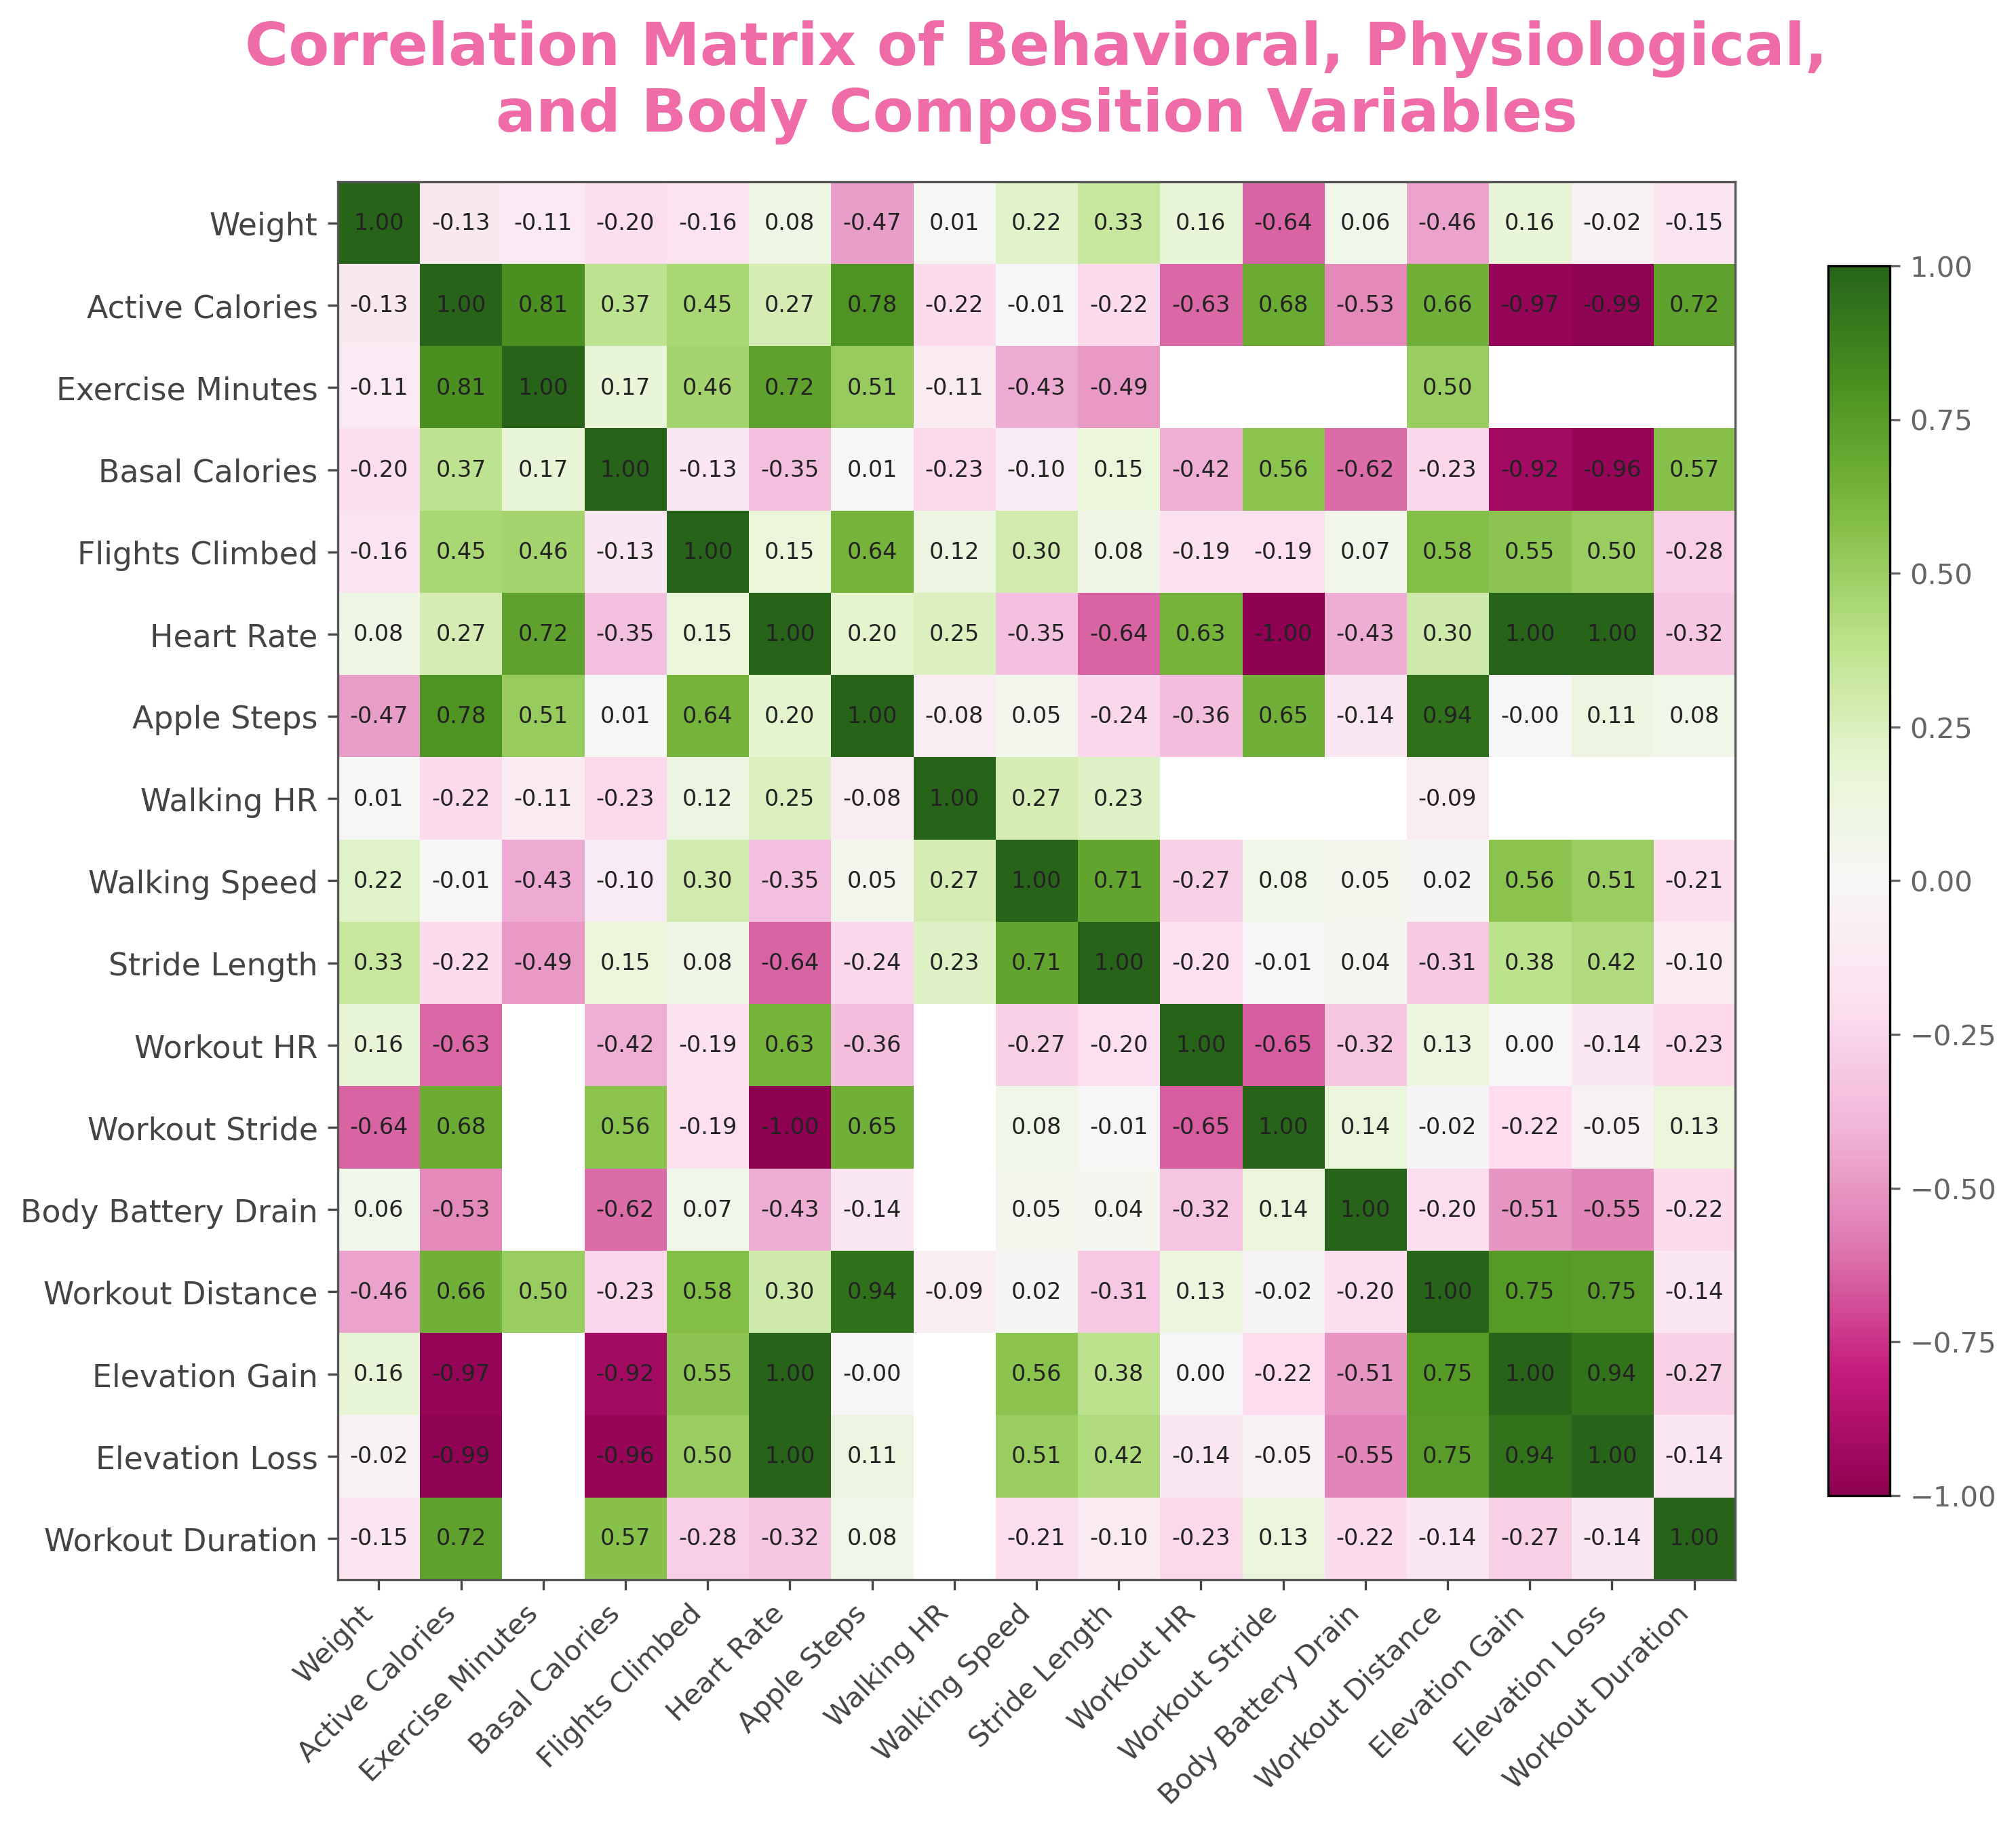
> **Figure 7.1.** Pearson correlation matrix illustrating the pairwise linear relationships among body weight and the engineered behavioral and physiological predictors. Stronger positive correlations are shown in green, stronger negative correlations are shown in magenta, and weaker associations appear near white.


The correlation analysis served as an initial feature-screening step. Predictors demonstrating stronger linear relationships with body weight, while also maintaining sufficient data availability, were selected for simple linear regression analysis. Each predictor was evaluated independently, allowing every model to maximize the number of complete observations available for that feature.

This screening process identified Apple Step Count, Distance, and Walking Step Length as the strongest candidate predictors for subsequent multiple regression analysis. Apple Step Count and Distance exhibited the strongest negative associations with body weight, while Walking Step Length demonstrated a weaker but statistically significant positive association.

## Phase 7.1 Regression Evaluation Metrics

Each simple linear regression model was evaluated using both descriptive and inferential statistics.

The descriptive statistics quantify how well each model fits the observed data, while the inferential statistics assess whether the observed relationship is distinguishable from random variation within the available sample.

The following statistics are reported for every regression model.

| Statistic | Purpose |
|-----------|---------|
| Sample Size (*n*) | Number of observations used to fit the regression model. |
| Pearson Correlation (*r*) | Measures the strength and direction of the linear relationship between the predictor and body weight. |
| Coefficient of Determination (*R²*) | Proportion of the variability in body weight explained by the predictor. |
| Mean Absolute Error (MAE) | Average absolute prediction error measured in pounds. |
| Root Mean Squared Error (RMSE) | Prediction error that places greater emphasis on larger errors. |
| Slope | Estimated change in predicted body weight associated with a one-unit increase in the predictor. |
| Intercept | Predicted body weight when the predictor equals zero. |
| p-value | Tests the null hypothesis that the regression slope equals zero. Smaller values provide stronger evidence of a linear association. |
| 95% Confidence Interval | Plausible range of values for the true regression slope. Intervals that exclude zero indicate evidence of a non-zero linear relationship. |
| Standard Error | Quantifies the uncertainty associated with the estimated regression slope. |
| *t*-Statistic | Measures how many standard errors the estimated slope lies from zero. |
| *F*-Statistic | Evaluates the overall significance of the regression model. For simple linear regression, this provides the same hypothesis test as the *t*-statistic. |

## Phase 7.2 – Tier 1 Regression Results

Following the exploratory correlation analysis, the strongest candidate predictors were evaluated using simple linear regression. Each engineered feature was modeled independently against body weight to quantify the strength, direction, and statistical significance of the observed linear relationship.

Because predictor availability varied across the longitudinal dataset, every regression model was fit using all complete observations available for the predictor under investigation. This approach maximized the number of observations contributing to each model while avoiding the unnecessary loss of data that would result from restricting all analysis to a common subset of dates.

For each regression model, the following information was recorded:

- Sample size (*n*)
- Pearson correlation (*r*)
- Coefficient of determination (*R²*)
- Regression slope and intercept
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- *t*-statistic
- *F*-statistic
- Standard error of the estimated slope
- *p*-value
- 95% confidence interval for the regression slope

Together, these descriptive and inferential statistics provide complementary measures of model performance. Correlation and *R²* quantify the strength of the observed linear relationship, prediction error metrics evaluate model accuracy, while hypothesis tests and confidence intervals assess whether the estimated regression slope differs significantly from zero.

### Summary

| Feature | r | R² | p-value | Interpretation |
|---------|----:|----:|---------:|----------------|
| Apple Step Count | -0.472 | 0.222 | <0.001 | Strongest predictor |
| Distance | -0.456 | 0.208 | <0.001 | Strong predictor |
| Walking Step Length | 0.328 | 0.108 | 0.047 | Weak but statistically significant |
| Walking Speed | 0.223 | 0.050 | 0.185 | Not significant |
| Flights Climbed | -0.159 | 0.025 | 0.271 | Not significant |
| Basal Energy Burned | -0.205 | 0.042 | 0.231 | Not significant |
| Active Energy Burned | -0.127 | 0.016 | 0.459 | Not significant |
| Heart Rate | 0.084 | 0.007 | 0.641 | Not significant |




## Phase 7.3 – Tier 2 Regression Results

Additional engineered features with weaker correlation coefficients were subsequently evaluated using the same simple linear regression workflow.

None of the Tier 2 predictors demonstrated a statistically meaningful linear relationship with body weight. Regression slopes were small, coefficients of determination were close to zero, and the fitted models explained virtually none of the observed variation in body weight.

Residual diagnostics were examined for each model to verify that the lack of predictive performance was not attributable to obvious violations of the regression assumptions. Although several models exhibited modest departures from normality caused by a small number of observations with relatively large residuals, these departures did not alter the overall conclusions.

### Summary

| Feature | r | R² | Interpretation |
|---------|----:|----:|----------------|
| Exercise Time | -0.109 | 0.012 | No meaningful relationship |
| Heart Rate Variability | 0.001 | 0.000 | No detectable relationship |
| Walking Heart Rate | 0.012 | 0.000 | No detectable relationship |

Overall, the Tier 2 analysis did not identify any additional predictors warranting further investigation.

### Tier Screening Outcome

The Tier 1 analysis identified the only predictors demonstrating statistically significant linear relationships with body weight. Tier 2 evaluated several additional candidate predictors but failed to identify any meaningful associations.

Because the remaining engineered features exhibited even weaker correlations or substantially fewer observations, additional simple regression analysis were unlikely to provide further insight. Consequently, the remaining engineered features were not evaluated individually, and subsequent analysis focused on the strongest candidate predictors identified during Tier 1.

## Phase 7.4 – Regression Screening Summary

The regression screening process evaluated eleven engineered predictor variables derived from Apple Health and Garmin activity records. Each predictor was independently modeled against body weight using simple linear regression to quantify the strength, direction, and statistical significance of its linear association.

Of the eleven predictors evaluated, only three produced statistically significant regression models:

- Apple Step Count
- Distance
- Walking Step Length

Apple Step Count and Distance consistently demonstrated the strongest evidence of association with body weight. Both predictors exhibited the largest Pearson correlation coefficients, explained approximately one-fifth of the observed variation in body weight (*R²* ≈ 0.21–0.22), produced statistically significant regression slopes (*p* < 0.001), and maintained nearly complete data coverage across the available body-weight timeline.

Walking Step Length also achieved statistical significance (*p* < 0.05); however, its substantially lower coefficient of determination (*R²* = 0.108) and reduced sample size indicated considerably weaker explanatory power. Consequently, it was retained as a secondary finding rather than a primary predictor.

The remaining predictors—including Exercise Time, Heart Rate Variability, Walking Heart Rate, Heart Rate, Active Energy Burned, Basal Energy Burned, Walking Speed, and Flights Climbed—demonstrated weak linear relationships with body weight. These models produced low coefficients of determination, non-significant regression slopes, or both, indicating limited explanatory value within the available observations.

Overall, the regression screening process substantially reduced the candidate predictor set. Rather than continuing to evaluate every engineered feature, subsequent analysis focus on the retained Tier 1 predictors because they demonstrated the strongest combination of correlation strength, statistical significance, explanatory power, and data availability.

---
## Phase 7.5 – Regression Diagnostics

Residual diagnostics were performed for the three predictors retained following the regression screening process:

- Distance
- Apple Step Count
- Walking Step Length

For each model, the following diagnostic plots were examined:

- Residuals versus Fitted Values
- Residual Histogram
- Normal Q–Q Plot

The residual-versus-fitted plots were inspected for evidence of systematic curvature and non-constant variance. Histograms were examined to assess the distribution of residuals, while Q–Q plots were used to evaluate departures from normality.

Although several models exhibited modest departures from normality in the upper tails, these deviations were primarily attributable to a small number of observations with relatively large prediction errors rather than widespread violations of the regression assumptions. No substantial nonlinear patterns were observed in the residual-versus-fitted plots.

Overall, the diagnostic plots indicated that the assumptions of simple linear regression were reasonably satisfied for exploratory modeling. Minor departures from normality and homoscedasticity were observed but were not sufficiently severe to alter the primary conclusions of the regression screening analysis.

Residual diagnostic plots for the retained Tier 1 models are presented below.

### Distance Results

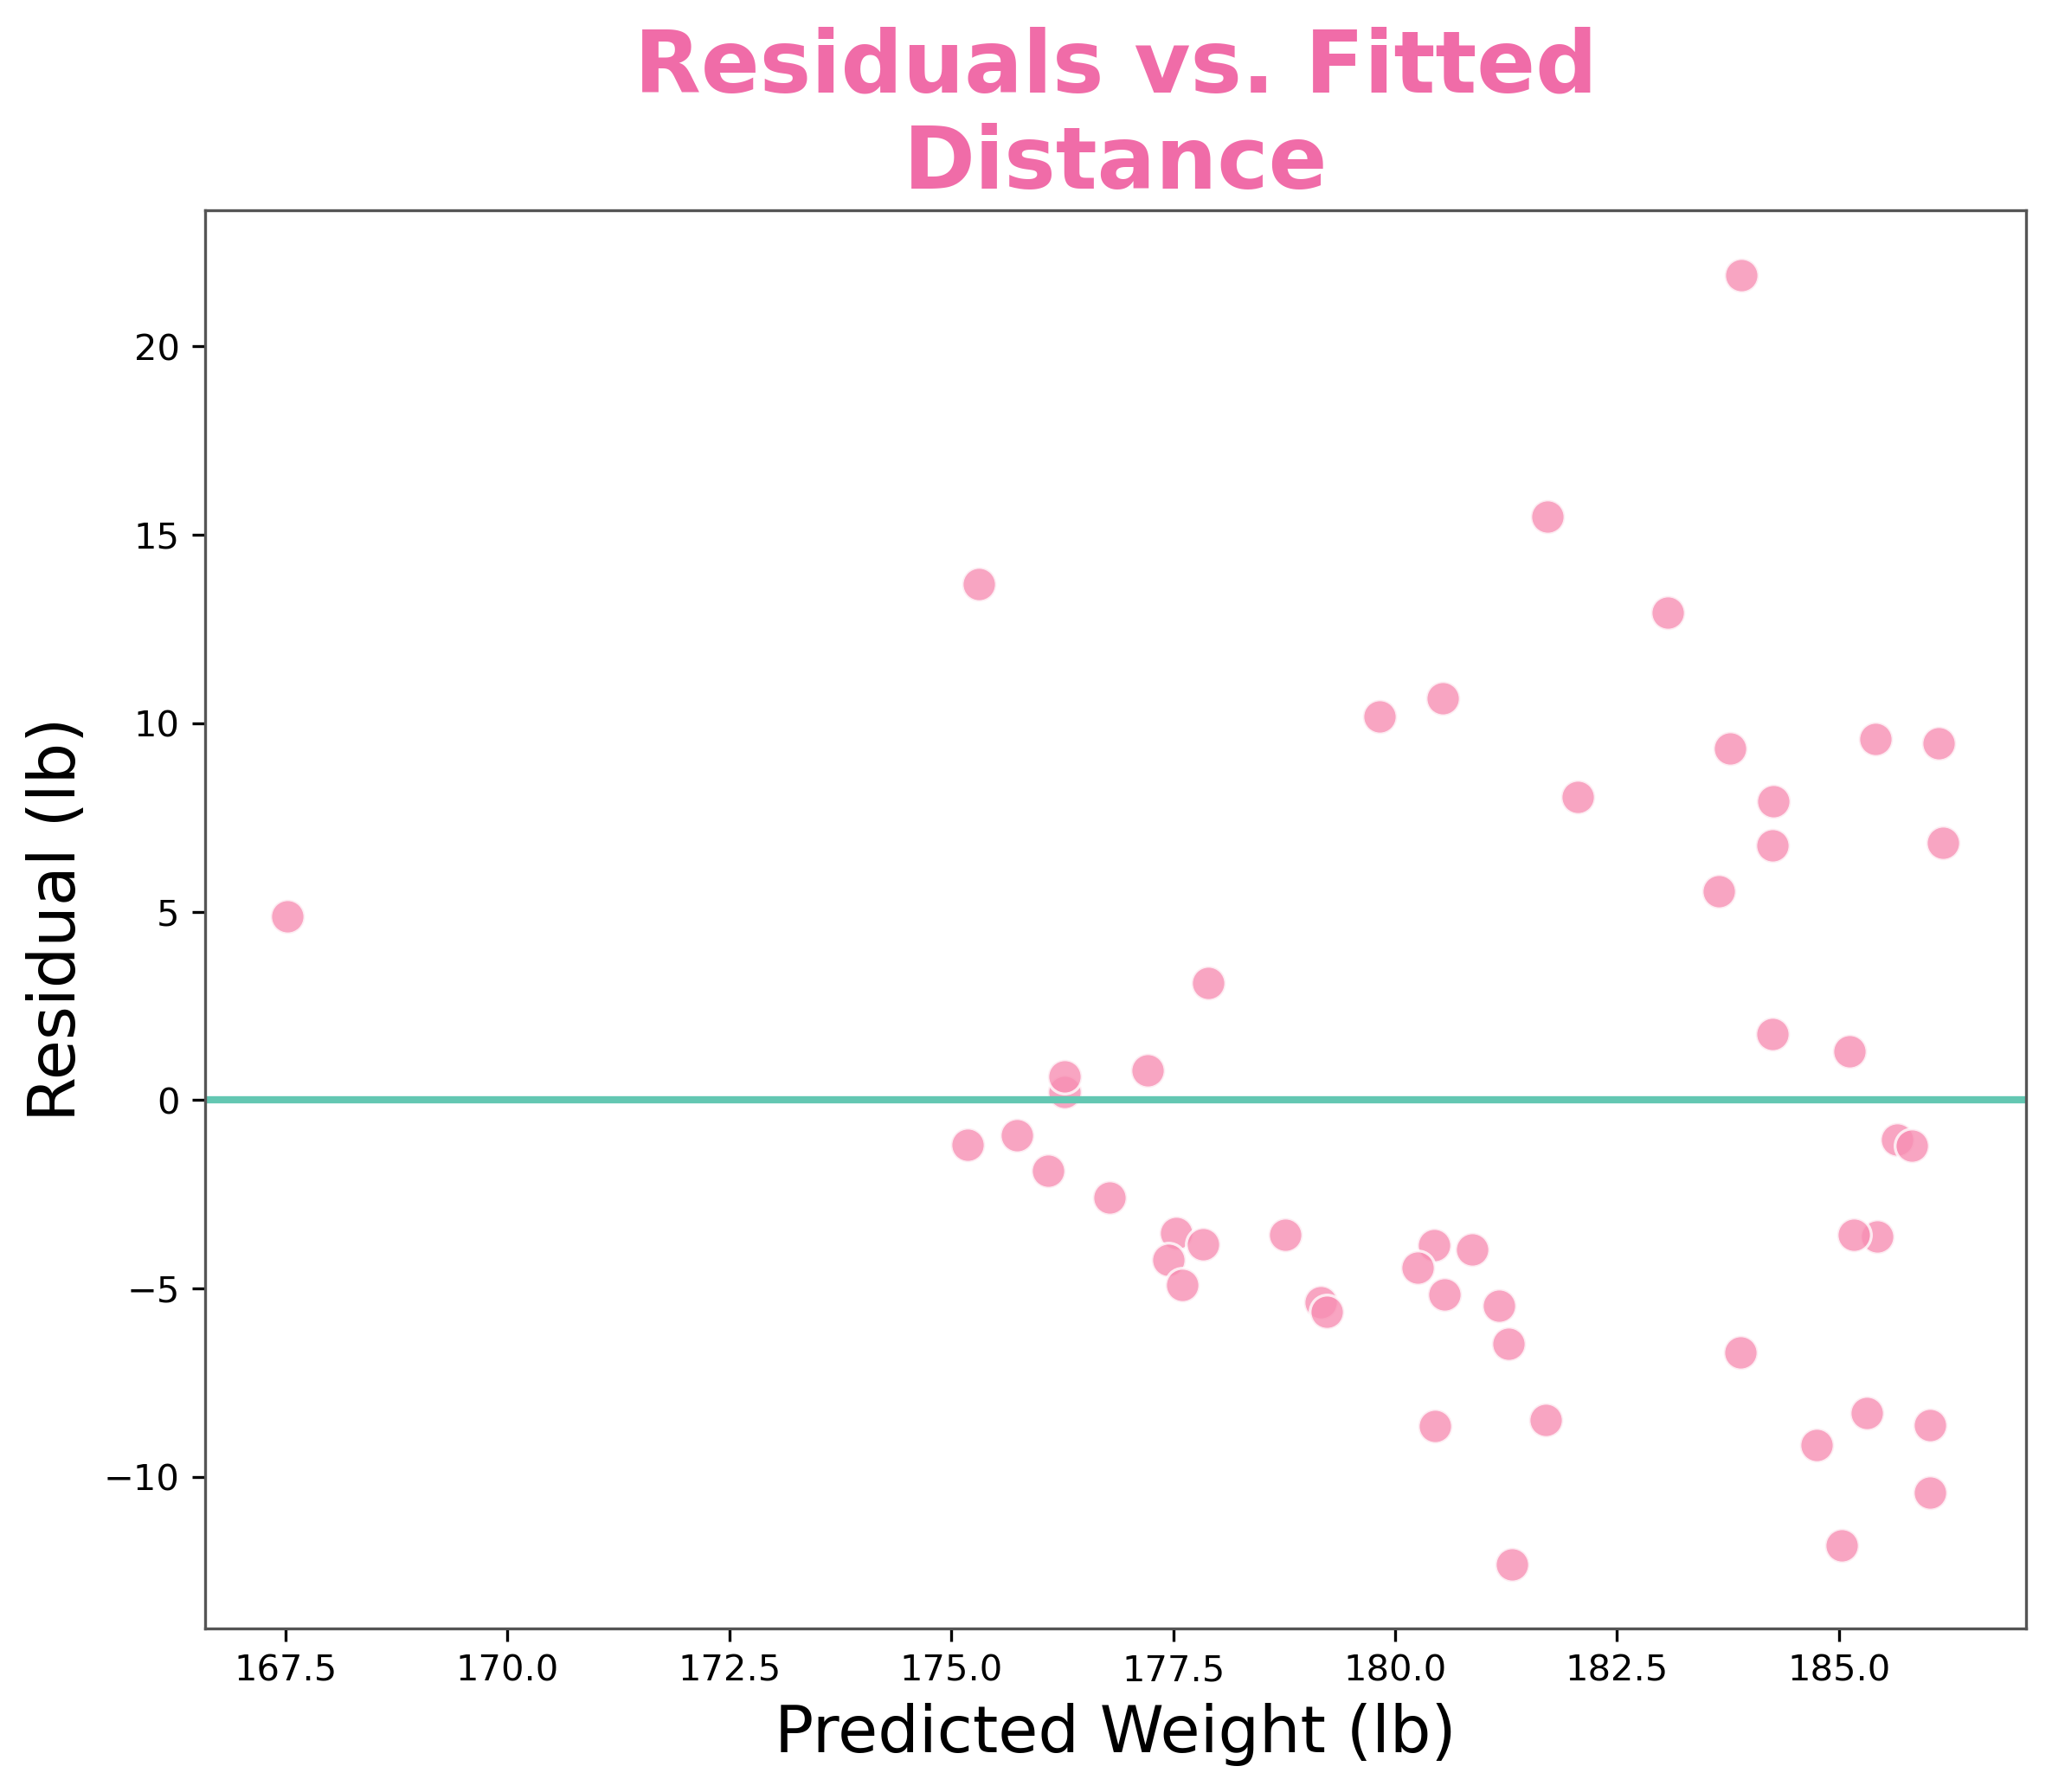
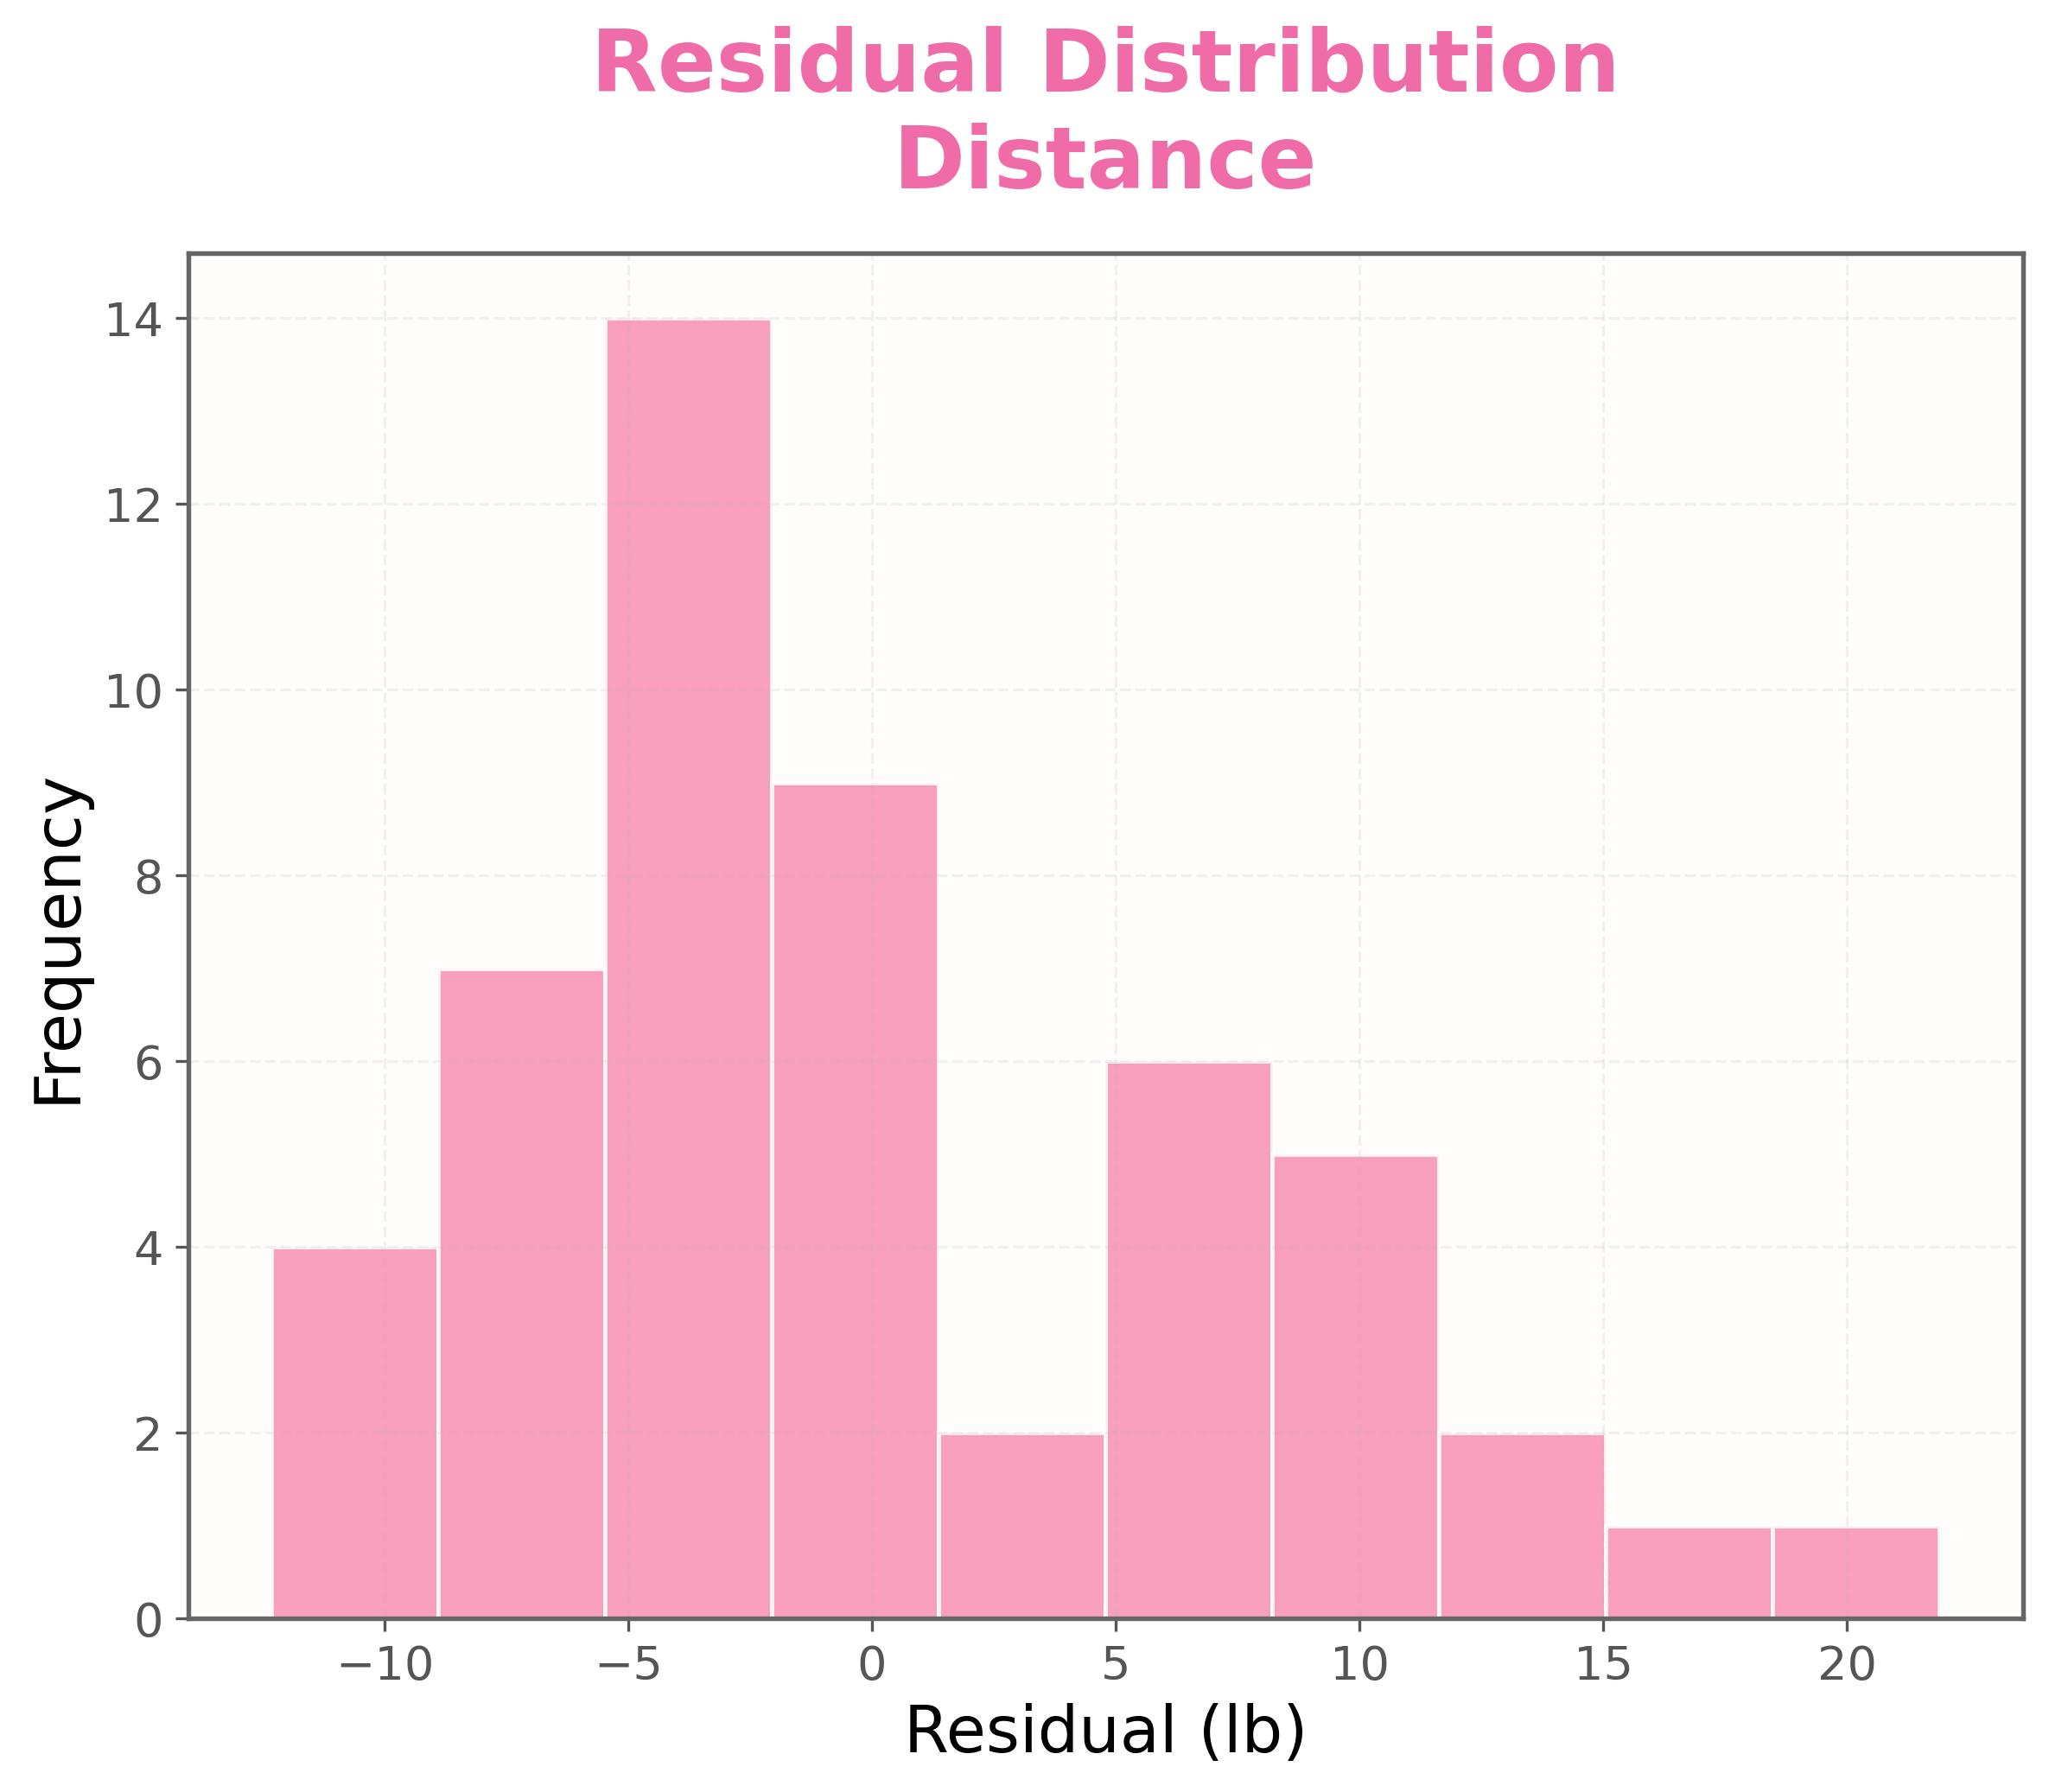

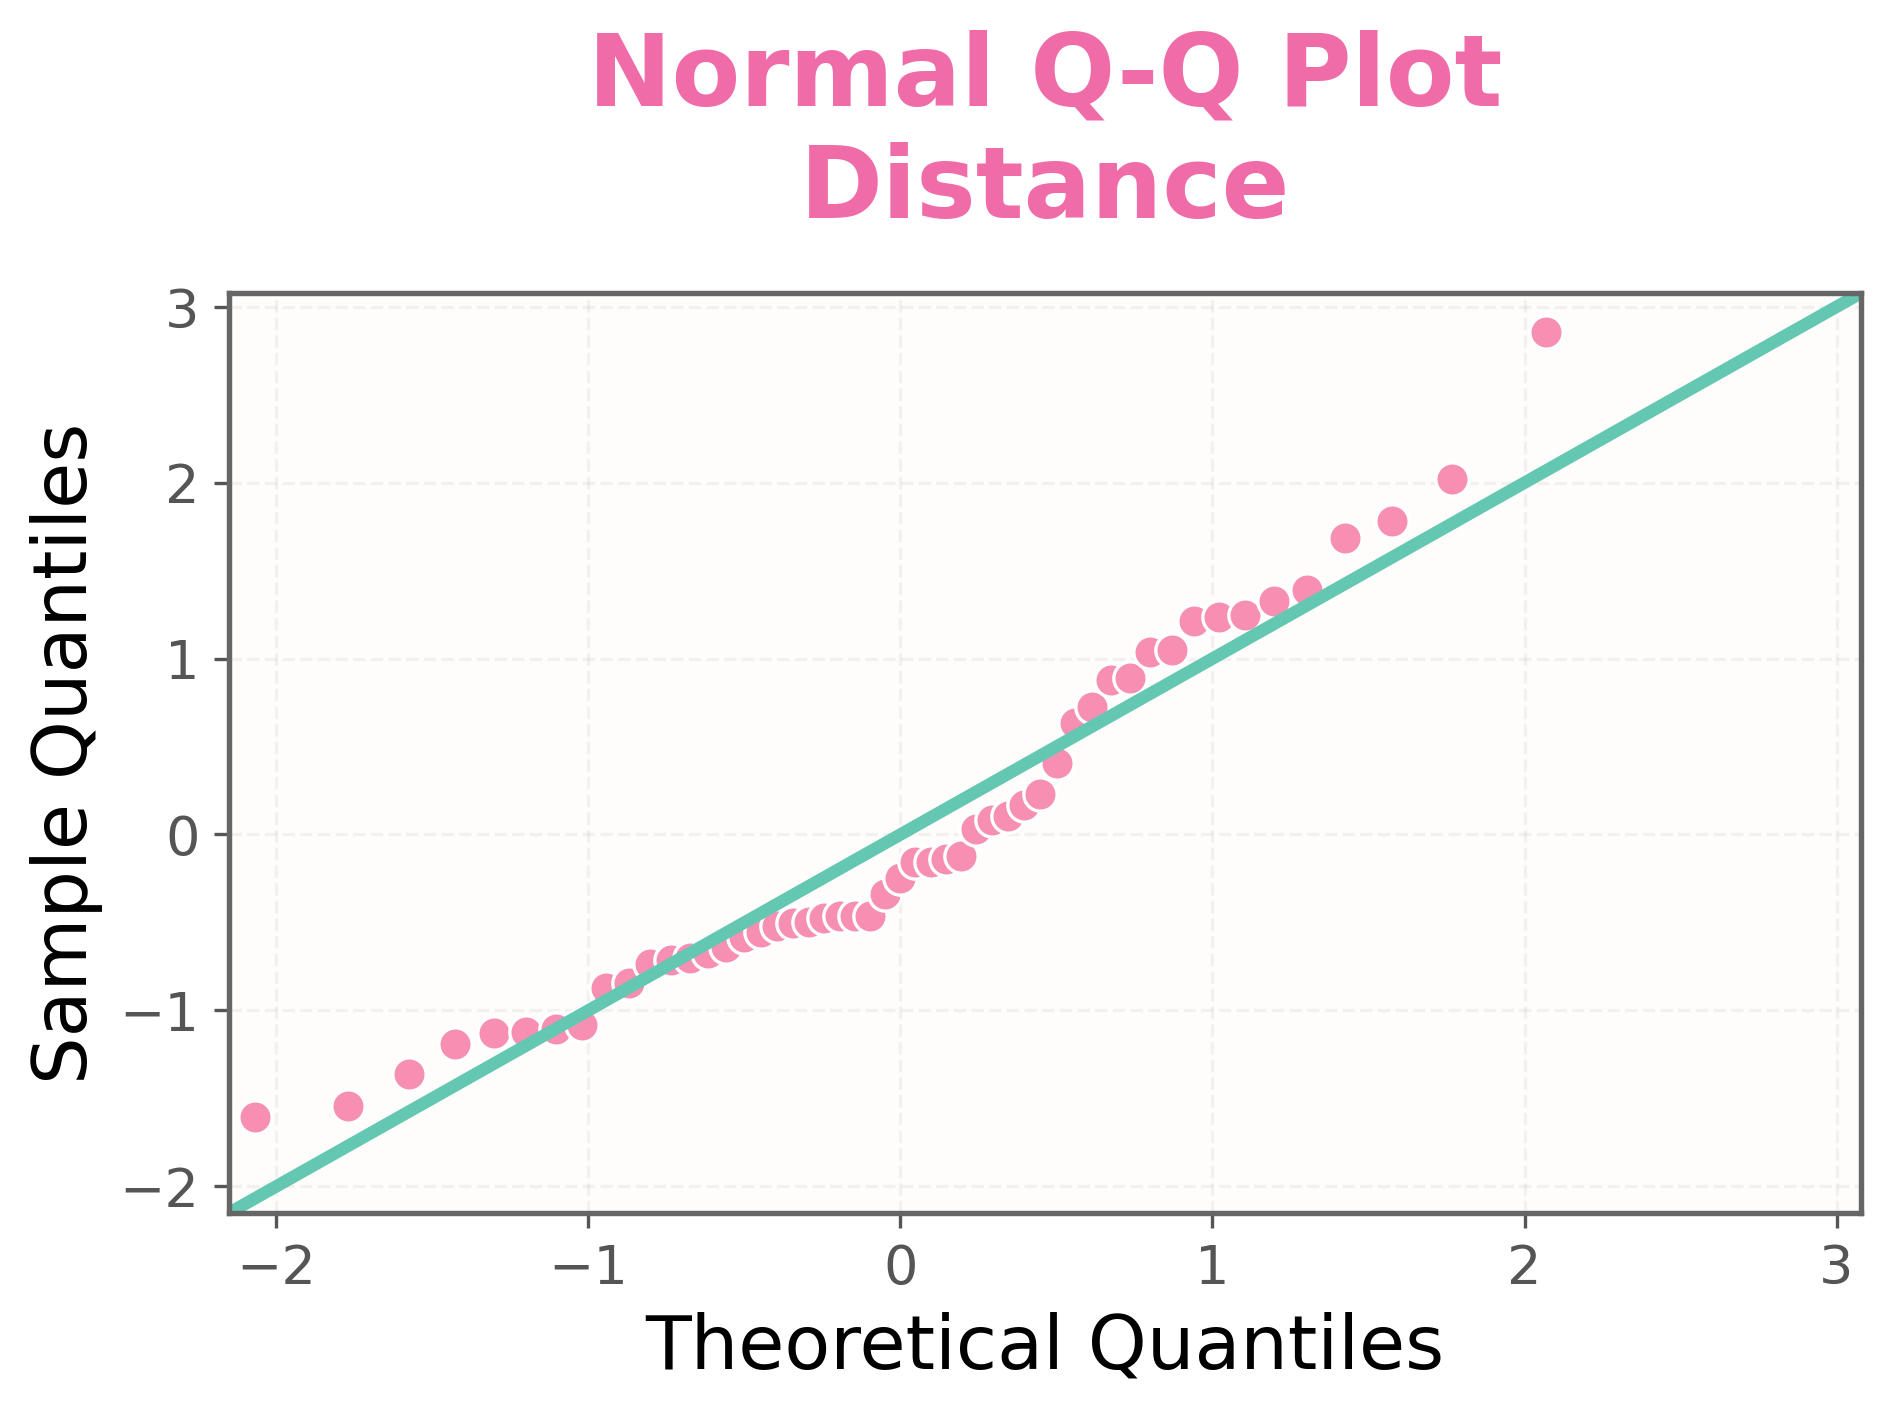




The residual diagnostics indicate that the linear model provides a reasonable approximation of the relationship between distance and body weight.

Residuals were centered near zero and exhibited no substantial nonlinear pattern. Although mild right-skew and several larger positive residuals were observed, the Q–Q plot indicated that the residuals were approximately normally distributed through most of the distribution. Overall, no severe violations of the regression assumptions were identified.

### Apple Step Count Results


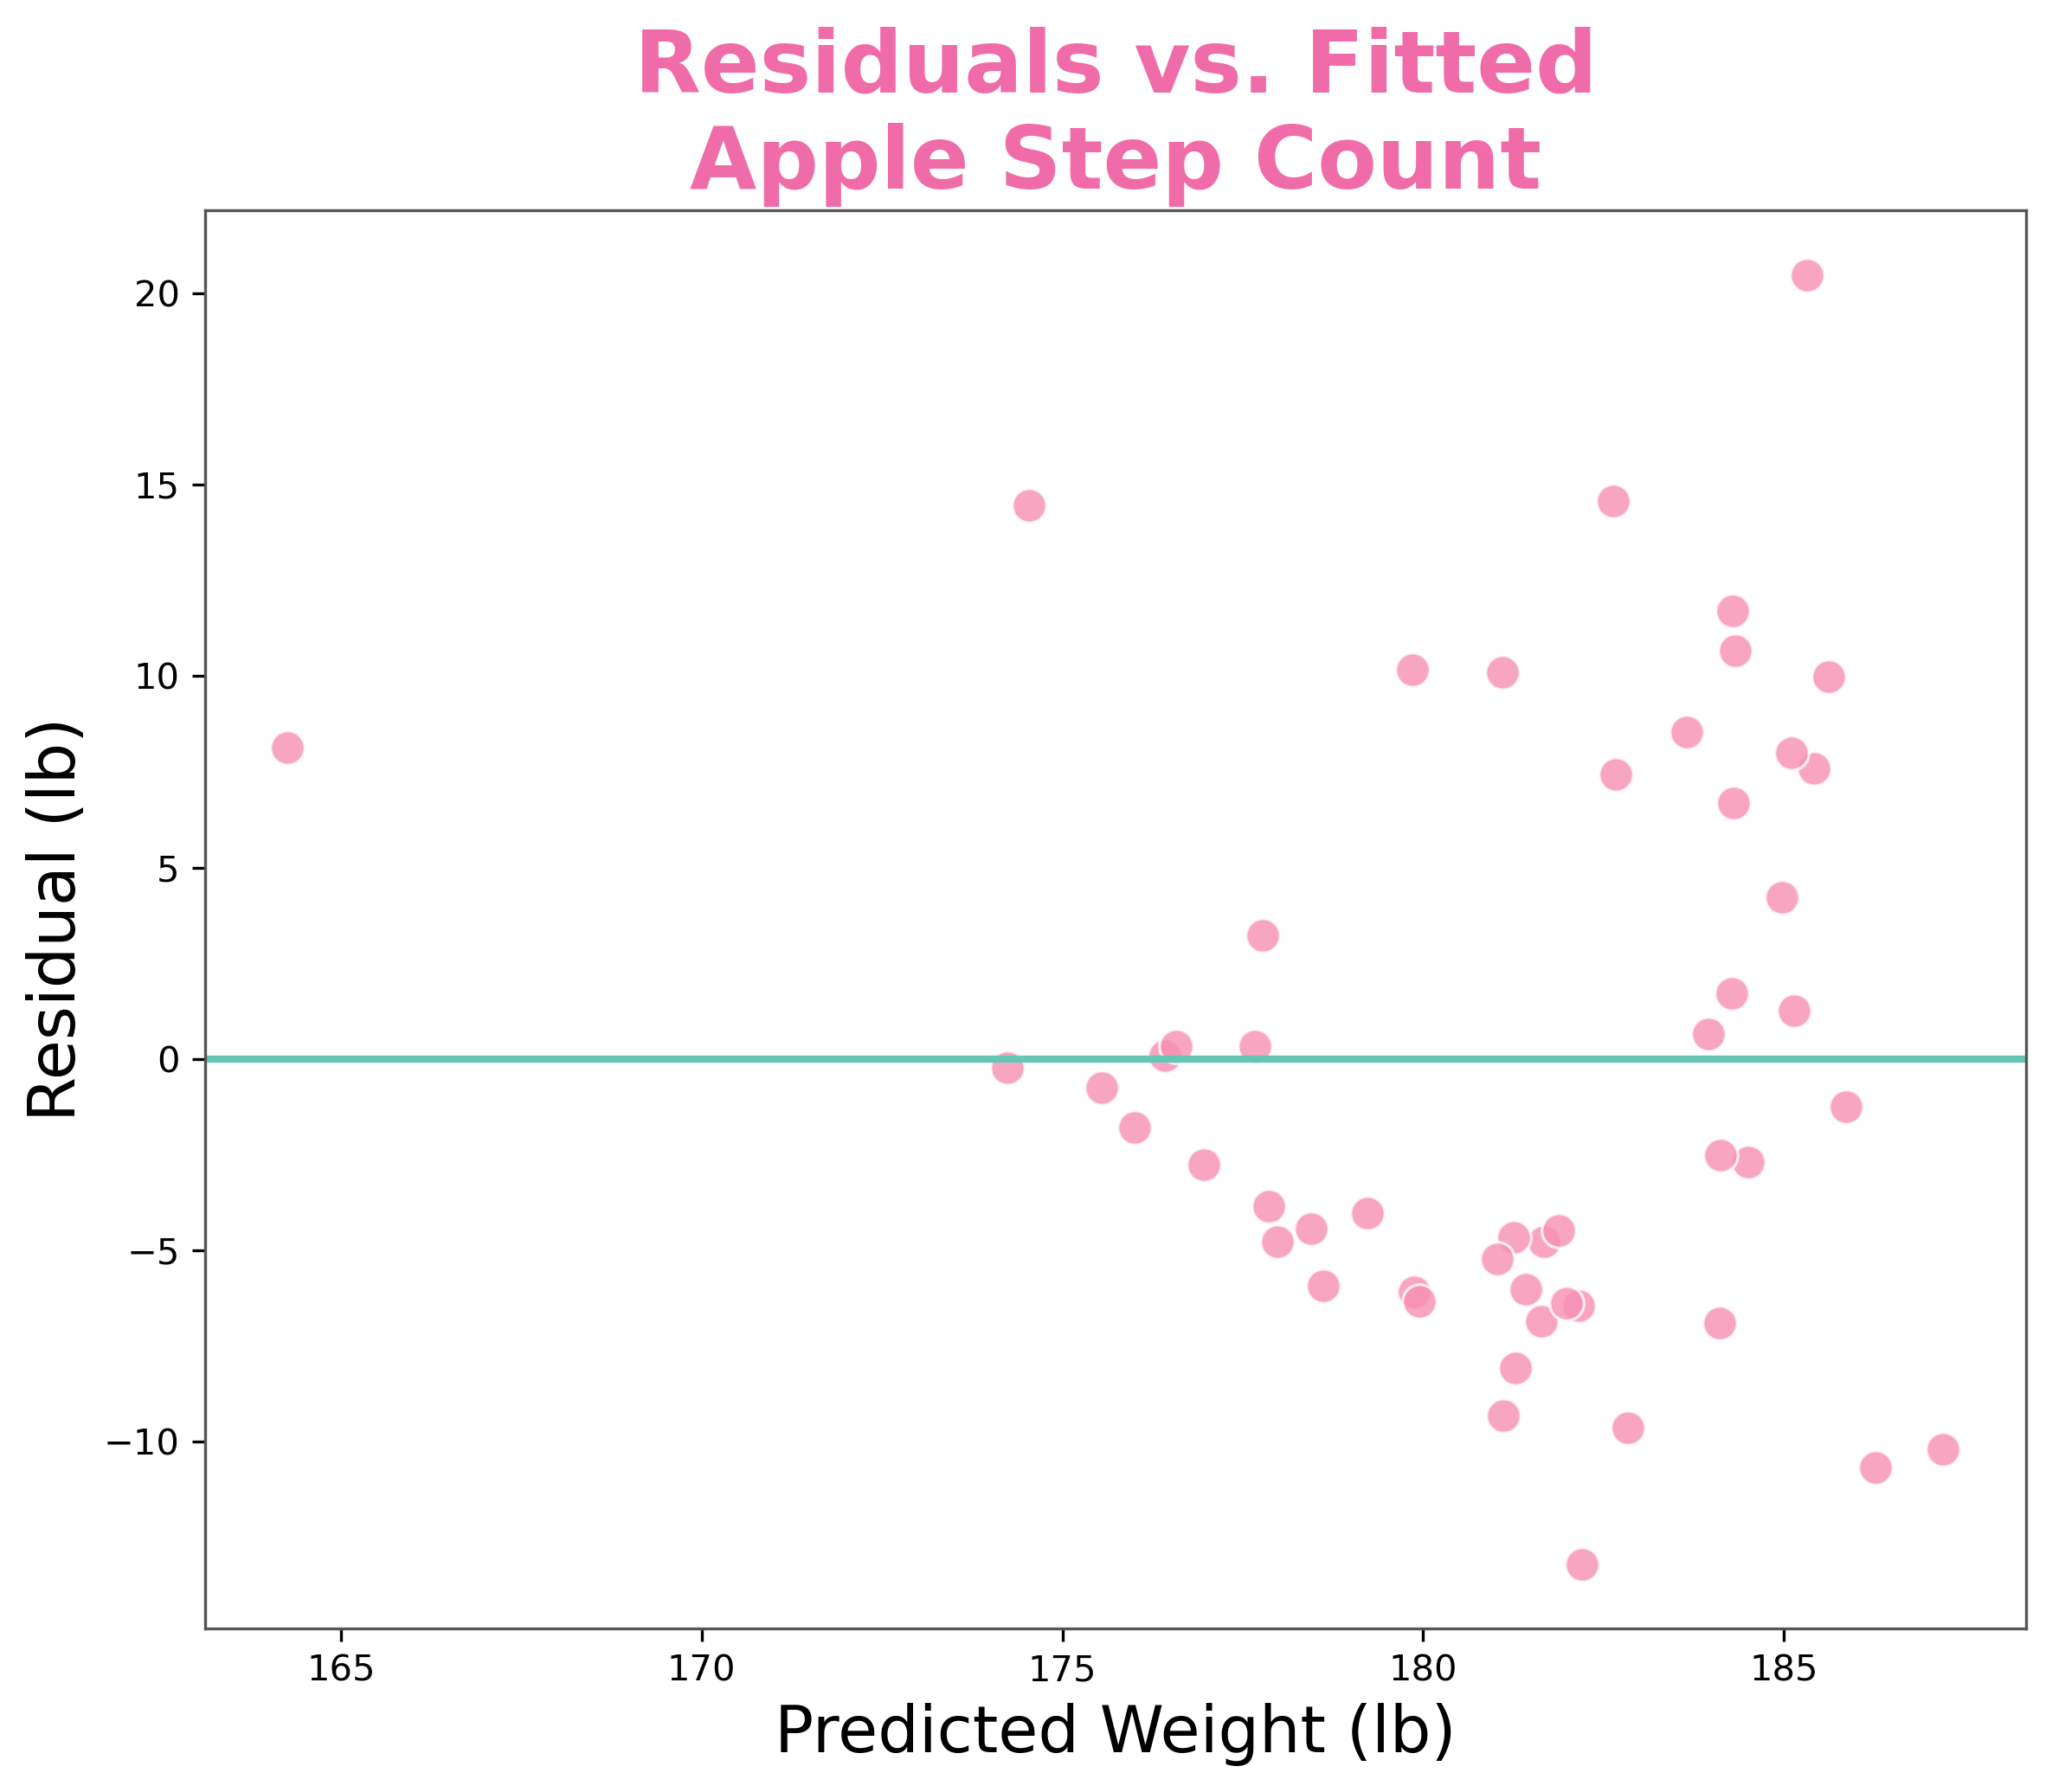

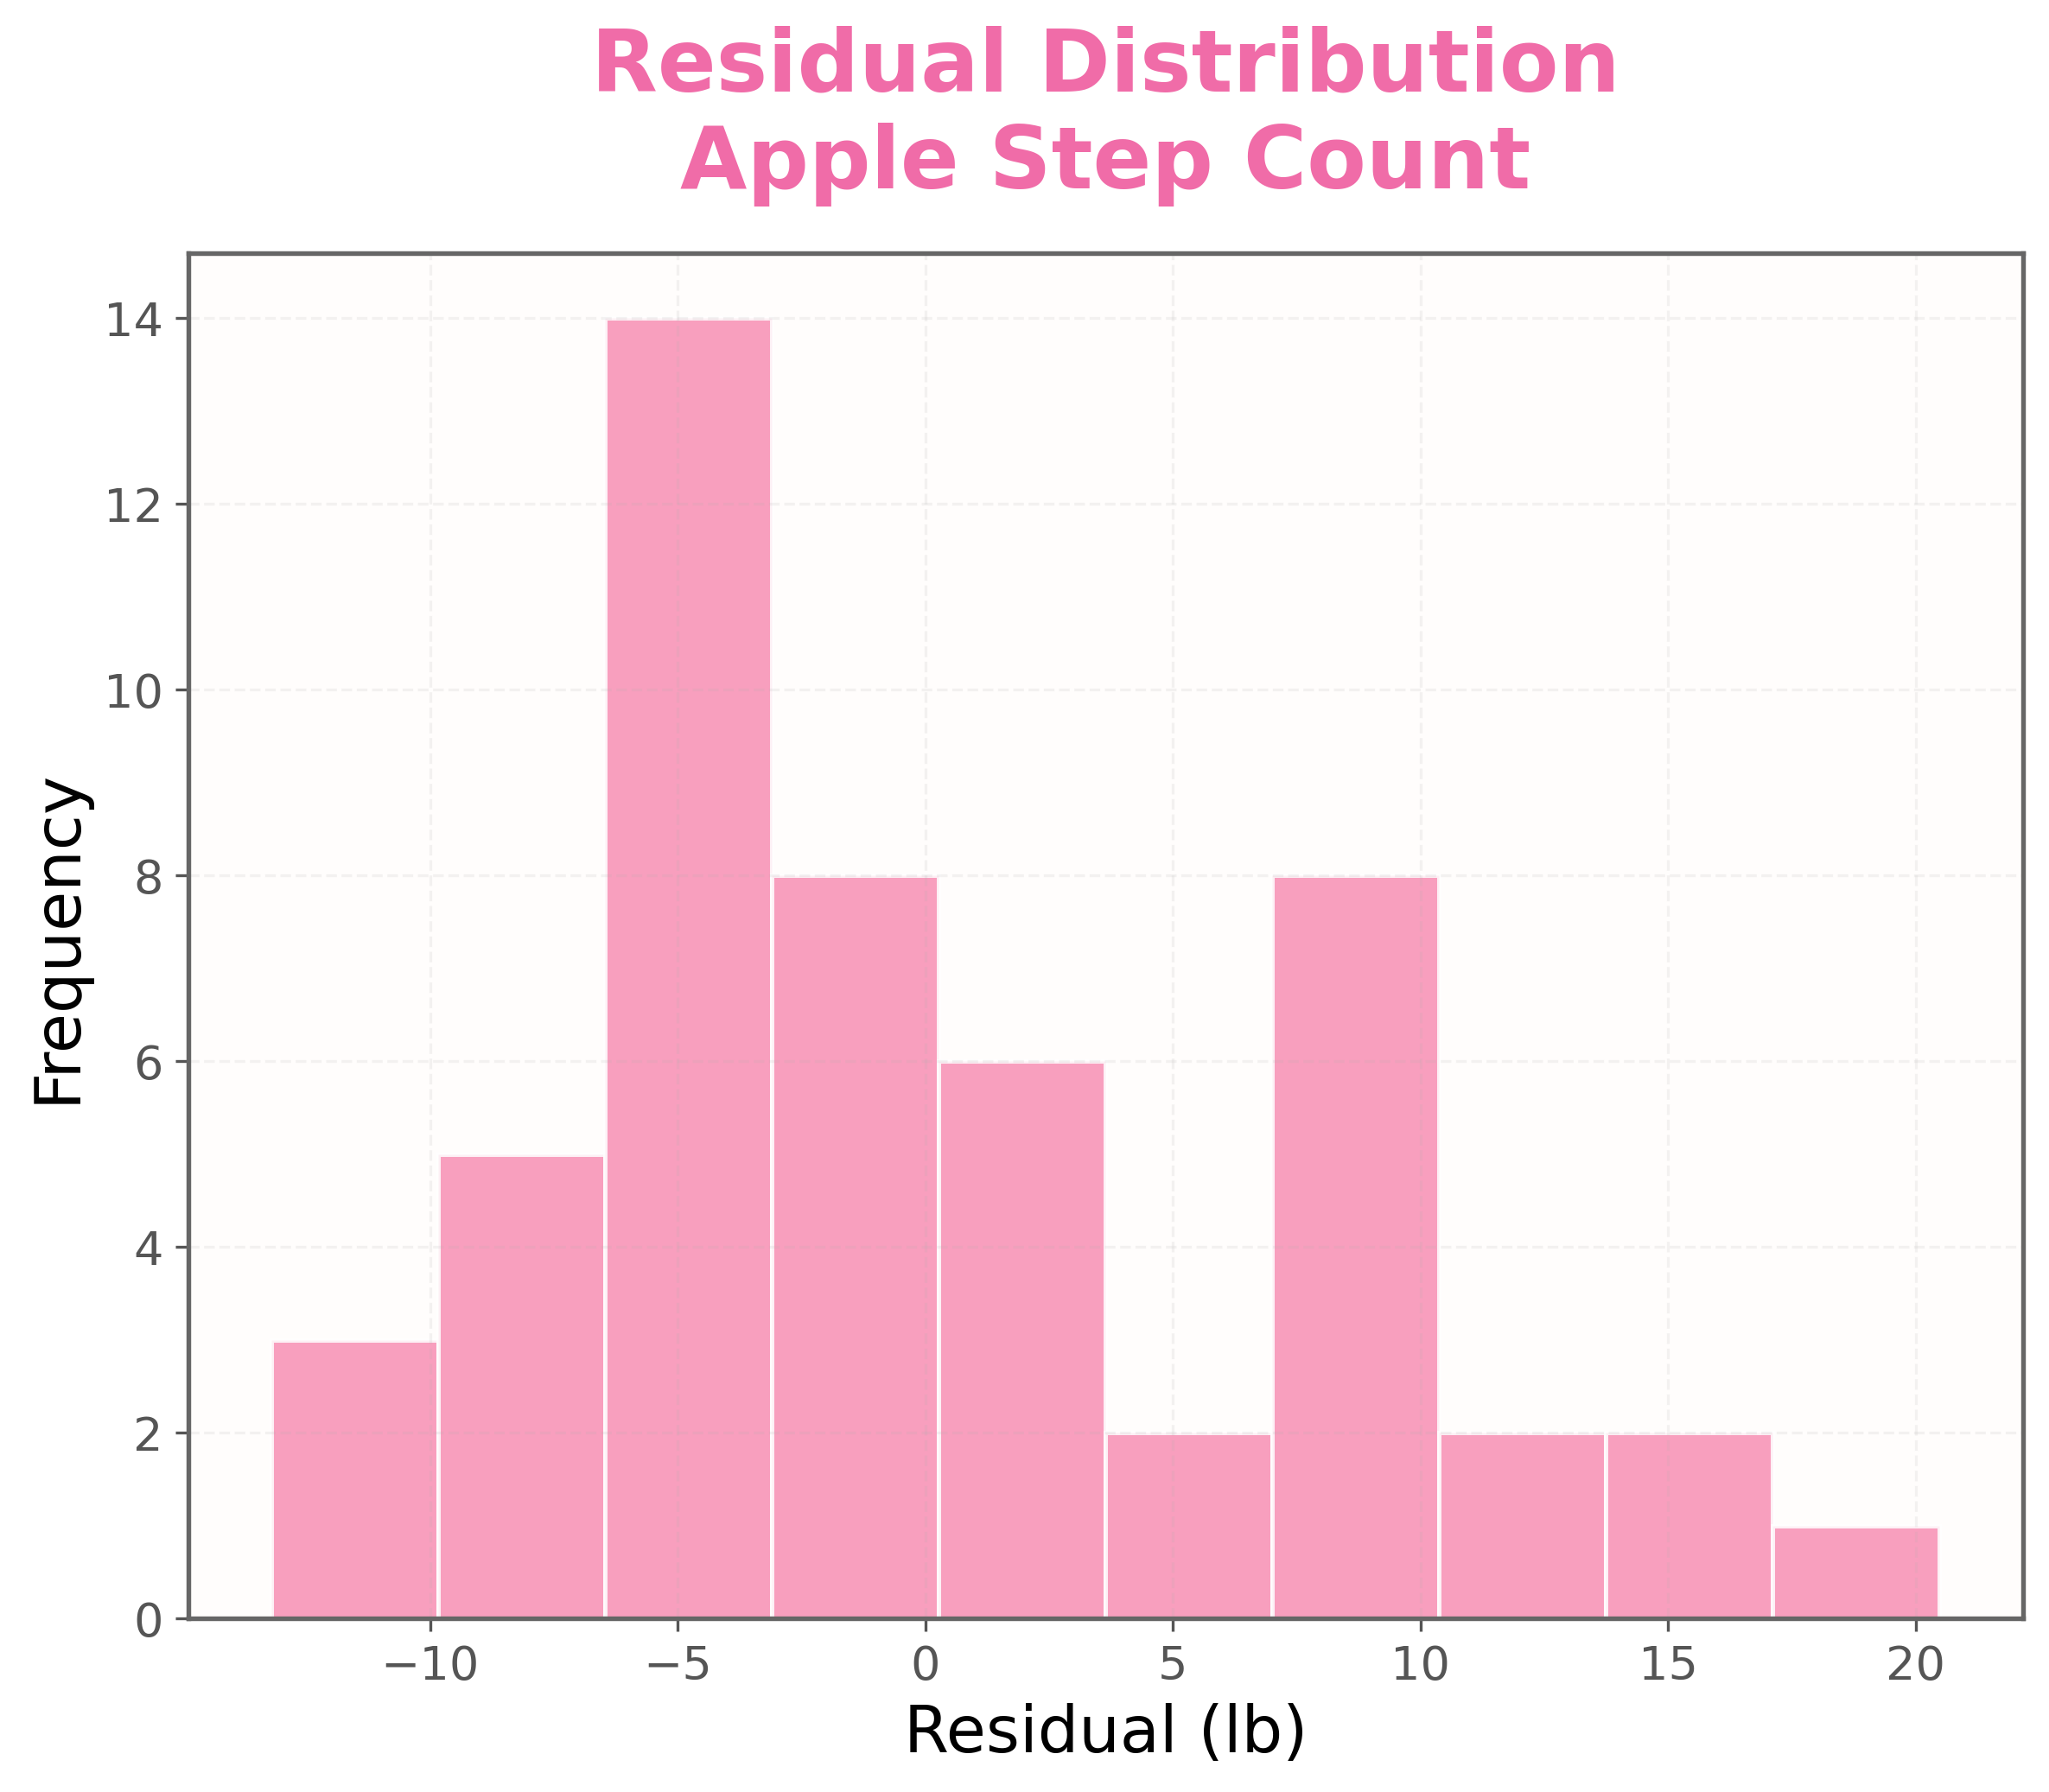

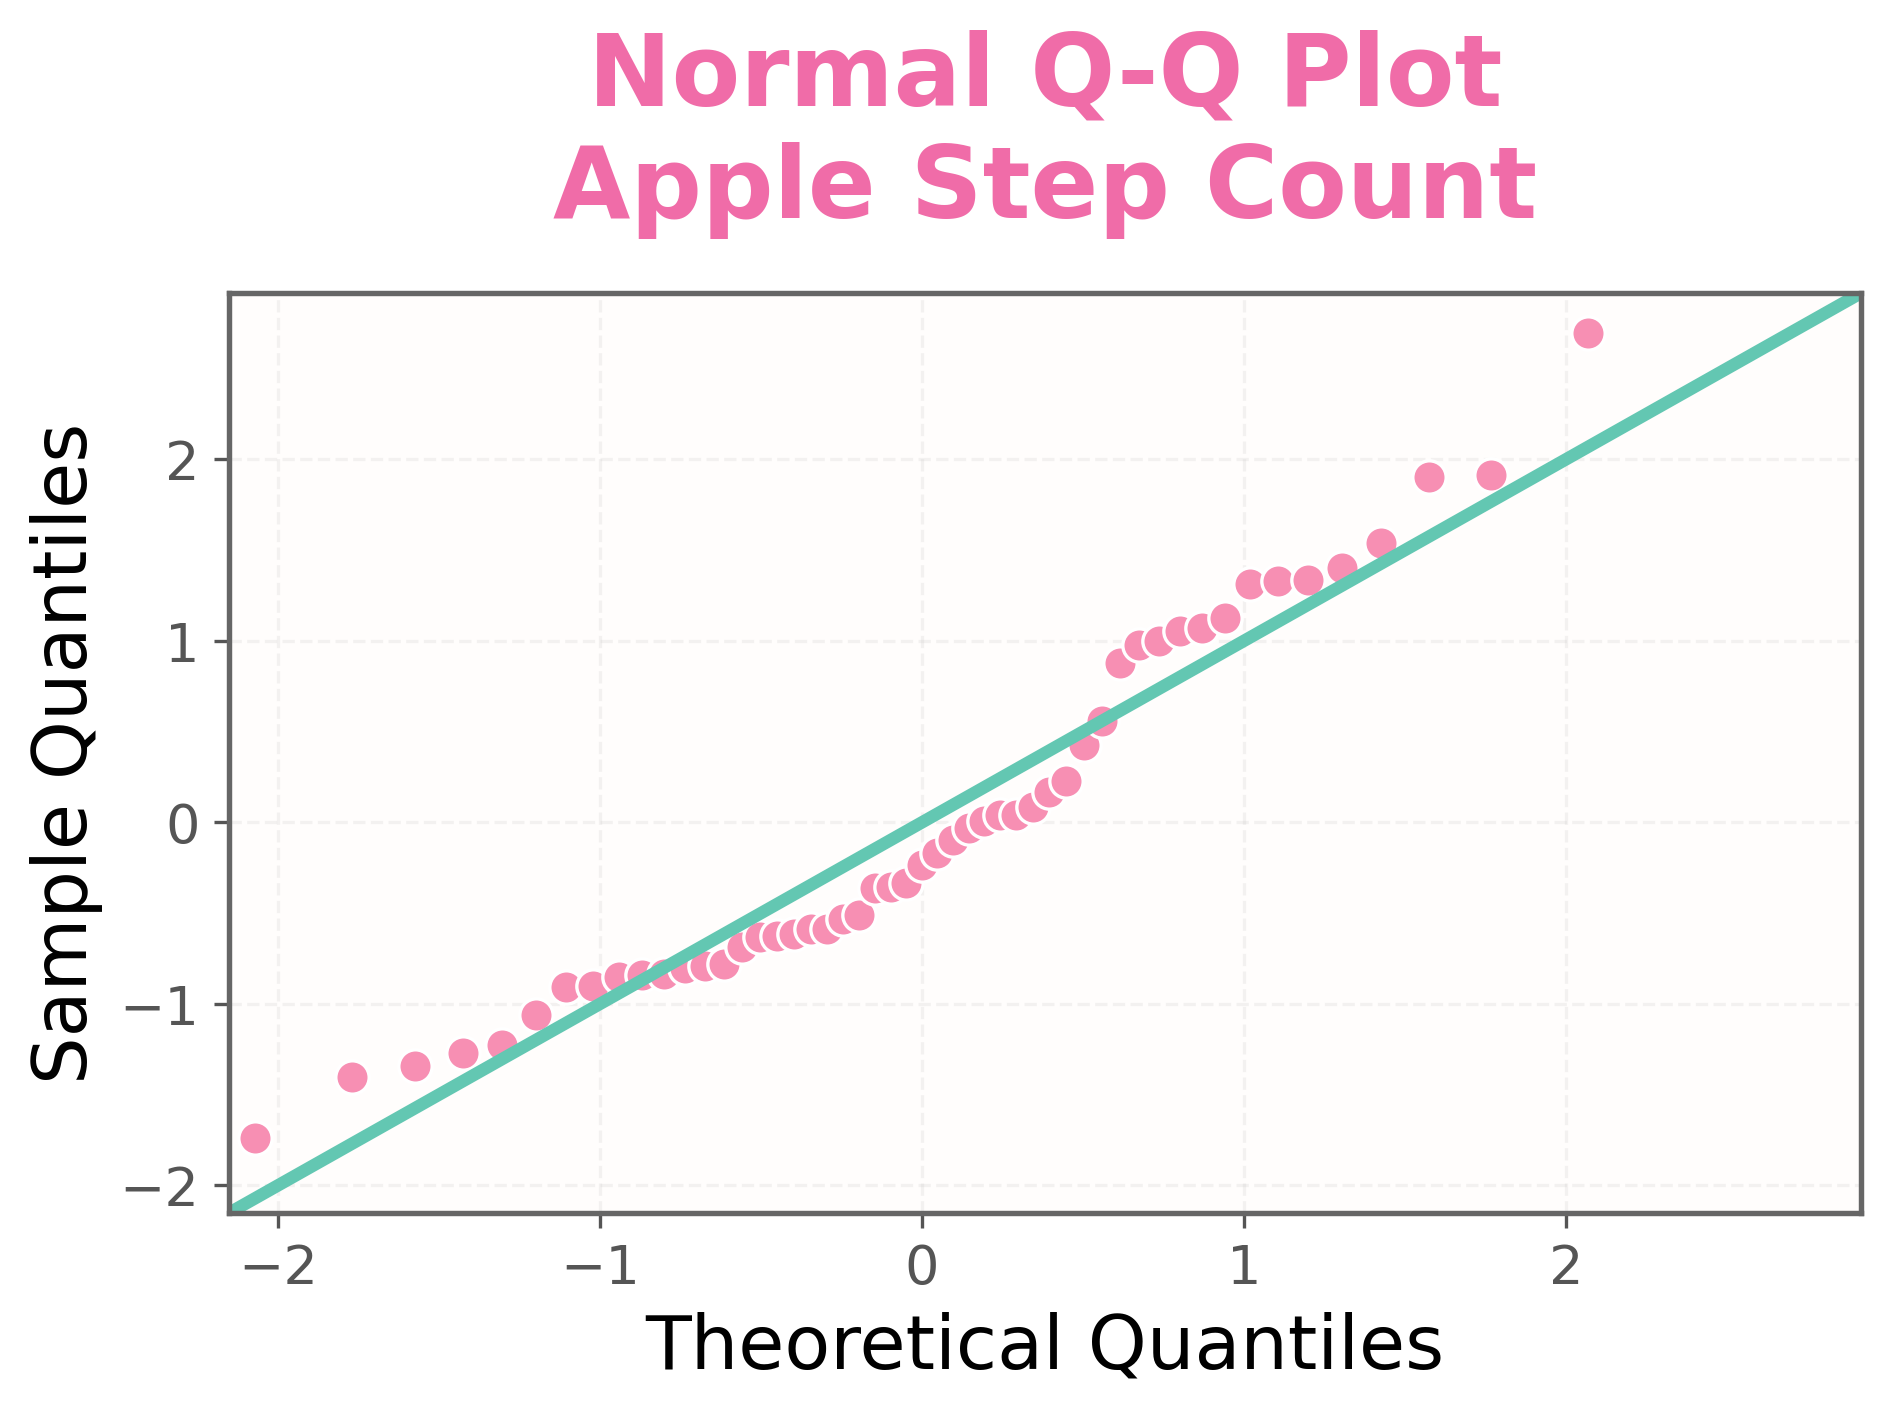


The residual diagnostics indicate that the linear model provides a reasonable approximation of the relationship between Apple Step Count and body weight.

The residual-versus-fitted plot showed no obvious nonlinear trend, although the variability of the residuals increased slightly for larger predicted body weights. The residual histogram demonstrated mild positive skew, and the Q–Q plot showed modest departures from normality in the upper tail caused by several larger positive residuals. Despite these minor deviations, the diagnostic plots suggest that the assumptions of simple linear regression were reasonably satisfied for exploratory modeling.

### Walking Length


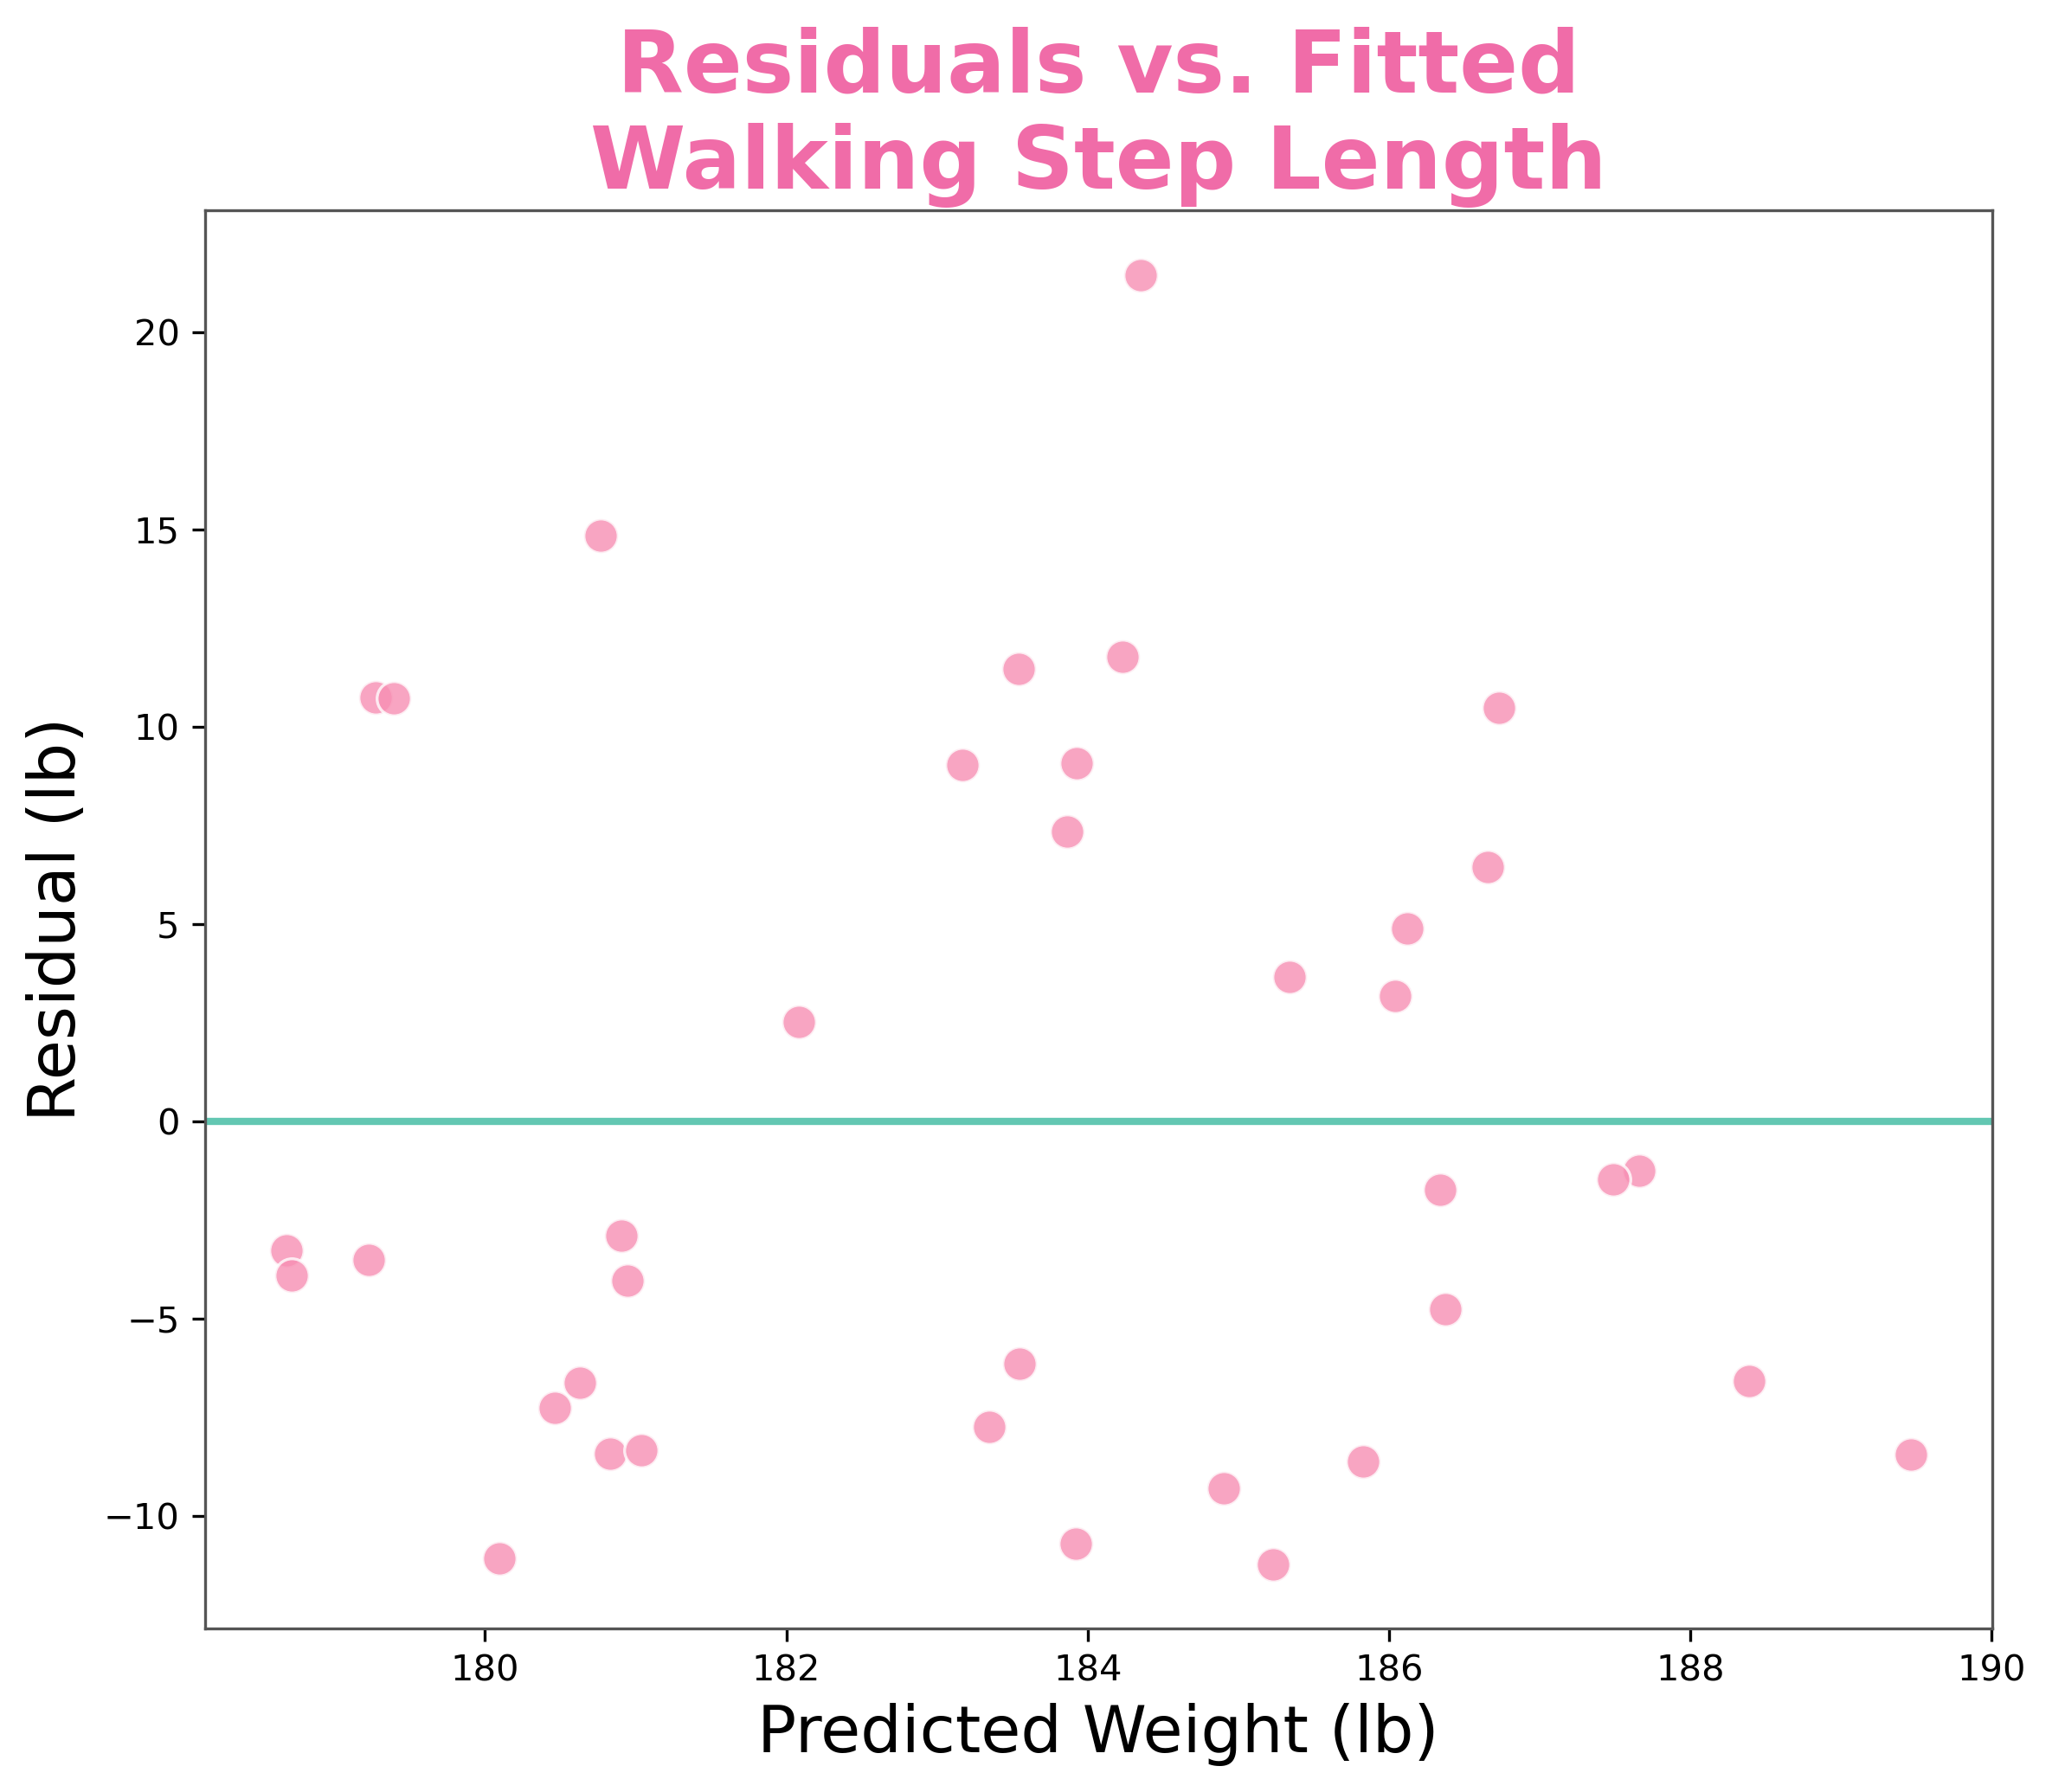

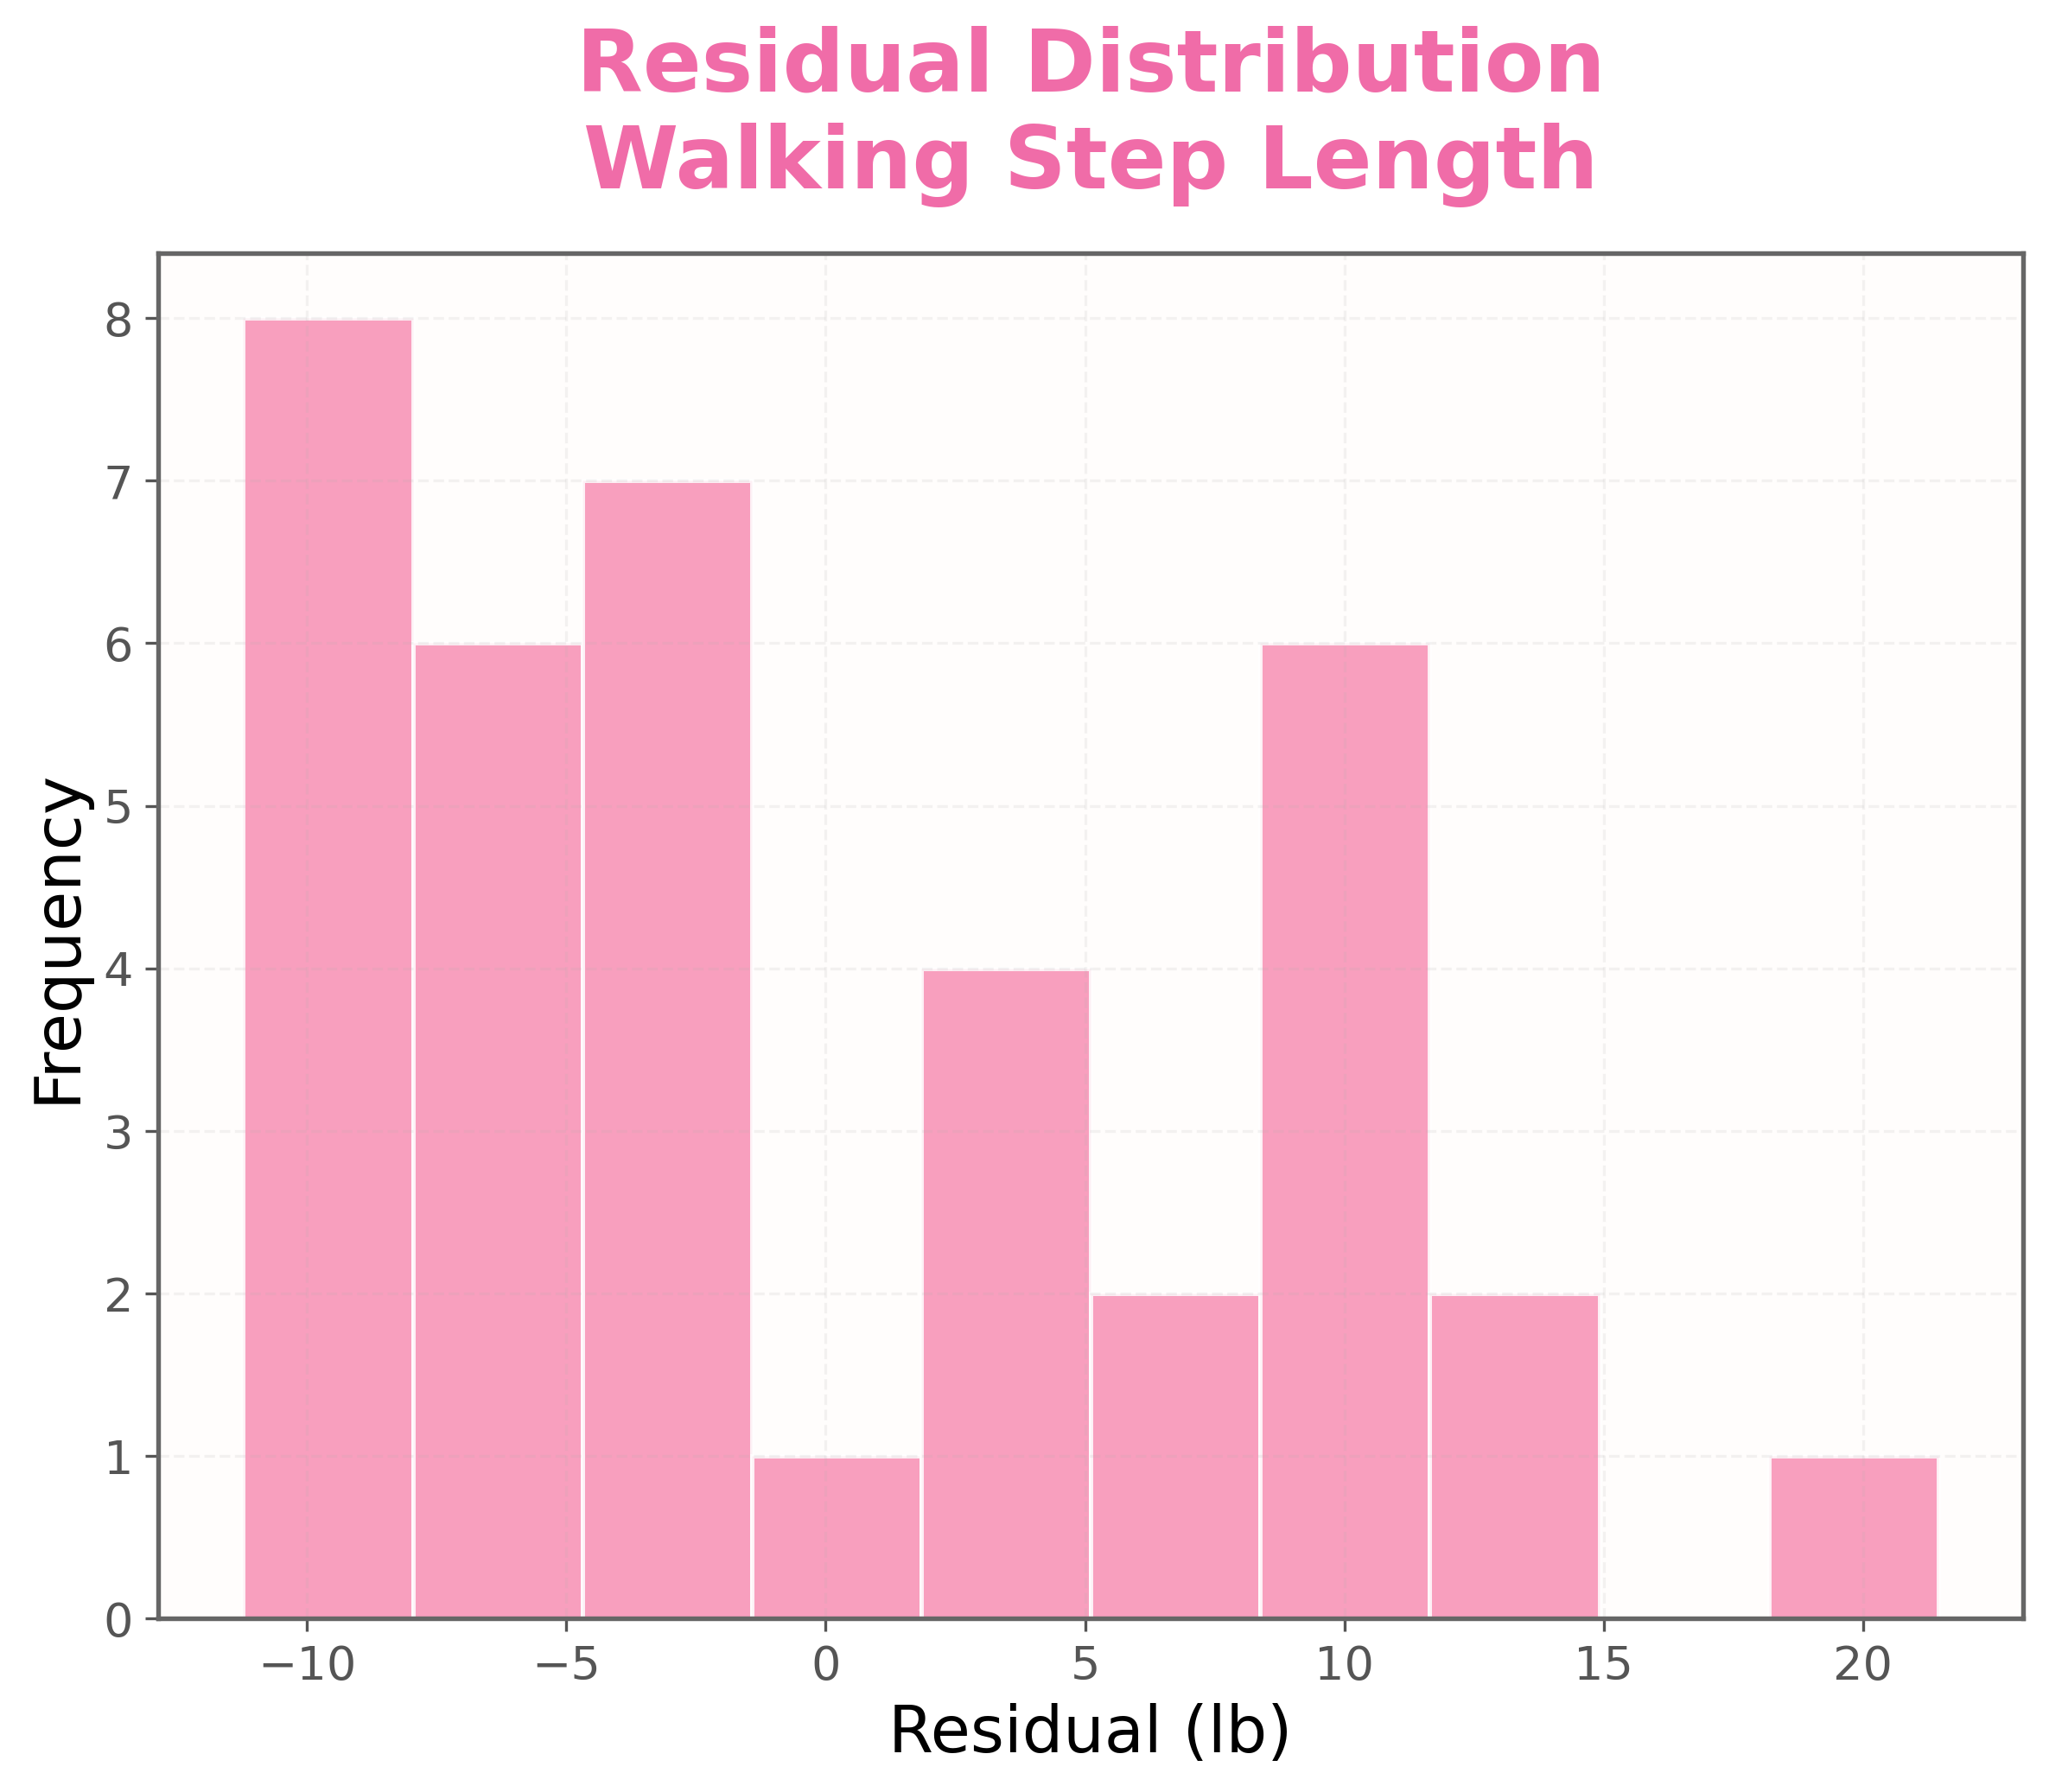
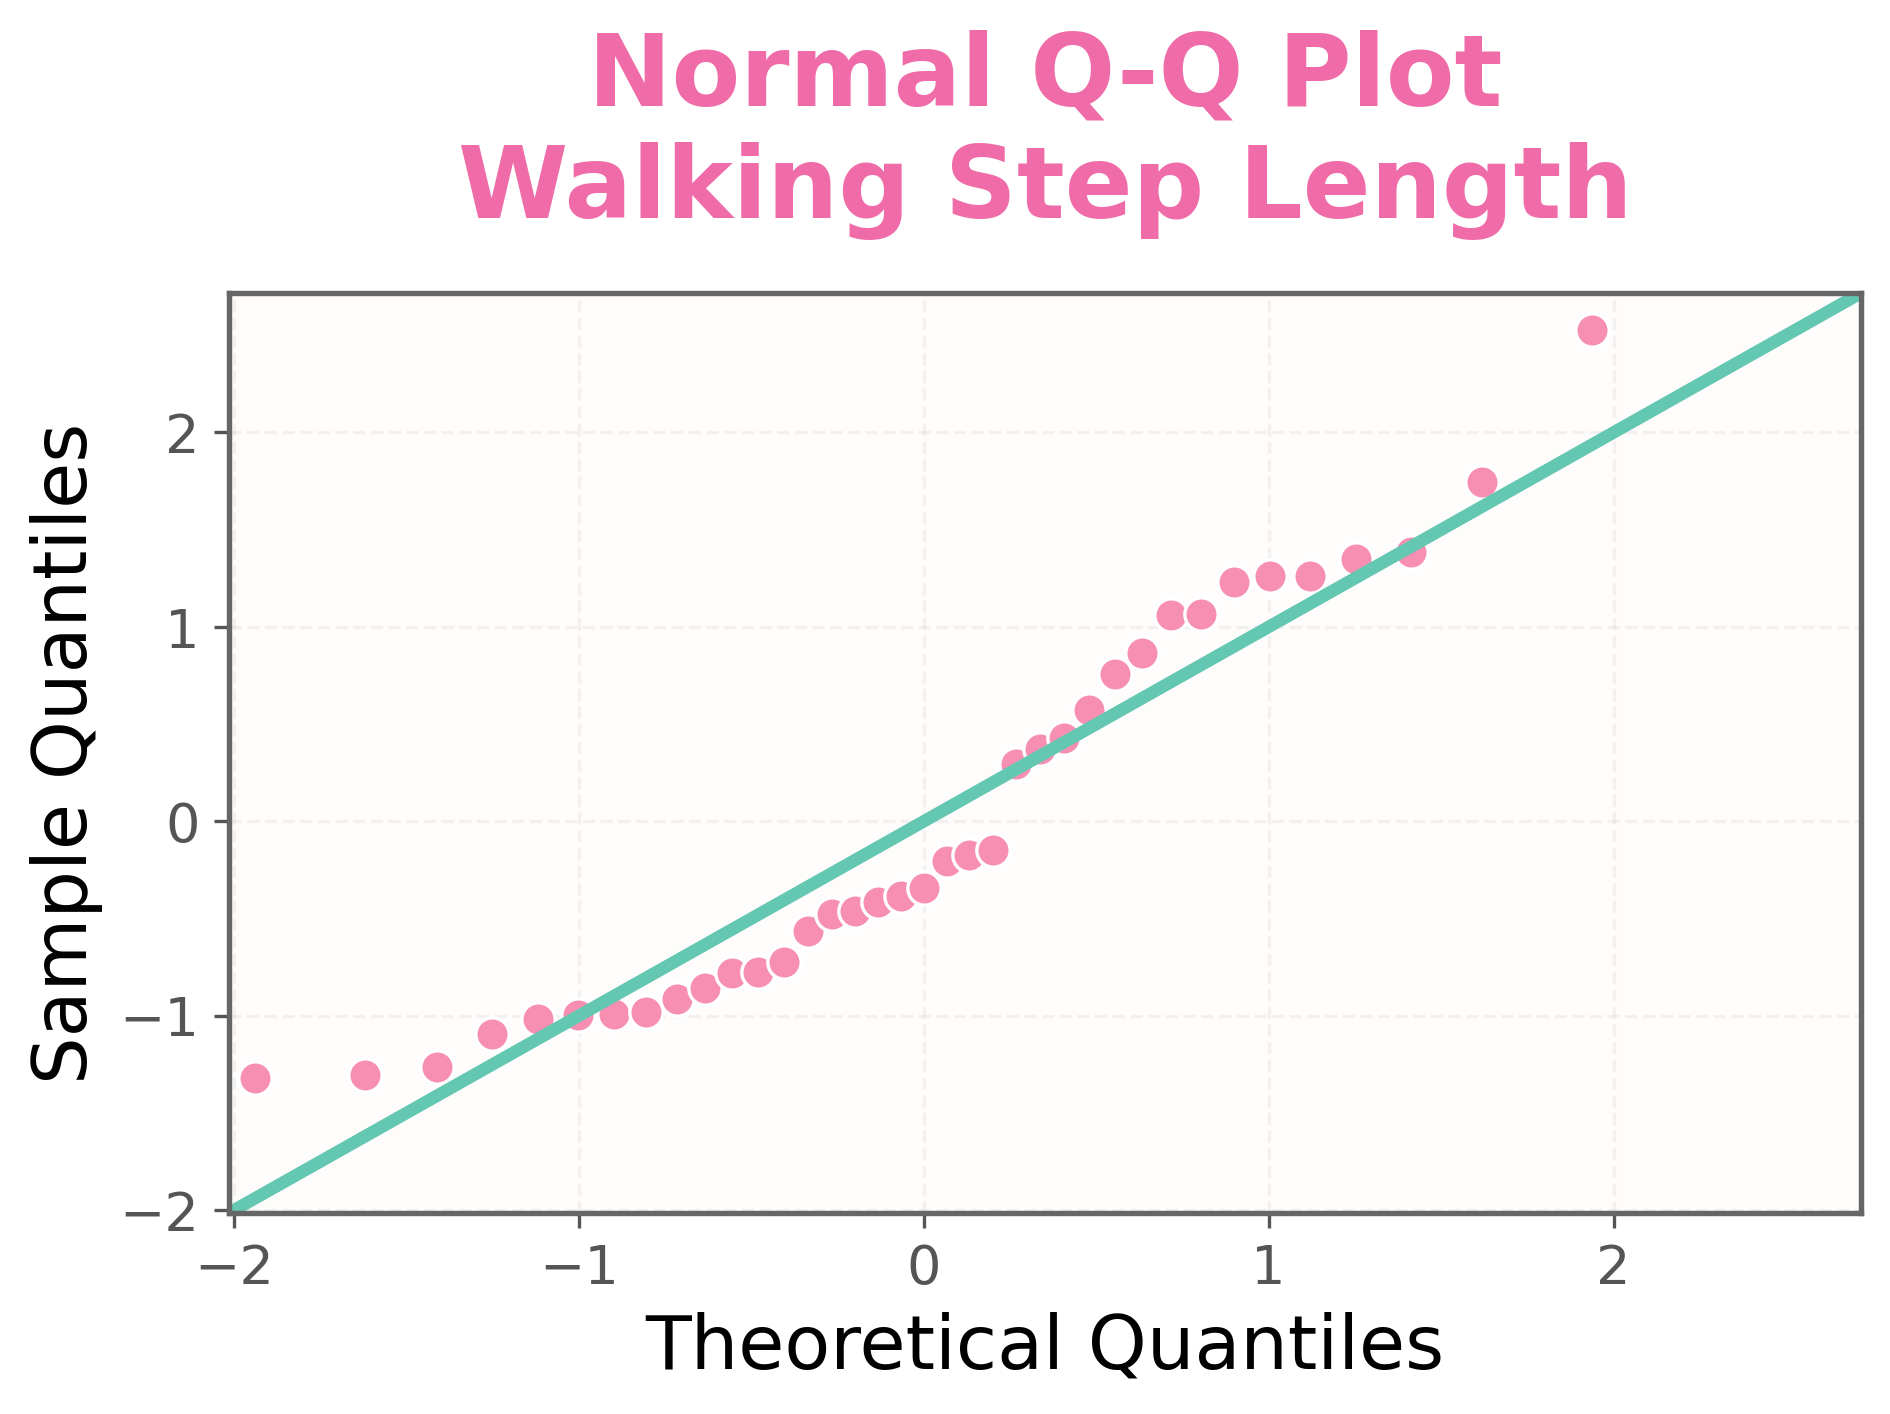


The residual diagnostics indicate that the linear model provides a reasonable approximation of the relationship between walking step length and body weight, although the model exhibited greater unexplained variability than the stronger Tier 1 predictors.

The residual-versus-fitted plot showed no pronounced nonlinear pattern, but the residuals were more widely dispersed than those observed for Distance and Apple Step Count. The residual histogram displayed moderate skew resulting from several larger prediction errors, while the Q–Q plot demonstrated modest departures from normality in the upper tail. These findings are consistent with the model's lower explanatory power (*R²* = 0.108) and smaller sample size (*n* = 37). Nevertheless, no severe violations of the regression assumptions were identified.

Overall, the residual diagnostics supported the conclusions drawn from the regression screening analysis. Distance and Apple Step Count exhibited the strongest overall model behavior, while Walking Step Length demonstrated greater residual variability but remained acceptable for exploratory analysis. Collectively, the diagnostic plots indicate that the retained Tier 1 models satisfy the assumptions of simple linear regression sufficiently well to support the interpretation of the observed statistical relationships.

# Phase 8 – Multiple Linear Regression

Following the simple linear regression screening analysis, the retained candidate predictors were evaluated simultaneously using multiple linear regression.

Unlike the previous analysis, which evaluated each predictor independently, multiple regression allows several predictors to compete for explanatory power within the same model. As a result, predictors that appear important individually may no longer remain significant once shared information between variables is taken into account.

Whereas the previous phase examined each predictor independently, multiple linear regression estimates the relationship between body weight and several predictors at the same time. This allows each regression coefficient to be interpreted while statistically controlling for the remaining predictors in the model and provides insight into each predictor's independent contribution after accounting for shared variation.

The objectives of this phase are to:

- Evaluate whether combining predictors improves model performance beyond simple linear regression.
- Determine which predictors remain important after adjusting for the effects of the other predictors.
- Assess multicollinearity among the retained predictors using correlation analysis and Variance Inflation Factors (VIFs).
- Compare candidate multiple regression models while considering predictive performance, sample size, and model stability.
- Select the most appropriate multivariable model for interpretation.
- Validate the assumptions of the final model using residual diagnostics.

---
## Phase 8.1 – Candidate Predictor Selection

Candidate predictors for the multiple regression analysis were selected from the statistically significant models identified during the simple regression screening phase.

The statistically significant Tier 1 predictors considered for multiple regression were:

- Distance
- Apple Step Count
- Walking Step Length

These variables were selected because each demonstrated a statistically significant linear relationship with body weight while maintaining sufficient data coverage across the longitudinal measurement timeline.

Before constructing the multiple regression model, the relationships among these predictors were evaluated to identify potential multicollinearity. Because highly correlated predictors can produce unstable coefficient estimates and inflated standard errors, correlation analysis and Variance Inflation Factors (VIFs) were used to determine which variables could be included together within the same model.

Although Apple Step Count exhibited the strongest individual regression model, subsequent multicollinearity analysis revealed that it shared substantial information with Distance. Consequently, Apple Step Count was excluded from the final multiple regression models, and the remaining analysis focused primarily on Distance and Walking Step Length.

---

## Phase 8.2 – Predictor Correlation Analysis

Before fitting multiple regression models, pairwise correlations among the candidate predictors were examined to identify potential multicollinearity.

Multiple linear regression assumes that predictors provide unique information about the response variable. When predictors are strongly correlated with one another, they may describe the same underlying phenomenon, resulting in unstable regression coefficients, inflated standard errors, and difficulty interpreting each predictor's independent contribution.

To evaluate these relationships, a predictor correlation matrix was constructed using the Tier 1 predictors retained from the simple regression screening analysis.

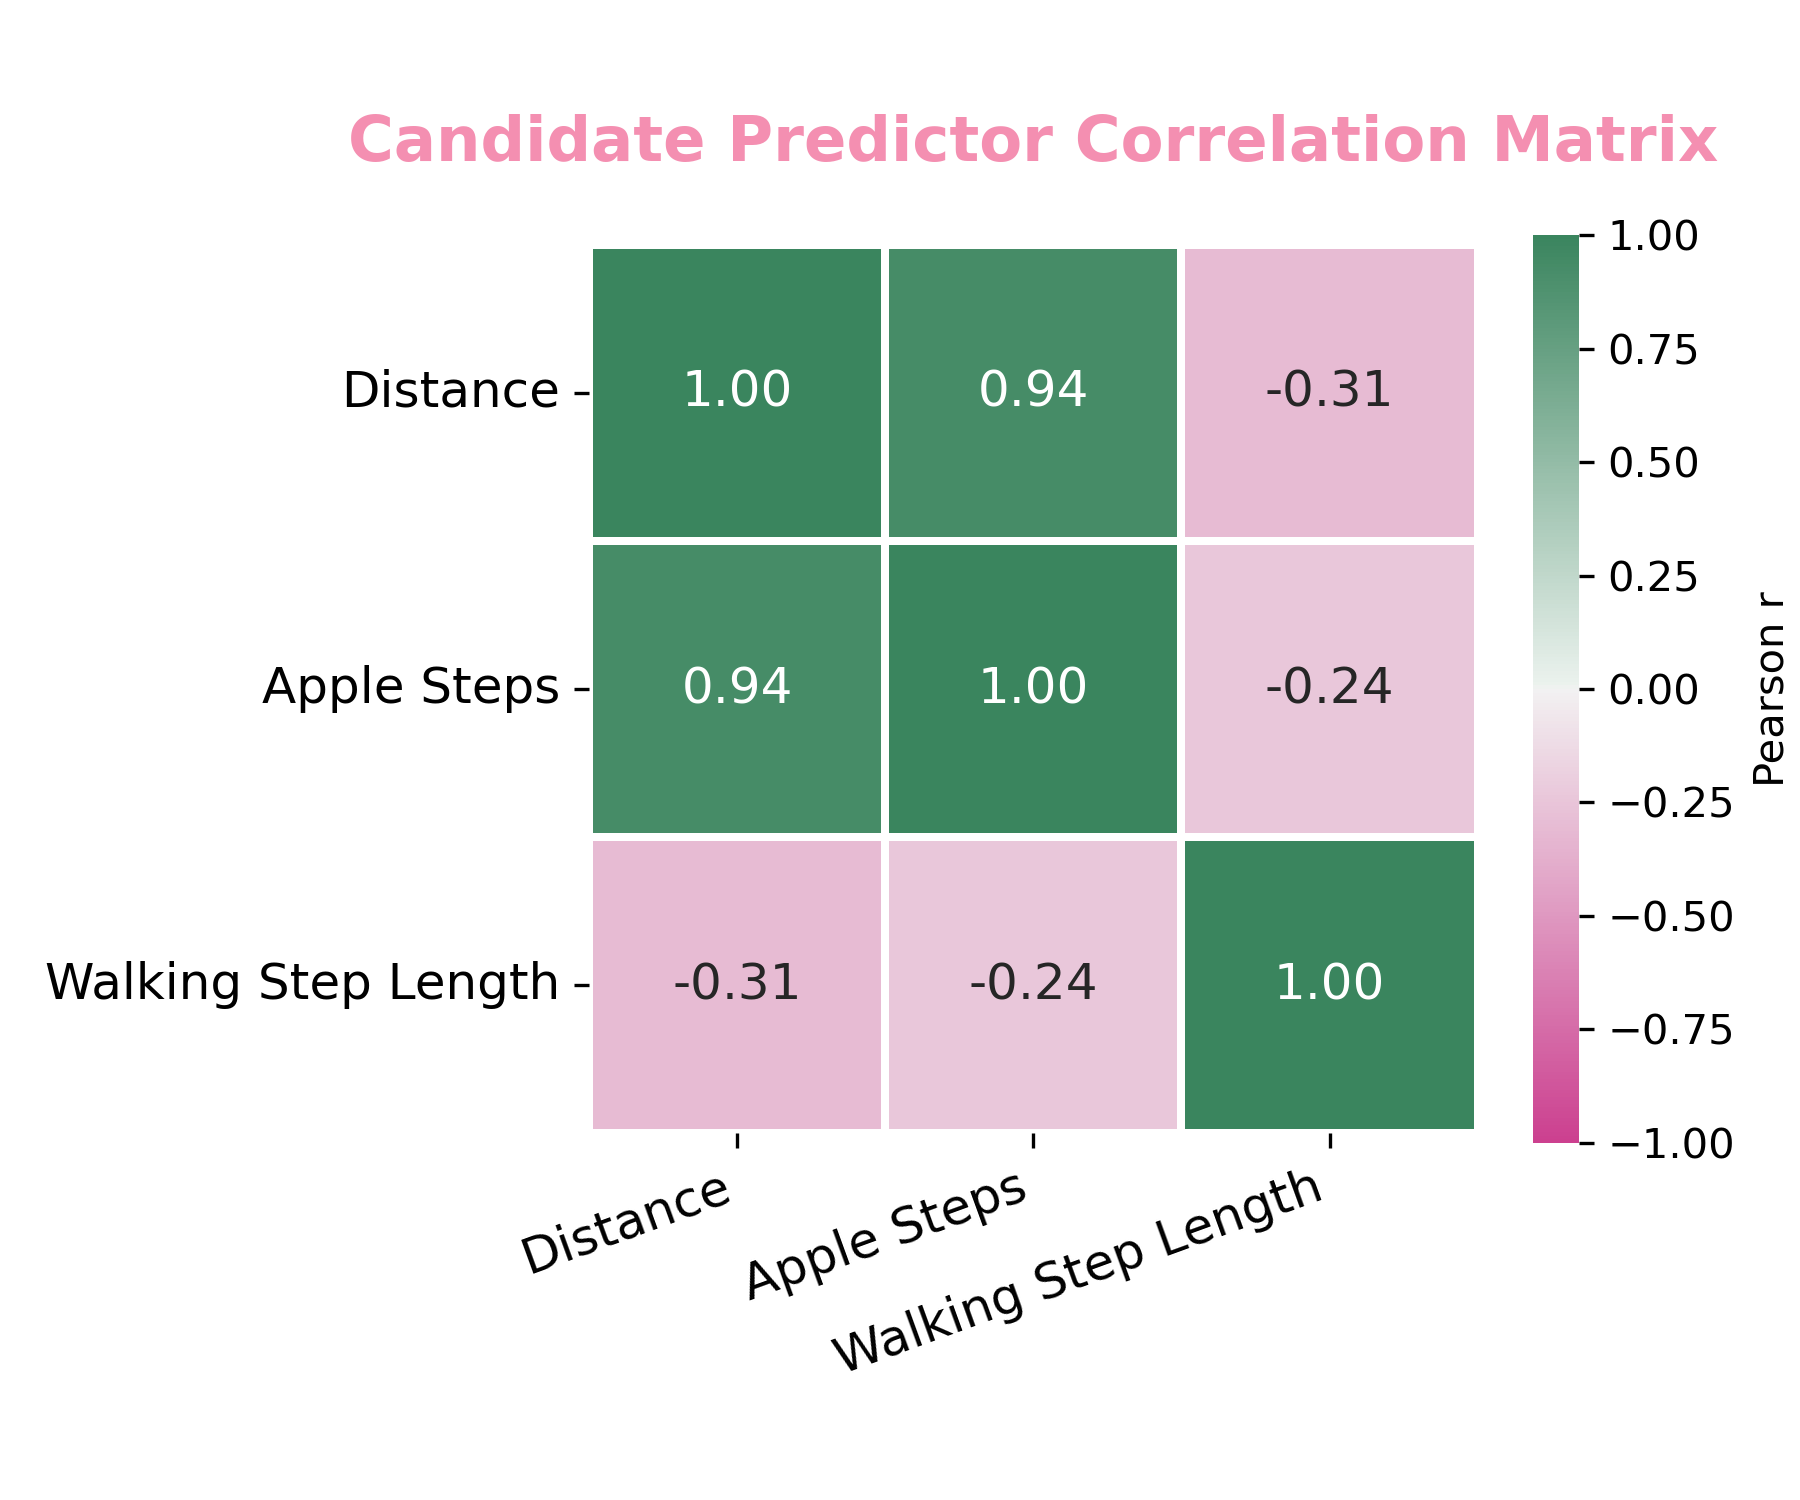

Figure 8.1 Predictor Correlation Matrix 

The correlation matrix indicated that Distance and Apple Step Count were highly correlated, suggesting that both variables measured similar aspects of overall movement volume. In contrast, Walking Step Length exhibited a substantially weaker relationship with Distance, indicating that it may contribute complementary information rather than duplicating an existing predictor.

Because pairwise correlation alone cannot fully quantify the effects of multicollinearity within a regression model, Variance Inflation Factors (VIFs) were subsequently calculated to determine whether the candidate predictors could be included together in the same model.

---

## Phase 8.3 – Variance Inflation Factor (VIF) Analysis

Following the pairwise correlation analysis, Variance Inflation Factors (VIFs) were calculated to quantify the degree of multicollinearity among the candidate predictors.

VIF measures how much the variance of an estimated regression coefficient is inflated because of linear relationships with the remaining predictors in the model. Values close to one indicate little evidence of multicollinearity, whereas larger values suggest that a predictor shares substantial information with one or more other variables.

The initial model containing both Distance and Apple Step Count produced VIF values of approximately 19.5 for each predictor, indicating severe multicollinearity. Because both variables describe overall movement volume, they contained highly redundant information. Including both predictors resulted in unstable coefficient estimates without improving model interpretability.

Consequently, Apple Step Count was excluded from subsequent multiple regression analysis, and Distance was retained as the representative measure of overall movement because it demonstrated comparable predictive performance while avoiding redundancy.

The final multiple regression model was therefore evaluated using the remaining candidate predictors.

### Initial Candidate Model

| Predictor | VIF |
|-----------|----:|
| Distance | 19.51 |
| Apple Step Count | 19.51 |

### Final Model

| Predictor | VIF |
|-----------|----:|
| Distance | 2.13 |
| Walking Step Length | 2.13 |

The substantial reduction in VIF values confirmed that removing Apple Step Count effectively eliminated the multicollinearity identified during the initial model construction. The final predictor set exhibited acceptable levels of multicollinearity and was retained for subsequent regression modeling.

Although Apple Step Count was retained during the simple regression screening, it was found to be highly collinear with Distance (VIF ≈ 19.5). Consequently, Apple Step Count was excluded from subsequent multiple regression models to avoid unstable coefficient estimates.

---

## Phase 8.4 – Model Construction

Candidate models initially included combinations of Distance, Apple Step Count, Walking Step Length, and several additional Tier 1 predictors. However, models containing Apple Step Count exhibited severe multicollinearity, while models including additional predictors substantially reduced the number of complete observations. These candidate models were therefore excluded from further interpretation.

Each candidate model was assessed using four criteria:

- Sample size after removing incomplete observations
- Variance Inflation Factors (VIFs)
- Overall model performance
- Statistical significance of the fitted coefficients

Models exhibiting severe multicollinearity or substantial reductions in sample size were not retained for interpretation.

Following this evaluation, the final multiple regression model retained:

- Distance
- Walking Step Length

This combination preserved a substantially larger sample size than more complex candidate models while maintaining acceptable multicollinearity and overall model stability. Additional predictors were evaluated but were not retained because they introduced excessive missing data, unstable coefficient estimates, or both.

---
## Phase 8.5 – Residual Diagnostics

Residual diagnostics were performed for the final selected multiple regression model to evaluate whether the assumptions of ordinary least squares regression were reasonably satisfied.

The following diagnostic plots were examined:

- Residuals vs. Fitted Values
- Normal Q–Q Plot
- Actual vs. Predicted Weight

These diagnostics were used to assess:

- linearity
- homoscedasticity
- approximate normality of the residuals
- overall predictive agreement between the observed and fitted values


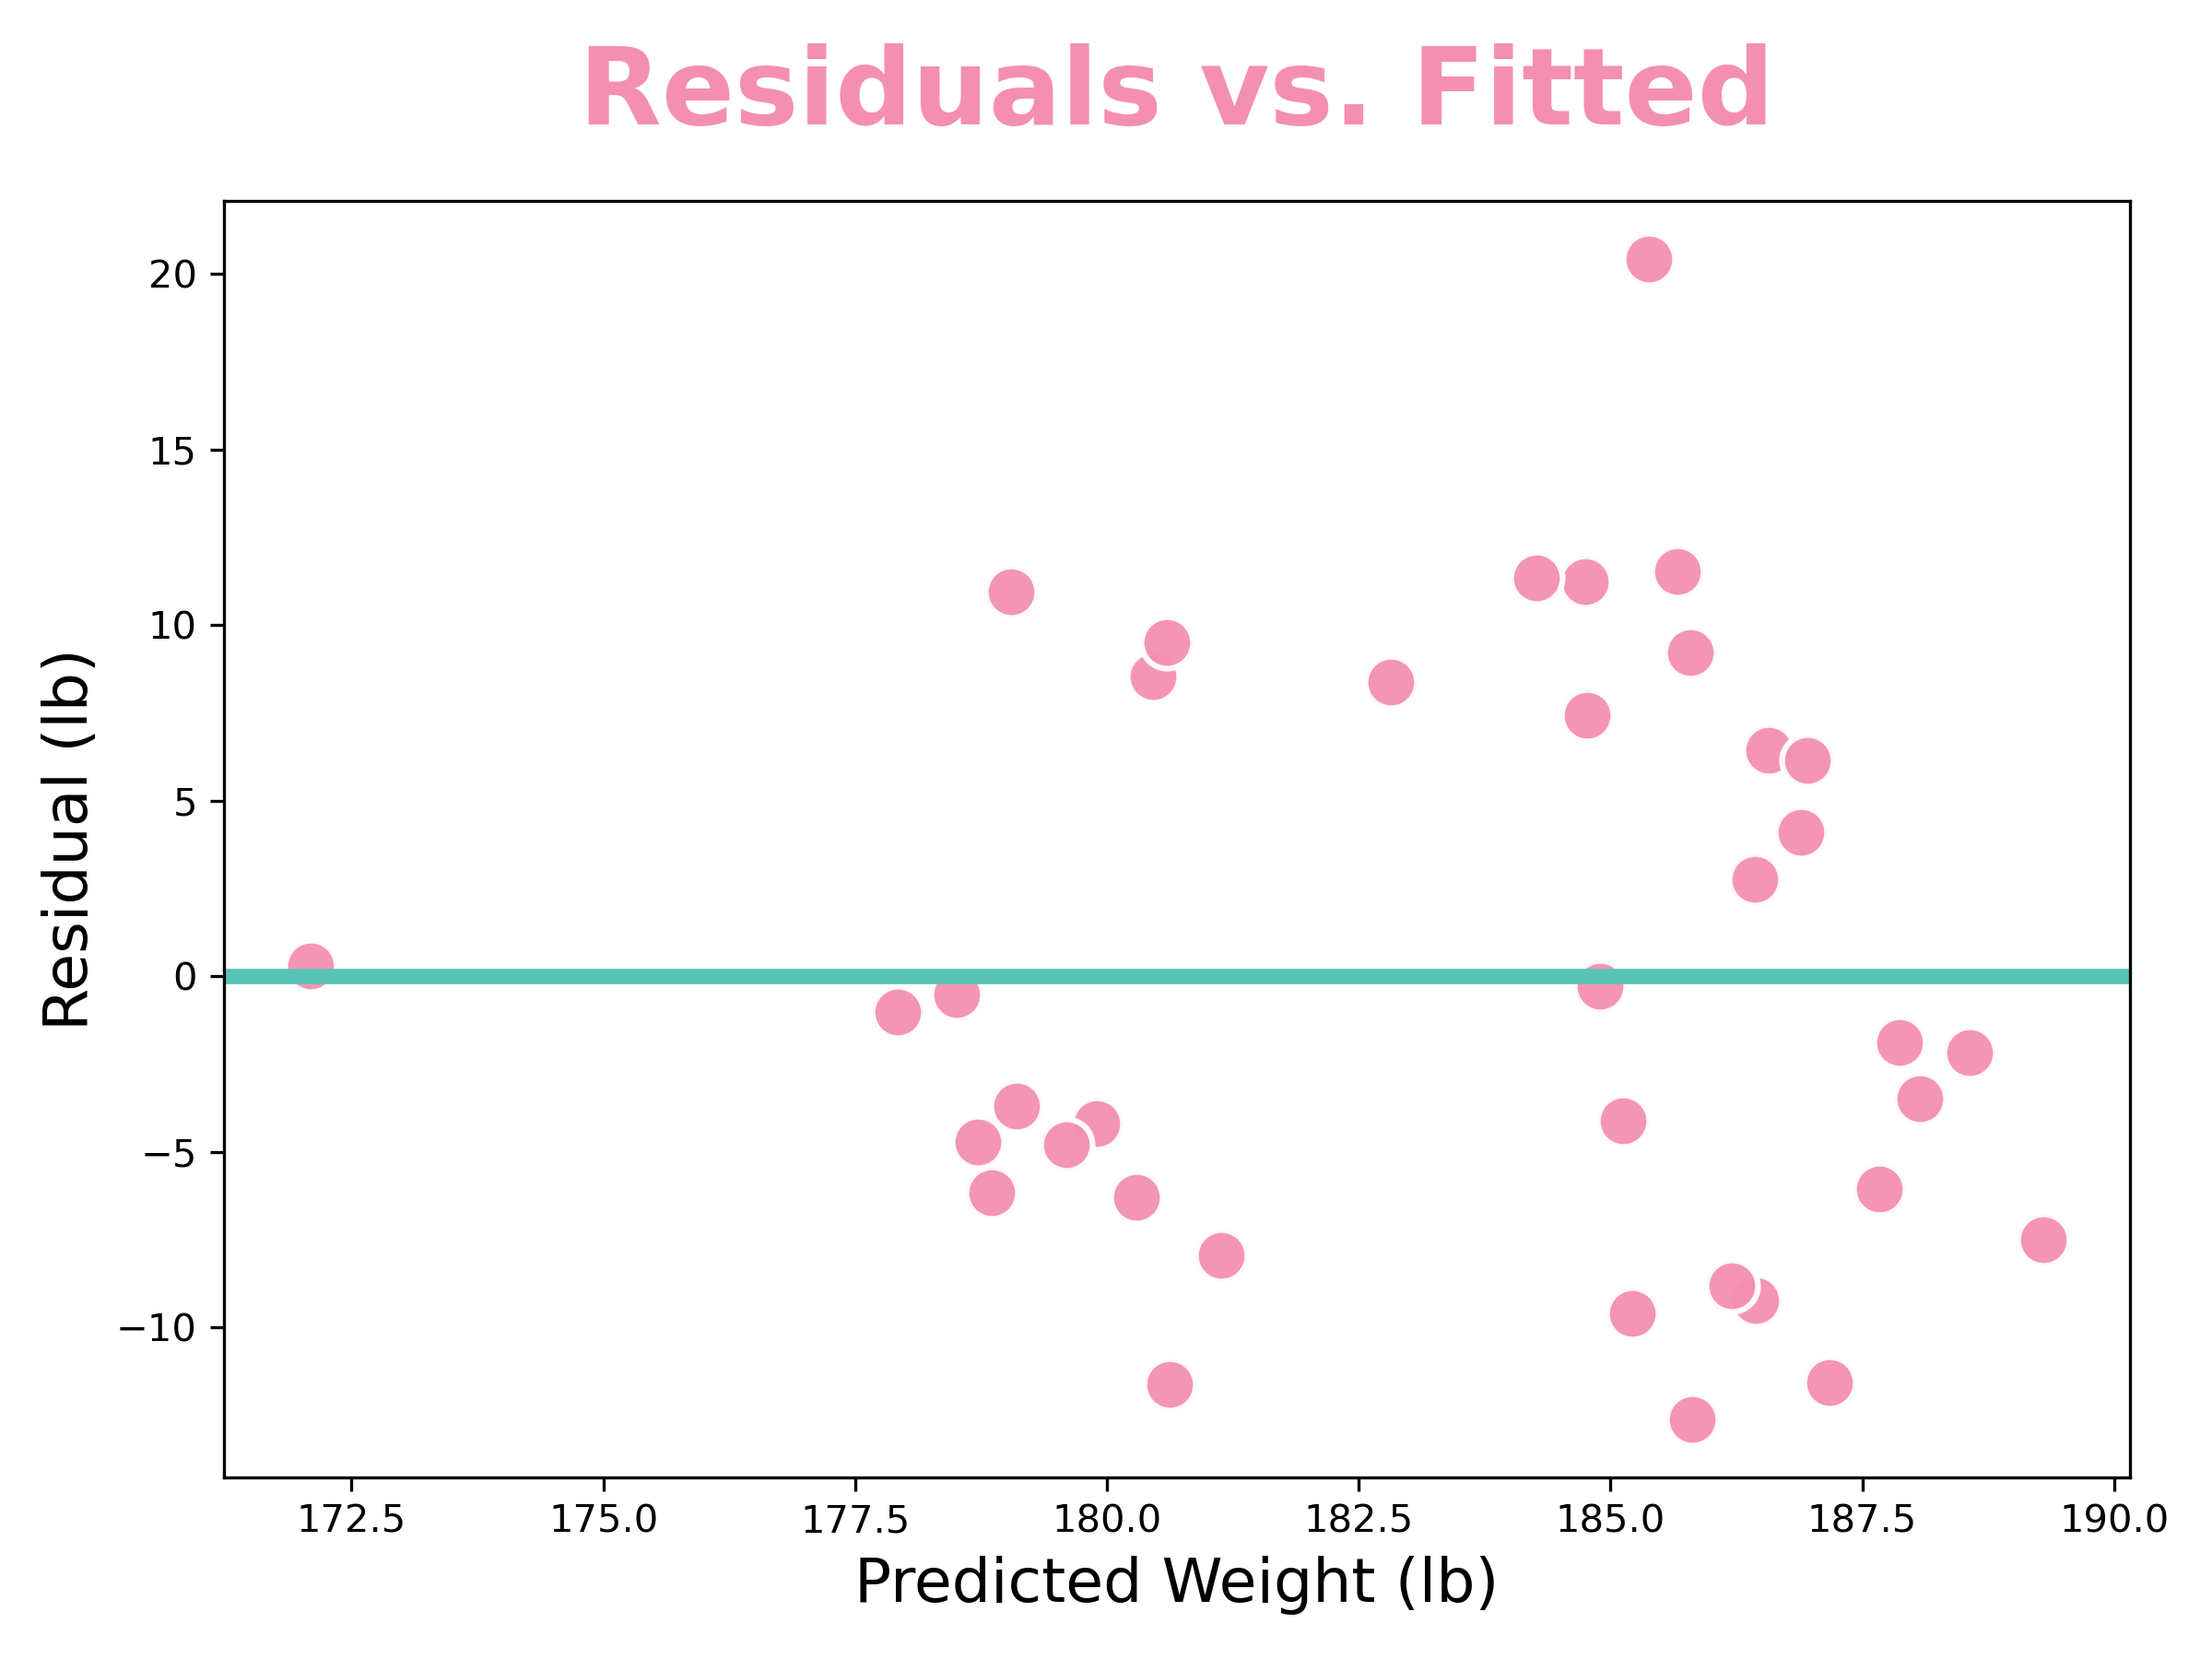

Figure 8.2 Residuals vs Fitted presents the residuals versus fitted values. The residuals were distributed on both sides of zero across the range of fitted values without a pronounced funnel-shaped pattern, providing no strong evidence of severe heteroscedasticity. Some structure remained in the residuals, suggesting that additional predictors or nonlinear relationships may explain variation not captured by the current model.

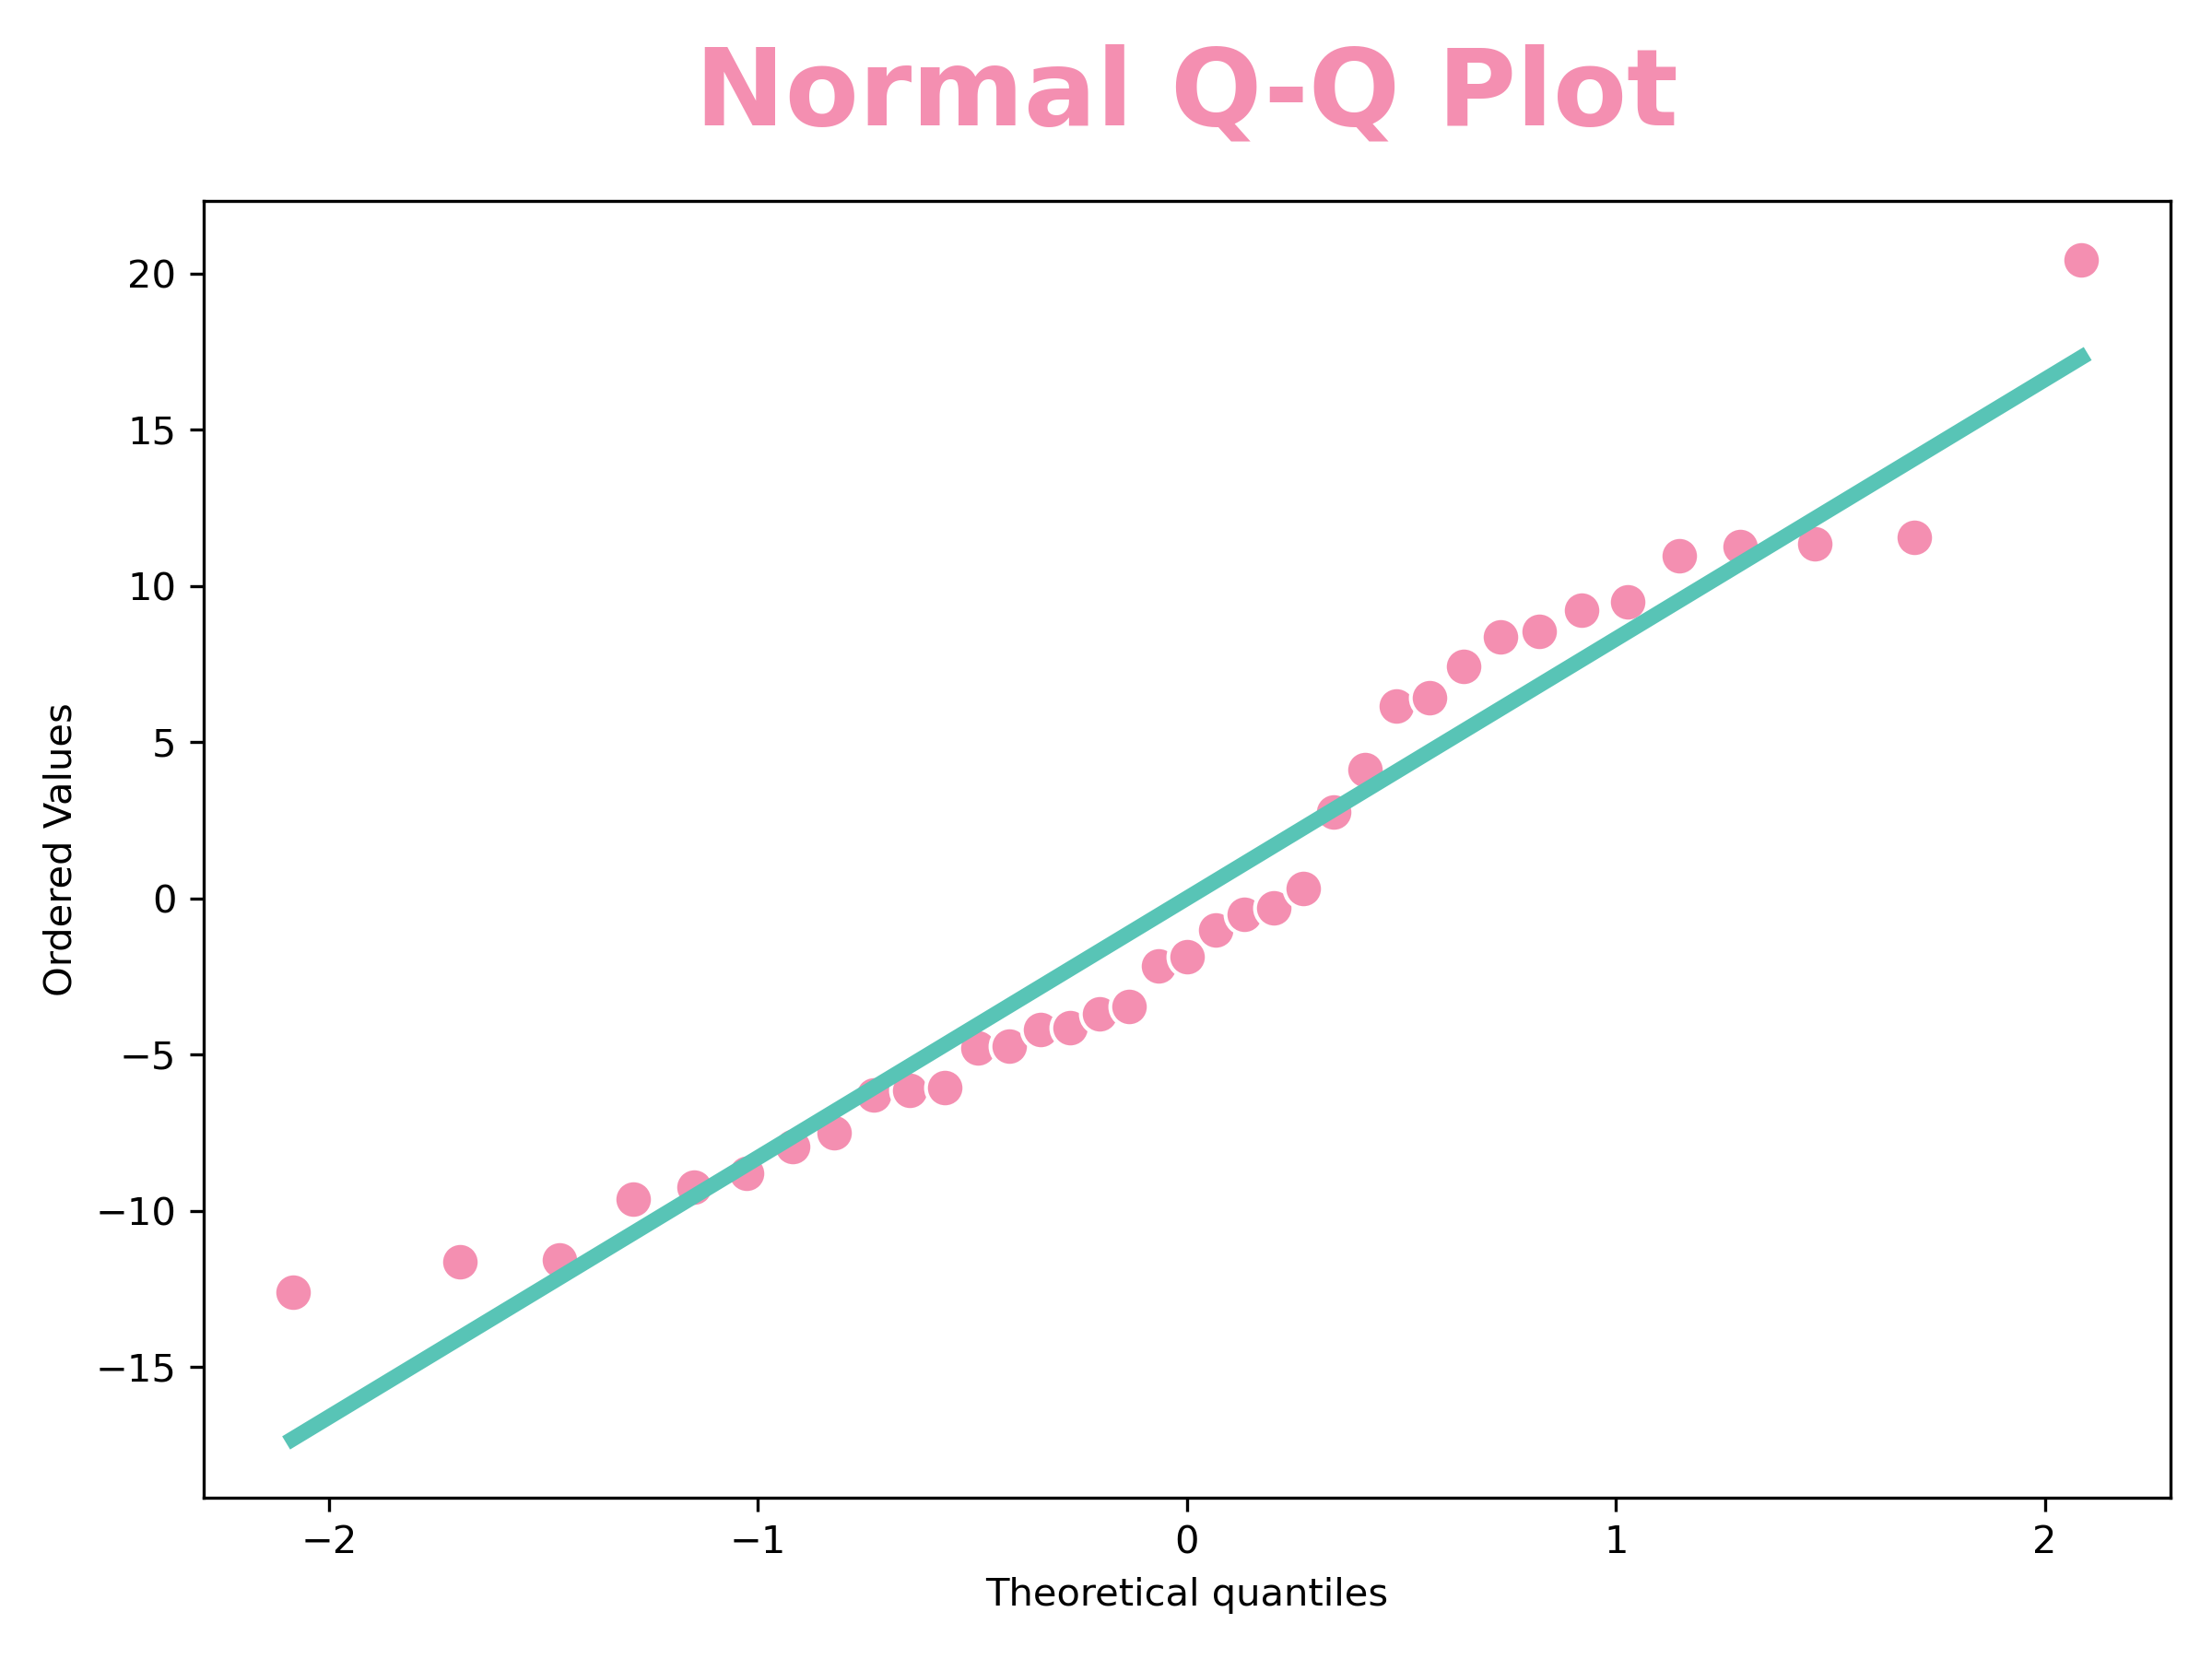
Figure 8.3 Normal Q-Q Plot presents the Normal Q–Q plot. Most residuals followed the theoretical normal reference line reasonably well, although moderate departures were observed in the tails. This indicates that the residuals were approximately normally distributed while containing a small number of larger prediction errors.

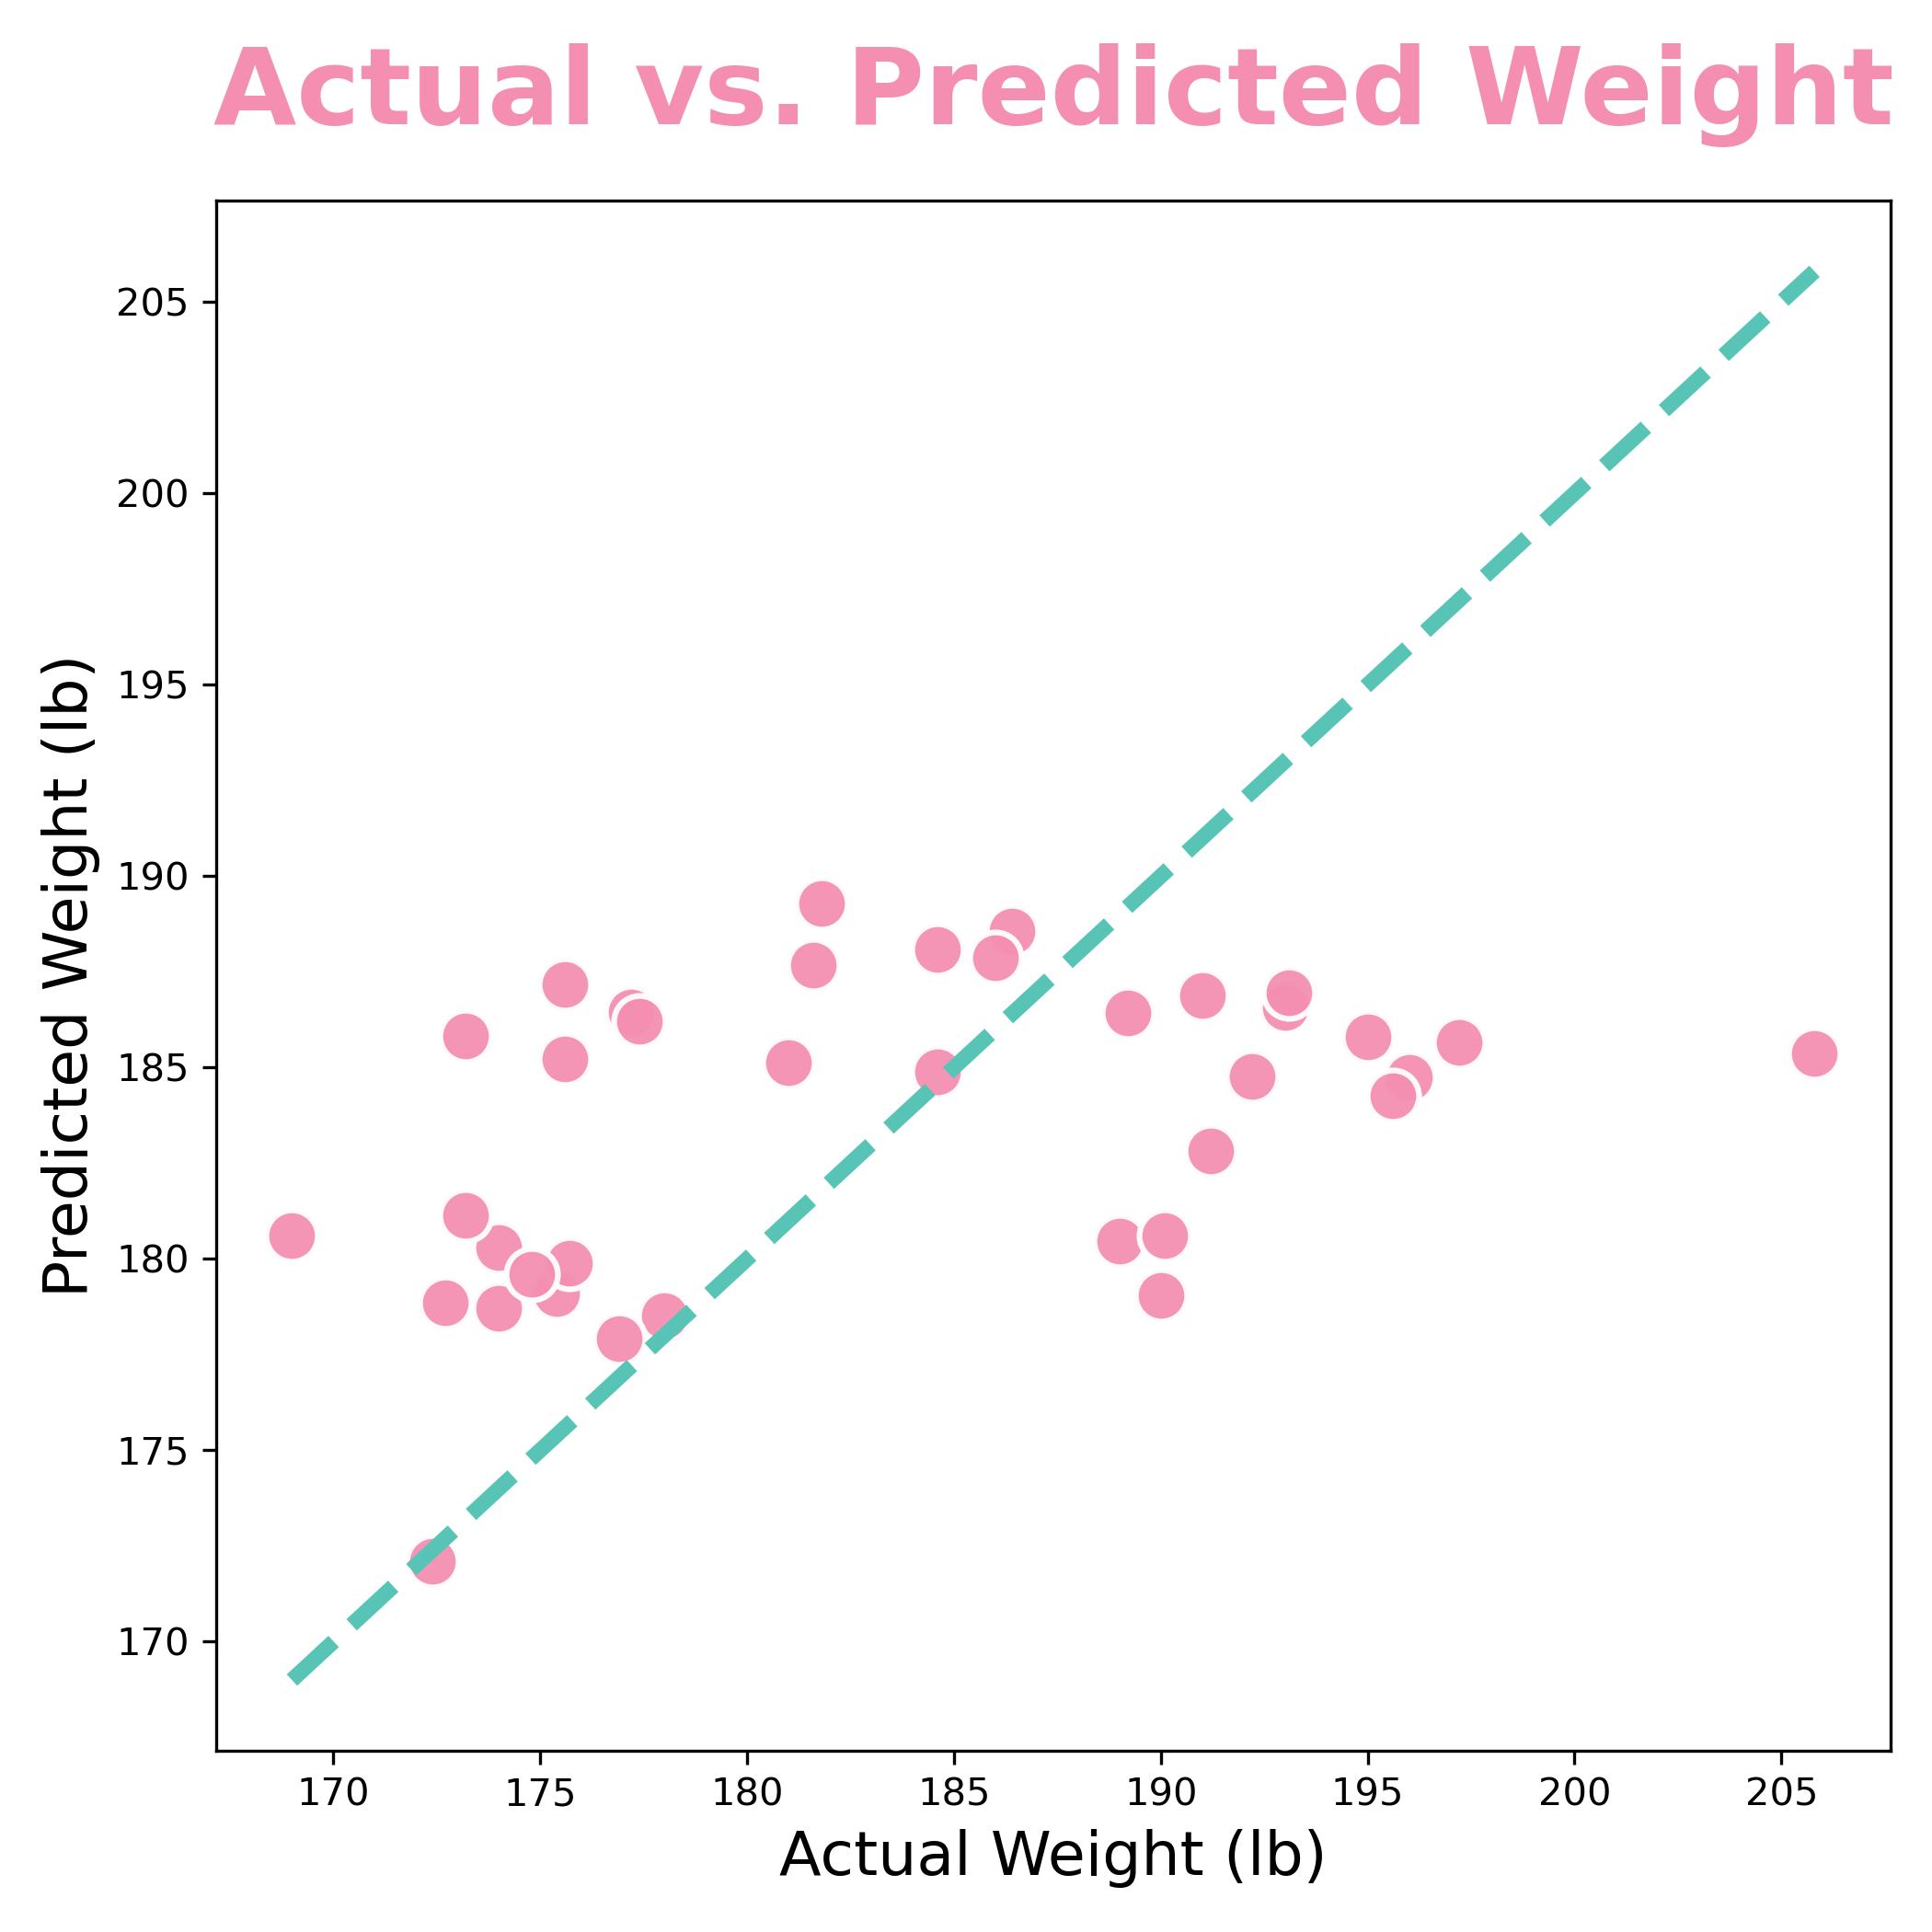
Figure 8.4 Actual vs Predicted compares the observed body-weight measurements with the model predictions. Although the fitted values generally tracked the overall range of body weight, the predictions were noticeably compressed toward the mean, resulting in underestimation of larger body weights and overestimation of smaller body weights. This pattern is consistent with the modest explanatory power of the final regression model.

---

## Phase 8.6 – Interpretation

### Distance

After adjusting for Walking Step Length, Distance exhibited a negative regression coefficient (β = −0.169), indicating that greater weekly distance was associated with lower body weight. However, this relationship was not statistically significant after accounting for Walking Step Length (*p* = 0.079). This finding suggests that part of the association observed during the simple linear regression analysis was shared with Walking Step Length rather than representing an entirely independent effect.

### Walking Step Length

Walking Step Length exhibited a positive regression coefficient (β = 2.70), suggesting that larger average step lengths were associated with higher body weight after controlling for Distance. However, this coefficient was not statistically significant (*p* = 0.155), indicating insufficient evidence that Walking Step Length independently explained variation in body weight within the available sample.

### Overall Model

The final multiple regression model explained approximately 18.6% of the variability in body weight (*R²* = 0.186; Adjusted *R²* = 0.139). Although the overall model was statistically significant (*F* = 3.895, *p* = 0.030), neither predictor remained individually significant after adjustment for the other.

The model produced a Mean Absolute Error (MAE) of **6.94 lb** and a Root Mean Squared Error (RMSE) of **8.11 lb**. These prediction errors indicate that, on average, predicted body weight differed from the observed measurements by approximately seven pounds, with larger prediction errors contributing to the slightly higher RMSE.

Taken together, these results suggest that the predictive information contained within Distance and Walking Step Length partially overlaps, reducing the apparent independent contribution of each predictor despite producing a statistically significant overall model.


---

## Phase 8.7 – Conclusions

Multiple regression was performed to determine whether combining the strongest engineered predictors improved the ability to explain longitudinal variation in body weight.

Several candidate predictor combinations were evaluated during model development. However, adding additional variables substantially reduced the number of complete observations because many engineered features were unavailable across the full longitudinal timeline. More complex models also exhibited severe multicollinearity, with several predictors producing Variance Inflation Factors greater than 10. These issues resulted in unstable coefficient estimates and little improvement in overall model performance.

Consequently, the simpler multiple regression model containing Distance and Walking Step Length was retained for interpretation.The final model therefore represents the most parsimonious multivariable model supported by the available longitudinal data.

Overall, the multiple regression analysis demonstrated that increasing model complexity did not necessarily improve predictive performance. These findings emphasize the importance of balancing explanatory power, data availability, and multicollinearity when constructing statistical models from longitudinal health data.


# Project Conclusions

This project transformed multiple independent health and fitness data sources into a unified analytical dataset suitable for exploratory analysis, statistical inference, and predictive modeling. The resulting workflow encompassed data acquisition, database construction, validation, data cleaning, feature engineering, measurement-window construction, exploratory analysis, correlation analysis, visualization, and regression modeling.

A central objective throughout the project was reproducibility. Rather than treating data cleaning as a collection of ad hoc decisions, every transformation was documented, justified, and incorporated into a repeatable analytical pipeline. Maintaining separate archival (`df_clean`) and modeling (`df_model`) datasets preserved the original observations while allowing evidence-based modeling decisions to be introduced without compromising reproducibility.

Across all analysis, average distance traveled emerged as the strongest predictor of body weight among the variables evaluated. It demonstrated both the strongest negative correlation with weight and the largest regression coefficient among the evaluated predictors. Workout duration also exhibited a moderate negative relationship with body weight, while dietary calories and sleep metrics demonstrated comparatively weaker associations.

Although the resulting regression models demonstrated limited predictive performance, the analysis successfully identified which variables contained the strongest predictive signals which variables contained the strongest predictive signals and revealed the primary limitation of the project: data availability rather than model construction. Despite integrating Apple Health and expanding the historical record to more than seven years and over 1.7 million health observations, body-composition measurements remained comparatively limited. The incomplete overlap between predictor and outcome variables substantially reduced the number of observations available for model training and limited the reliable estimation and evaluation of multivariable regression models.

These findings reinforce an important lesson commonly encountered in real-world data science: larger datasets do not necessarily produce stronger predictive models. Data quality, completeness, overlap, and reproducible preprocessing ultimately proved more influential than increasing model complexity alone. Future improvements are therefore more likely to come from increasing the number of overlapping observations than from adopting increasingly sophisticated modeling techniques. Additional body-composition measurements, dietary records, recovery metrics, and workout observations collected over the same time periods would substantially increase statistical power and enable more reliable multivariable regression models.

Overall, this project demonstrates an end-to-end analytical workflow using real-world longitudinal health data while highlighting the practical challenges of working with incomplete observational datasets. More importantly, it reinforces that reliable statistical modeling depends not only on appropriate analytical methods, but also on careful data validation, reproducible preprocessing, and understanding how the underlying data were collected. The resulting analytical workflow now provides a reproducible foundation that can continue evolving as additional longitudinal health observations become available.

---

## Next Phase of the Project

One outcome of this project was realizing that improving the statistical models is not simply a matter of applying more sophisticated algorithms. The limiting factor is the quality, completeness, and overlap of the available data.

To address this, I have begun expanding the information collected during my workouts. Rather than recording only summary workout metrics, I now track additional strength-training variables including individual exercises, working weight, repetitions, sets, and total training volume. I have also started consistently logging my daily macronutrient intake—not to follow a particular diet, but to better quantify nutritional intake as a potential predictor of future body-composition changes.

While investigating Garmin's data export capabilities, I found that many of these strength-training details are not available through Garmin's standard export tools. Retrieving them requires navigating the Garmin Connect web interface, making Selenium-based browser automation the most practical approach for building a reproducible extraction pipeline.

Although I have not yet finalized the architecture, one possible approach is to schedule a small computer (such as a Raspberry Pi or another always-on system) to execute the Selenium-based scraper each night after Garmin synchronizes new activities. The extracted data could then automatically enter the existing Python processing pipeline, where it would be validated, cleaned, transformed into engineered features, and appended to the analytical database.

The expanded dataset will also make it possible to investigate research questions that were outside the scope of the current study, including the relationship between exercise-specific training volume, progressive overload, nutritional intake, and long-term changes in body composition.

These additions also represent a natural evolution in the scope of the project. Rather than relying primarily on aggregate activity metrics, future analysis will incorporate exercise-specific training metrics, nutritional behavior, and long-term strength progression using substantially richer predictor variables. Future iterations of this project will expand beyond overall training volume to investigate exercise-specific workload, nutritional intake, and long-term strength adaptations as the longitudinal dataset continues to grow.

---

## Long-Term Vision

Although the analytical pipeline developed throughout this project is reproducible, the data acquisition process is still largely manual. One of the next engineering challenges will be automating the collection pipeline so that new observations are incorporated without requiring routine manual intervention.

My long-term goal is to transform this project from a retrospective analysis into a continuously updating personal analytics platform. Rather than simply recording historical workouts, I want the system to monitor trends across training load, exercise-specific volume, nutrition, recovery, sleep, and body-composition measurements. As additional data accumulate, I hope to develop statistical models capable of identifying meaningful changes in my training and recovery, providing evidence-based recommendations such as when to increase training intensity, prioritize recovery, or adjust nutritional intake.

Ultimately, rather than asking whether I trained hard enough yesterday, the long-term objective is to build a system capable of using longitudinal data to help determine what I should do tomorrow.